In this cell, we install the required Python libraries such as pandas, numpy, matplotlib, seaborn, scikit-learn, nltk, openpyxl, and spacy, and download the English language model for spaCy.

In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk openpyxl spacy
!python -m spacy download en_core_web_sm



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 5.7 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.8 MB 5.6 MB/s eta 0:00:02
     --------- ------------------------------ 2.9/12.8 MB 5.4 MB/s eta 0:00:02
     ----------- ---------------------------- 3.7/12.8 MB 5.5 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 5.6 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 5.4 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 5.6 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 5.6 MB/s eta 0:00:01
     ------------------------------- -------- 10.2/12.8 MB 5.6 MB/s eta 0:00:01
     ------------------------------------ --- 11.5/12.8 MB 5.7 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 5.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In this cell, we install the BERTopic library, which is essential for topic modeling in our analysis. BERTopic is a topic modeling technique that uses BERT embeddings and clustering algorithms to identify and extract topics from large collections of documents. It provides an easy-to-use interface for extracting topics from text data.

In [6]:
!pip install bertopic


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\rodri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Middle Term Test 2 - COVID-19 Fake News Detection

## 1.1 Imports

In this section, we import all the necessary Python libraries that will be used throughout our COVID-19 fake news detection analysis. Each library serves a specific purpose:

**Data Manipulation & Visualization:**
- **pandas** and **numpy**: For data manipulation, dataframe operations, and numerical computations
- **matplotlib** and **seaborn**: For creating visualizations, plots, and statistical graphics

**Natural Language Processing (NLP):**
- **nltk**: The Natural Language Toolkit for text processing tasks including tokenization, stopword removal, stemming/lemmatization, frequency distribution analysis, and n-gram generation
- **spacy**: An advanced NLP library for part-of-speech tagging, named entity recognition, and linguistic analysis

**Machine Learning:**
- **sklearn** (scikit-learn): Provides tools for:
  - Model selection and evaluation (train_test_split, GridSearchCV)
  - Text vectorization (TfidfVectorizer, CountVectorizer)
  - Classification algorithms (Naive Bayes, Logistic Regression, SVM, Random Forest)
  - Performance metrics (accuracy, classification reports, confusion matrices)
  - Clustering (silhouette_score)

**Advanced Topic Modeling:**
- **UMAP**: For dimensionality reduction, transforming high-dimensional text embeddings into lower dimensions for visualization
- **HDBSCAN**: A hierarchical density-based clustering algorithm for discovering topics in text data
- **BERTopic**: A state-of-the-art topic modeling technique that combines BERT embeddings with clustering algorithms to extract coherent topics from document collections
- **ClassTfidfTransformer**: A specialized TF-IDF transformer used by BERTopic to create topic representations

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
from nltk.util import ngrams
from nltk.text import Text
import spacy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1.2 Load Dataset

In this section, we load the COVID-19 fake news dataset which has been split into multiple files for proper machine learning workflow:

**Dataset Files:**
1. **train_df** (Constraint_English_Train.xlsx): The training dataset used to train our machine learning models. This contains labeled tweets (real vs fake) that the models will learn from.

2. **val_df** (Constraint_English_Val.xlsx): The validation dataset used during model training to tune hyperparameters and prevent overfitting. This helps us select the best-performing model configuration.

3. **test_df** (Constraint_English_Test.xlsx): The test dataset used for final model evaluation. This dataset simulates real-world performance on unseen data.

4. **text_with_labels** (english_test_with_labels.xlsx): An additional labeled test set with ground truth labels for verification and analysis purposes.

**Data Inspection:**
After loading the datasets, we print the shape (number of rows and columns) of each to understand the data volume we're working with. We also configure pandas display options to show full tweet text without truncation, which is crucial for qualitative analysis of the content.

The `head(15)` function displays the first 15 rows of the training data, allowing us to get a preliminary understanding of:
- Tweet content and structure
- Presence of hashtags, mentions, URLs
- Tweet length variations
- Label distribution (real vs fake)

In [8]:
# Load datasets: test, train, val, and text_with_labels
train_df = pd.read_excel('data/Constraint_English_Train.xlsx')
val_df = pd.read_excel('data/Constraint_English_Val.xlsx')
test_df = pd.read_excel('data/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('data/english_test_with_labels.xlsx')

'''train_df = pd.read_excel('/content/Constraint_English_Train.xlsx')
val_df = pd.read_excel('/content/Constraint_English_Val.xlsx')
test_df = pd.read_excel('/content/Constraint_English_Test.xlsx')
text_with_labels = pd.read_excel('/content/english_test_with_labels.xlsx')'''

# Basic info
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Display complete tweets
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

train_df.head(15)

Train shape: (6420, 3)
Validation shape: (2140, 3)
Test shape: (2140, 2)


,id,tweet,label
0,1,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,real
1,2,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,real
2,3,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,fake
3,4,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,real
4,5,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,real
5,6,"Covid Act Now found ""on average each person in Illinois with COVID-19 is infecting 1.11 other people. Data shows that the infection growth rate has declined over time this factors in the stay-at-home order and other restrictions put in place."" https://t.co/hhigDd24fE",real
6,7,If you tested positive for #COVID19 and have no symptoms stay home and away from other people. Learn more about CDC’s recommendations about when you can be around others after COVID-19 infection: https://t.co/z5kkXpqkYb. https://t.co/9PaMy0Rxaf,real
7,8,Obama Calls Trump’s Coronavirus Response A Chaotic Disaster https://t.co/DeDqZEhAsB,fake
8,9,"???Clearly, the Obama administration did not leave any kind of game plan for something like this.??�",fake
9,10,Retraction—Hydroxychloroquine or chloroquine with or without a macrolide for treatment of COVID-19: a multinational registry analysis - The Lancet https://t.co/L5V2x6G9or,fake


As a simple analysis we can see that there are shorter and longer tweets but most use hashtags and links to sources. We can also see that some use figures to describe what they say, in this small sample all those using figures are real but we will analyze more things below.

## 1.3 EDA (Exploratory Data Analysis - Linguistic Analysis)

Exploratory Data Analysis (EDA) is a critical step in understanding our dataset before building predictive models. In this section, we perform comprehensive linguistic analysis to uncover patterns, differences, and characteristics that distinguish real tweets from fake tweets. This analysis will help us:

1. **Identify distinguishing features** between real and fake news tweets
2. **Understand text patterns** that could be useful for classification
3. **Detect anomalies or outliers** in the data
4. **Inform feature engineering** for machine learning models
5. **Validate data quality** and identify potential preprocessing needs

We'll examine multiple linguistic dimensions including word frequency, sentence structure, named entities, syntactic patterns, and stylistic choices.

### 1.3.1 Class Distribution Analysis

Before diving into detailed analysis, we must understand the **class balance** in our dataset. Class imbalance is a common issue in machine learning that can significantly impact model performance.

**Why this matters:**
- **Biased predictions**: Models trained on imbalanced data tend to favor the majority class
- **Misleading metrics**: Accuracy can be deceptively high when simply predicting the majority class
- **Strategy selection**: Knowing the imbalance helps us choose appropriate techniques (class weighting, SMOTE, stratified sampling)
- **Fair comparison**: When comparing numerical statistics between classes, we need to account for size differences

In this subsection, we:
1. Download necessary NLTK resources (punkt tokenizer and stopwords)
2. Load the spaCy English language model for advanced NLP tasks
3. Create a working copy of the training data with only the essential columns (tweet text and label)
4. Count and visualize the distribution of real vs fake tweets

A balanced dataset would have approximately equal numbers of each class, while an imbalanced dataset requires special handling during model training.

In [9]:
nltk.download('punkt')
nltk.download('stopwords')
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
df = train_df.copy()
df = df[['tweet', 'label']]

In [11]:
# Class distribution
df['label'].value_counts()

label
real    3360
fake    3060
Name: count, dtype: int64

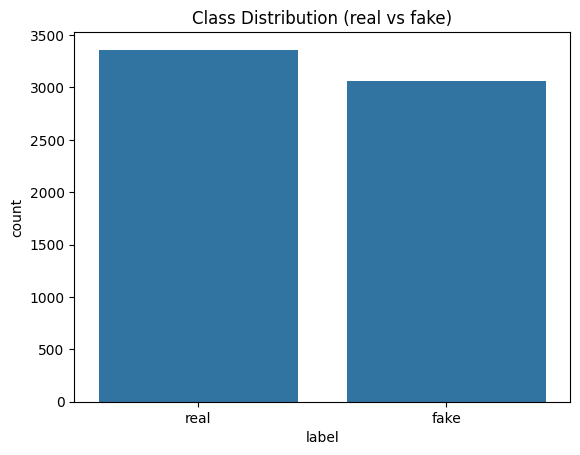

In [12]:
sns.countplot(data=df, x='label')
plt.title("Class Distribution (real vs fake)")
plt.show()

**Class Imbalance Observation:**

The dataset contains more real tweets than fake tweets, creating a **class imbalance** situation. This imbalance has important implications for our analysis:

**Impact on Analysis:**
- **Numerical comparisons**: Raw counts will be skewed toward the majority class (real tweets)
- **Statistical validity**: We must use relative measures (percentages, proportions) rather than absolute counts when comparing classes
- **Normalization required**: Frequency distributions and statistical summaries should be normalized by class size

**Mitigation Strategies:**
Throughout the analysis, we address this imbalance by:
1. Using **percentage-based metrics** instead of raw counts
2. Calculating **relative frequencies** for fair comparison
3. Normalizing distributions by class size when analyzing linguistic features

This awareness ensures our conclusions reflect true linguistic differences rather than merely reflecting the size disparity between classes.

### 1.3.2 Text Preprocessing: Tokenization & Stopword Removal

**Purpose:** Transform raw tweet text into clean, analyzable tokens suitable for linguistic analysis and machine learning.

**Preprocessing Pipeline:**

1. **Tokenization**: 
   - Break text into individual words (tokens) using NLTK's `word_tokenize()`
   - Handles punctuation, special characters, and whitespace
   - Respects word boundaries and contractions

2. **Normalization**:
   - Convert all tokens to lowercase for consistency
   - Ensures "COVID", "Covid", and "covid" are treated as the same word

3. **Filtering**:
   - **Alphabetic filtering**: Remove numbers, punctuation, and symbols using `isalpha()`
   - **Stopword removal**: Eliminate common words (the, is, at, are, etc.) using NLTK's English stopwords list
   - Stopwords carry little semantic meaning but appear frequently

**Why Remove Stopwords:**
- **Focus on content**: Highlights meaningful words that distinguish topics
- **Reduce dimensionality**: Fewer features for machine learning models
- **Improve analysis**: Frequency distributions show topic-relevant terms
- **Performance**: Faster processing and better model efficiency

**Result:** Each tweet is converted into a list of meaningful, normalized tokens ready for analysis.

In [13]:
stop_words = set(stopwords.words("english"))

In [14]:
def preprocess_nltk(text):
    tokens = word_tokenize(text)
    return [w.lower() for w in tokens if w.isalpha() and w.lower() not in stop_words]

In [15]:
df['tokens'] = df['tweet'].astype(str).apply(preprocess_nltk)
df[['tweet', 'tokens']].head()

,tweet,tokens
0,The CDC currently reports 99031 deaths. In general the discrepancies in death counts between different sources are small and explicable. The death toll stands at roughly 100000 people today.,"[cdc, currently, reports, deaths, general, discrepancies, death, counts, different, sources, small, explicable, death, toll, stands, roughly, people, today]"
1,States reported 1121 deaths a small rise from last Tuesday. Southern states reported 640 of those deaths. https://t.co/YASGRTT4ux,"[states, reported, deaths, small, rise, last, tuesday, southern, states, reported, deaths, https]"
2,Politically Correct Woman (Almost) Uses Pandemic as Excuse Not to Reuse Plastic Bag https://t.co/thF8GuNFPe #coronavirus #nashville,"[politically, correct, woman, almost, uses, pandemic, excuse, reuse, plastic, bag, https, coronavirus, nashville]"
3,#IndiaFightsCorona: We have 1524 #COVID testing laboratories in India and as on 25th August 2020 36827520 tests have been done : @ProfBhargava DG @ICMRDELHI #StaySafe #IndiaWillWin https://t.co/Yh3ZxknnhZ,"[indiafightscorona, covid, testing, laboratories, india, august, tests, done, profbhargava, dg, icmrdelhi, staysafe, indiawillwin, https]"
4,Populous states can generate large case counts but if you look at the new cases per million today 9 smaller states are showing more cases per million than California or Texas: AL AR ID KS KY LA MS NV and SC. https://t.co/1pYW6cWRaS,"[populous, states, generate, large, case, counts, look, new, cases, per, million, today, smaller, states, showing, cases, per, million, california, texas, al, ar, id, ks, ky, la, ms, nv, sc, https]"


### 1.3.3 Tweet Length Analysis

**Objective:** Analyze and compare the length distribution of tweets between real and fake news to identify potential distinguishing patterns.

**Methodology:**
1. Calculate the number of tokens (words) in each tweet after tokenization
2. Compute descriptive statistics (mean, median, std, min, max) grouped by label
3. Visualize distributions using box plots to identify outliers and spread
4. Investigate anomalous cases (extremely long tweets)

**Why Length Matters:**
- **Brevity patterns**: Real news may follow journalistic conventions of conciseness
- **Spam indicators**: Exceptionally long tweets might indicate spam or bot-generated content
- **Content structure**: Length can reflect different communication strategies (informative vs emotional)
- **Feature engineering**: Length-based features can be useful for classification models

We calculate tweet length based on the number of tokens after preprocessing, which gives us a more accurate representation than raw character count.

In [16]:
df['tweet_length'] = df['tokens'].apply(len)

In [17]:
# Descriptive statistics by class
df.groupby('label')['tweet_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,12.724837,18.592957,1.0,8.0,11.0,15.0,835.0
real,3360.0,16.702083,5.931704,2.0,12.0,17.0,21.0,34.0


#### Key Findings - Tweet Length:

**Central Tendency:**
- **Real tweets**: Average of ~16 tokens with more consistent length
- **Fake tweets**: Average of ~12 tokens, more variable distribution

**Outliers & Anomalies:**
- Fake tweets show a maximum length of **835 tokens** - significantly larger than real tweets
- Multiple extreme outliers in fake tweet category warrant further investigation

The outliers may not be individual tweets but rather compilations or thread summaries concatenated together, particularly in misinformation compilations.

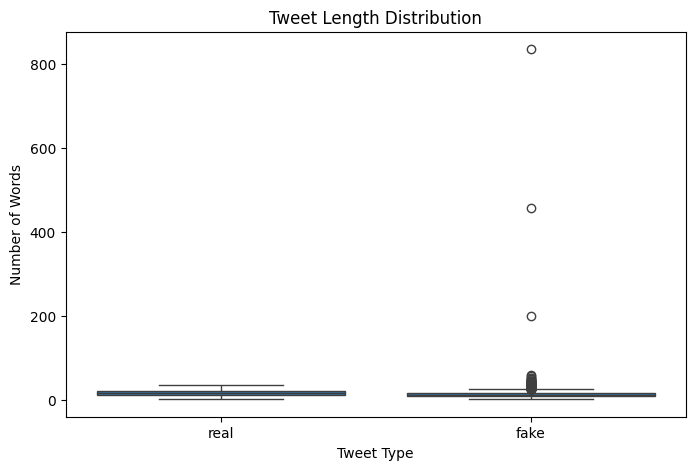

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='tweet_length')
plt.title("Tweet Length Distribution")
plt.ylabel("Number of Words")
plt.xlabel("Tweet Type")
plt.show()

#### Visual Analysis - Outlier Detection:

The boxplot reveals several outliers in the fake tweet category - tweets with extremely large word counts (>100 tokens). These anomalies require closer examination to understand their nature and potential impact on our analysis.

In [19]:
df[df['tweet_length'] > 100][['tweet', 'label']].head()

tweet  \
270   Amoxi" Capsule made in US is the only medicine that can completely cure COVID-19.\nEgyptian Health Minister arrive in Italy with secret coronavirus cure.\n Dr Charles Lieber a Harvard professor has been arrested in the USA for manufacturing the coronavirus and selling it to China. A video news report from WCVB a TV station in Boston Massachusetts is shared with the Facebook post.\nMountain Matterhorn in Switzerland was lit in three colours of Indian flag as a token of gratitude to India for sending Hydroxychloroquine.\nAl-Azhar Imam said he is considering exceptions on Ramadan fasting as the research says that the mouth must be kept wet to prevent COVID-19\n Japanese Nobel Tasuku Honjo says coronavirus was created in the Wuhan laboratory\nA man collapses in 5 minutes after showing COVID-19 symptoms in India.\nCelebrities spreading misinformation about coronavirus and the Janata curfew in India.\n Multiple posts shared repeatedly on Facebook and Twitter since March 2020 claim that Israel has reported zero deaths from the novel coronavirus which causes the disease COVID-19. The posts also claim Israeli citizens have protected themselves from COVID-19 by drinking a remedy of hot water lemon and baking soda which purportedly “kills” the virus.\n CDC suddenly lost 30000 deaths from coronavirus from its data thus proving the virus is not as serious as it seems.\nPhotos of coronavirus patients being treated on the road in Italy.\nIndian actor Shah Rukh Khan donated money to Pakistan to fight coronavirus and did not help India at all.\nRussian President Vladimir Putin has ordered Russia’s population to stay at home for 15 days or face five years in jail.\nIndian Army has set-up a 1000 bed quarantine facility in Rajasthan's Barmer.\nLeonardo Da Vinci Hospital a COVID-19 reference hospital in Fortaleza Brazil is empty. A video "proves" there was no one at the areas open to the public.\n President Trump's claim that he inherited no ventilators from the Obama administration.\nAn audio where an unidentified person links the virus that causes COVID-19 with the massive flu vaccination campaign.\nBlack body bags being referred to as deaths in New York and the reason a lockdown is essential.\nMustard oil prevents a person from getting infected with COVID-19.\nNorth Carolina’s health department is "telling hospitals that if they decide to do elective surgeries they won’t be eligible to receive (protective equipment) from the state.”\n After coronavirus pandemic Chinese president said it's China's time to lead the world.\nThe nurses that Boris Johnson claimed saved his life are not registered in the UK.\nA claim that India’s Ministry of Home Affairs has made it a “punishable offense” for citizens to publish posts on social media about the novel coronavirus has been shared repeatedly on Facebook Twitter and WhatsApp.\n Says Nancy Pelosi was “caught trying to include abortion funding in bill to combat coronavirus.”\nA video of a man rebuking foreigners has been viewed thousands of times on social media alongside a claim that the Guinean government has ordered the arrest of all Chinese nationals in the country while awaiting the safe return of Guineans from China.\n The U.S. is the only country on earth that is protesting being locked down.\nPhoto of Kurnool MLA (Hafeez Khan) making a nurse to touch the feet of a religious head in Viswabharathi Medical College who had to come to the COVID-19 quarantine facility.\nNew York State Governor shows data that proves that isolation is ineffective against COVID-19.\nHomeopathic product Oscillococcinum protects against COVID-19.\nCDC admitted to lying about COVID-19 death stats.\nNotice for preparing emergency drugs was released on social media for alumni of Seoul National University College of Medicine.\nBelgian doctors turn their back on WHO director.\nDr. Li Wenliang (the Chinese whistleblower doctor) has proposed that drinking tea can cure COVID-19.\nAny person arrested for violating lockd

#### Outlier Investigation - Conclusions:

Upon closer inspection of tweets exceeding 100 tokens, we discovered that these are **not individual tweets** but rather:

- **Compilations**: Multiple tweets concatenated together, separated by `\n` (newline characters)
- **Hoax summaries**: Collections of fake news statements bundled into a single entry
- **Thread consolidations**: Multiple related tweets merged into one dataset entry



### 1.3.4 Lexical Diversity Analysis

**Definition:** Lexical diversity measures the richness and variety of vocabulary used in a text. It's calculated as the ratio of unique words (types) to total words (tokens).

**Formula:** 
$$\text{Lexical Diversity} = \frac{\text{Number of Unique Words}}{\text{Total Number of Words}}$$

**Interpretation:**
- **Higher values** (closer to 1.0): More varied vocabulary, less repetition
- **Lower values** (closer to 0.0): More repetitive language, limited vocabulary

**Why This Matters:**
- **Writing style**: Professional journalism often uses diverse vocabulary
- **Authenticity markers**: Repetitive language might indicate automated or template-based content
- **Content originality**: Higher diversity may suggest original content vs. copied/shared text
- **Cognitive complexity**: Vocabulary richness can reflect content sophistication

We calculate lexical diversity separately for real and fake tweets to identify if there are systematic differences in vocabulary usage patterns between the two classes.

In [20]:
def lexical_diversity(tokens):
    return len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

In [21]:
tokens_real = [w for tokens in df[df['label'] == 'real']['tokens'] for w in tokens]
tokens_fake = [w for tokens in df[df['label'] == 'fake']['tokens'] for w in tokens]
lex_real = lexical_diversity(tokens_real)
lex_fake = lexical_diversity(tokens_fake)

print("Lexical diversity (REAL):", lex_real)
print("Lexical diversity (FAKE):", lex_fake)

Lexical diversity (REAL): 0.11076462517151053
Lexical diversity (FAKE): 0.22006780009245466


#### Lexical Diversity Results:

**Key Finding:** Fake tweets demonstrate **higher lexical diversity** compared to real tweets.

**Interpretation:**
- **Real tweets**: Lower diversity suggests vocabulary repetition
  - Likely reason: Real news outlets report on the same factual events using similar terminology
  - Shared vocabulary: Medical terms, official statements, and standardized reporting language
  - Example: Terms like "confirmed cases," "deaths," "hospitalizations" appear frequently

- **Fake tweets**: Higher diversity indicates more varied language
  - Possible reasons:
    - More creative/sensational language to capture attention
    - Diverse sources of misinformation with different styles
    - Inclusion of opinion, commentary, and emotional language
    - Less standardized reporting conventions

**Implication:** While higher lexical diversity might seem positive, in this context it could indicate less factual, more editorial content typical of misinformation.

### 1.3.5 URL Cleaning - Removing "https" Artifacts

**Problem Identified:** During initial tokenization, URL links in tweets are broken into tokens, resulting in the term "https" appearing as a frequent token. This artifact doesn't carry semantic meaning for our analysis.

**Why URLs Matter in Tweets:**
- Tweets often include links to news sources, articles, or references
- During tokenization, URLs like "https://example.com" get split
- The protocol portion "https" becomes a standalone token
- This term appears frequently but provides no analytical value

**Enhanced Preprocessing:**
We create an improved preprocessing function that:
1. Performs all previous preprocessing steps (tokenization, lowercase, alphabetic filter, stopword removal)
2. **Additionally filters out "https"** to remove URL artifacts
3. Results in cleaner token lists focused on meaningful content words

**Implementation:** The new `preprocess_nltk_clean()` function adds the condition `w.lower() != "https"` to the filtering logic, ensuring URL remnants don't pollute our frequency analysis or machine learning features.

**Benefit:** Frequency distributions and word counts will now reflect actual content words rather than technical URL components.

In [22]:
def preprocess_nltk_clean(text):
    tokens = word_tokenize(text)
    return [
        w.lower()
        for w in tokens
        if w.isalpha()
        and w.lower() not in stop_words
        and w.lower() != "https"
    ]

In [23]:
df['tokens_clean'] = df['tweet'].astype(str).apply(preprocess_nltk_clean)

### 1.3.6 Word Frequency Analysis by Class

**Objective:** Identify the most frequently used words in real vs. fake tweets to discover distinguishing vocabulary patterns.

**Methodology:**
1. Separate cleaned tokens into two groups: real tweets and fake tweets
2. Apply NLTK's `FreqDist()` (Frequency Distribution) to count word occurrences
3. Visualize the top 20 most frequent words for each class
4. Compare vocabulary patterns between classes

**Why Frequency Analysis Matters:**
- **Topic identification**: Reveals dominant themes in each class
- **Keyword extraction**: Identifies terms strongly associated with real or fake news
- **Feature importance**: High-frequency words may be discriminative features for classification
- **Content characterization**: Understand what each class "talks about" most

**What to Look For:**
- **Shared vocabulary**: Words appearing in both classes (COVID-related terms)
- **Class-specific terms**: Words appearing predominantly in one class
- **Frequency disparities**: Same words with significantly different frequencies
- **Semantic differences**: Real news focusing on facts/data vs. fake news using emotional/sensational terms

The visualizations below display frequency distributions, allowing us to quickly identify the most characteristic words for each class.

In [24]:
tokens_real_clean = [w for tokens in df[df['label'] == 'real']['tokens_clean'] for w in tokens]
tokens_fake_clean = [w for tokens in df[df['label'] == 'fake']['tokens_clean'] for w in tokens]

In [25]:
fdist_real_clean = FreqDist(tokens_real_clean)
fdist_fake_clean = FreqDist(tokens_fake_clean)

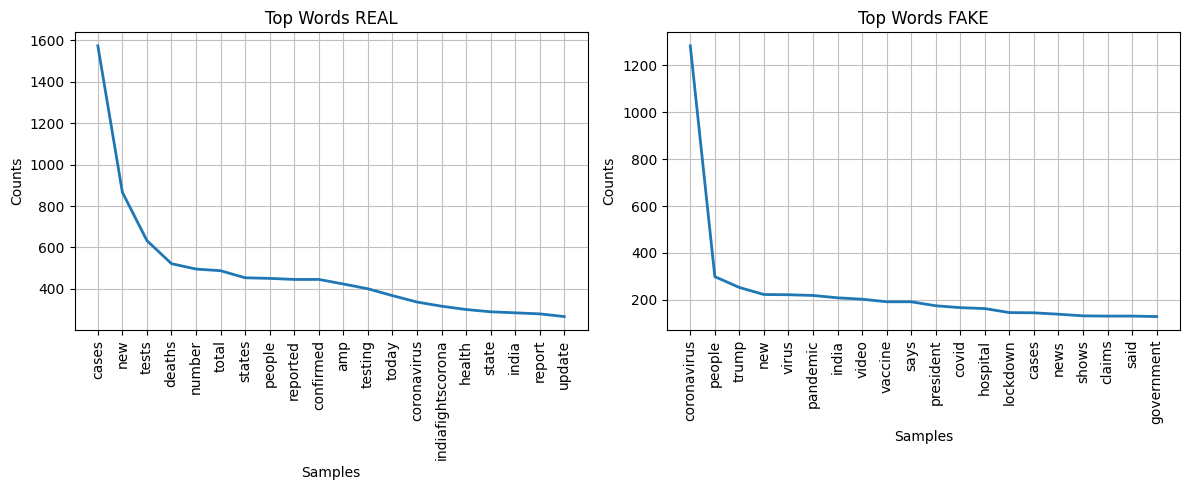

In [26]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
fdist_real_clean.plot(20, cumulative=False)
plt.title("Top Words REAL")

plt.subplot(1,2,2)
fdist_fake_clean.plot(20, cumulative=False)
plt.title("Top Words FAKE")

plt.tight_layout()
plt.show()

#### Word Frequency Analysis - Key Findings:

**Fake Tweets:**
- **"coronavirus"** dominates with **>1200 occurrences** - far exceeding other terms
- **Relatively uniform distribution** for remaining words (no strong secondary peaks)
- Suggests **linguistically diverse content** with one dominant keyword
- Possible over-reliance on the term "coronavirus" for attention/visibility

**Real Tweets:**
- **"cases"** is the top term - likely referring to "confirmed cases" or "new cases"
- Strong presence of data-oriented terms:
  - **"new"**: reporting new developments
  - **"tests"**: testing statistics
  - **"deaths"**: mortality reporting
- **More pronounced frequency hierarchy** - clear differences between top terms

**Comparative Insights:**
- **Real tweets**: Focus on **quantitative reporting** (cases, tests, deaths, numbers)
- **Fake tweets**: More **generalized language** with broader vocabulary spread
- **Real tweets**: Follow journalistic conventions with standardized terminology
- **Fake tweets**: Higher lexical diversity (as seen in previous analysis) with less repetition of specific factual terms



### 1.3.7 N-gram Analysis - Multi-word Phrase Patterns

**Definition:** N-grams are contiguous sequences of n words from a text. They capture multi-word expressions and phrases that single words cannot reveal.

**Types of N-grams:**
- **Bigrams (2-grams)**: Two consecutive words (e.g., "social distancing", "Donald Trump")
- **Trigrams (3-grams)**: Three consecutive words (e.g., "Centers for Disease Control")

**Why N-grams Matter:**
- **Context preservation**: Captures meaning lost in single-word analysis
  - "fake news" has different meaning than "fake" + "news" separately
- **Phrase detection**: Identifies common expressions, names, and collocations
- **Sentiment nuances**: "not good" has opposite meaning to its components
- **Named entities**: Multi-word names (people, organizations, locations)
- **Domain terminology**: Medical/scientific phrases like "herd immunity"

**Analysis Approach:**
1. Generate bigrams from cleaned tokens for each class
2. Calculate frequency distributions of bigrams
3. Visualize top 15 most frequent bigrams
4. Compare phrase patterns between real and fake tweets

**Expected Insights:**
- Real tweets may contain more formal phrases and official terminology
- Fake tweets might include sensational phrases or named entities for clickbait
- Different communication strategies revealed through phrase structure

In [27]:
bigrams_real = list(ngrams(tokens_real_clean, 2))
bigrams_fake = list(ngrams(tokens_fake_clean, 2))

trigrams_real = list(ngrams(tokens_real_clean, 3))
trigrams_fake = list(ngrams(tokens_fake_clean, 3))

In [28]:
fdist_bi_real = FreqDist(bigrams_real)
fdist_bi_fake = FreqDist(bigrams_fake)

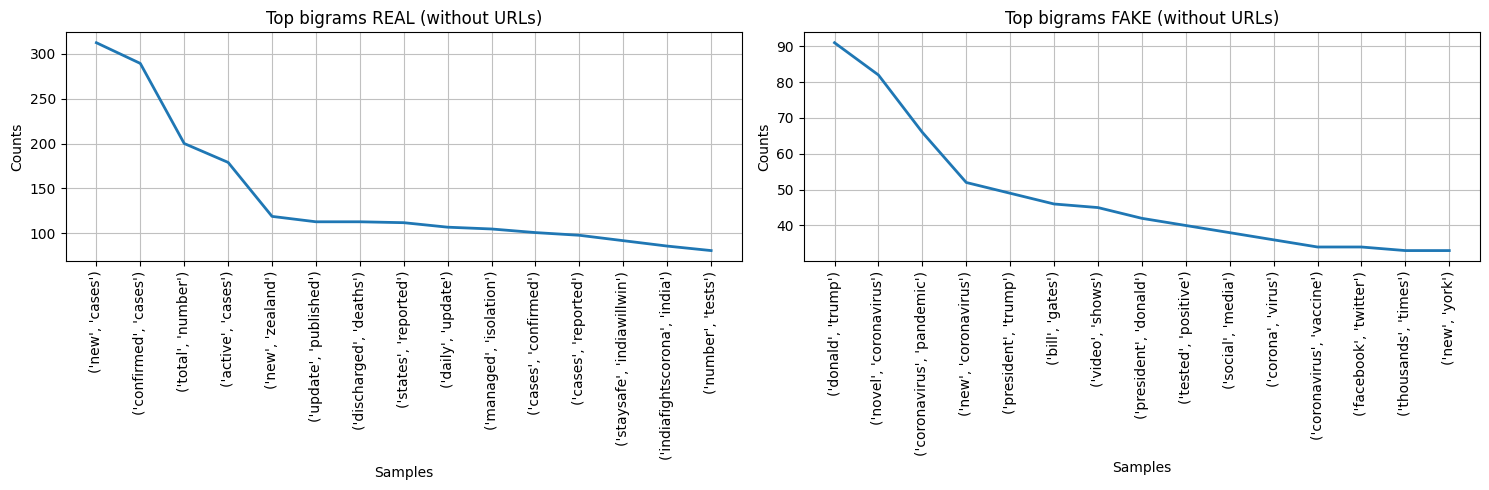

In [29]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
fdist_bi_real.plot(15, cumulative=False)
plt.title("Top bigrams REAL (without URLs)")

plt.subplot(1,2,2)
fdist_bi_fake.plot(15, cumulative=False)
plt.title("Top bigrams FAKE (without URLs)")

plt.tight_layout()
plt.show()

#### N-gram Analysis - Key Findings:

**Real Tweets - Bigram Patterns:**
- **Data-focused phrases**: "new cases", "active cases"
- **Official sources**: References to authorities and institutions
- **Factual reporting style**: Phrases related to statistics and official statements
- **Journalistic language**: Standard news reporting terminology

**Fake Tweets - Bigram Patterns:**
1. **"coronavirus" appears frequently** in bigram combinations
   - Likely part of hashtags: #coronavirus
   - Positioned at end of tweets after links (common Twitter pattern)
2. **"donald trump"**: Appears **~100 times**
   - Significant presence of political figures
   - Strategy to attract attention through controversy
3. **"coronavirus pandemic"**: High frequency
   - Possibly alarmist hashtag combinations like #coronavirus #pandemic
   - Designed to maximize visibility and emotional impact

**Strategic Differences:**
- **Real tweets**: Focus on information delivery with institutional references
- **Fake tweets**: Leverage **attention-grabbing tactics**:
  - Named entities (political figures)
  - Sensational pairings
  - Appeal to emotion and controversy



### 1.3.8 Part-of-Speech (POS) Tagging - Grammatical Structure Analysis

**Definition:** Part-of-Speech tagging assigns grammatical categories (noun, verb, adjective, etc.) to each word in a text, revealing syntactic structure and writing style.

**POS Categories (Universal Dependencies):**
- **NOUN**: Common nouns (virus, doctor, hospital)
- **PROPN**: Proper nouns (Trump, China, WHO)
- **VERB**: Actions (spread, infect, died)
- **ADJ**: Adjectives (deadly, confirmed, positive)
- **ADV**: Adverbs (quickly, recently, very)
- **ADP**: Prepositions (in, at, from)
- **DET**: Determiners (the, a, this)
- And others...

**Why POS Analysis Matters:**
- **Writing style indicators**: Formal vs. informal language patterns
- **Content type**: News (more nouns) vs. opinion (more adjectives/adverbs)
- **Objectivity measures**: Higher adjective/adverb ratios suggest subjective content
- **Grammatical complexity**: Variety of POS indicates sophisticated language
- **Misinformation markers**: Emotional language often uses more descriptive words

**Methodology:**
1. Use spaCy's `en_core_web_sm` model for accurate POS tagging
2. Extract POS tags for all alphabetic tokens in each tweet
3. **Normalize by class**: Calculate relative frequencies (percentages) to account for class imbalance
4. Compare distributions between real and fake tweets

**Why Normalization:** Since we have different numbers of real vs. fake tweets, we use proportions rather than raw counts for fair comparison.

**Implementation Notes:**

We analyze POS distribution by comparing relative frequencies rather than absolute counts. This normalization is crucial because:
- **Class imbalance**: More real tweets than fake tweets in the dataset
- **Fair comparison**: Percentages allow direct comparison regardless of sample size
- **Statistical validity**: Proportions reveal true linguistic differences, not just volume differences

In [30]:
def pos_distribution(text):
    doc = nlp(text)
    return [token.pos_ for token in doc if token.is_alpha]

In [31]:
df['pos_tags'] = df['tweet'].astype(str).apply(pos_distribution)

In [32]:
# By class
pos_real = [p for tags in df[df['label'] == 'real']['pos_tags'] for p in tags]
pos_fake = [p for tags in df[df['label'] == 'fake']['pos_tags'] for p in tags]
from collections import Counter

# Counts
pos_real_counts = Counter(pos_real)
pos_fake_counts = Counter(pos_fake)

# Totals
total_pos_real = sum(pos_real_counts.values())
total_pos_fake = sum(pos_fake_counts.values())

# Relative frequencies
pos_real_freq = {k: v / total_pos_real for k, v in pos_real_counts.items()}
pos_fake_freq = {k: v / total_pos_fake for k, v in pos_fake_counts.items()}

In [33]:
pos_df = pd.DataFrame({
    'REAL': pd.Series(pos_real_freq),
    'FAKE': pd.Series(pos_fake_freq)
}).fillna(0)

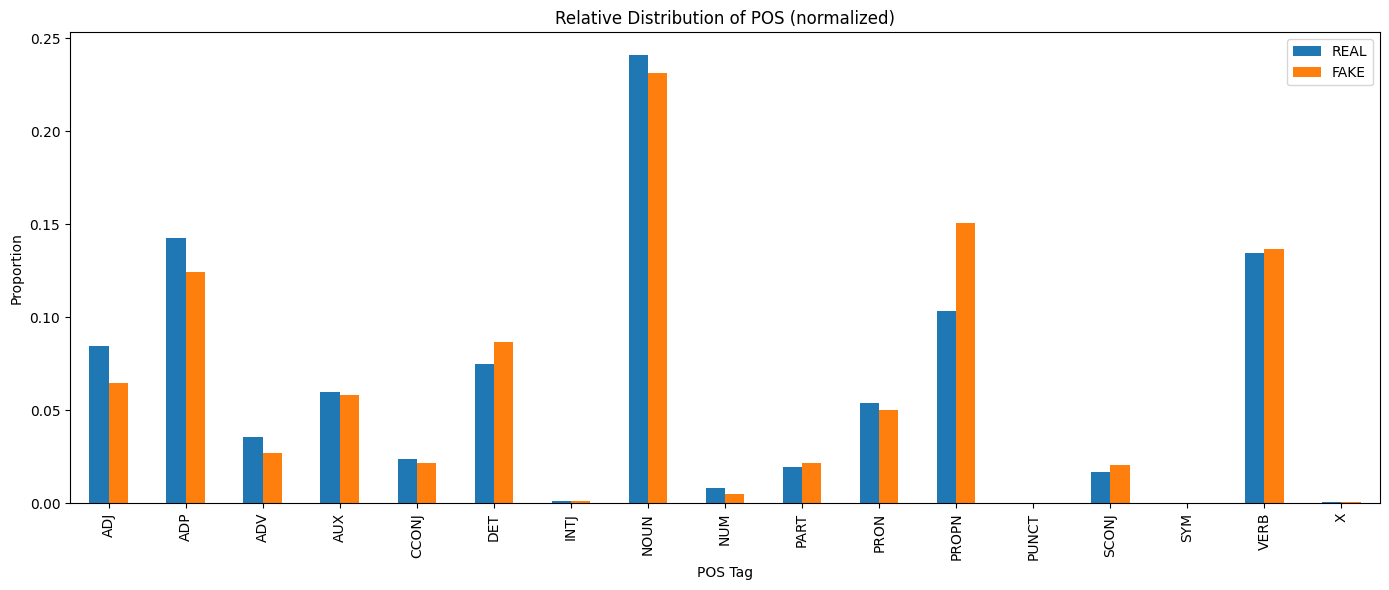

In [34]:
pos_df.plot(kind='bar', figsize=(14,6))
plt.title("Relative Distribution of POS (normalized)")
plt.ylabel("Proportion")
plt.xlabel("POS Tag")
plt.legend()
plt.tight_layout()
plt.show()

#### POS Distribution Analysis - Key Findings:

**Common Ground:**
- **NOUN (Common Nouns)**: Predominate similarly in both classes
  - Expected: COVID-19 discourse centers on concrete concepts (virus, cases, deaths, etc.)
  - No significant difference suggests similar topical focus

**Key Difference - PROPN (Proper Nouns):**
- **Fake tweets show significantly higher proportion** of proper nouns
- **Interpretation:**
  - More frequent mention of **specific people** (Donald Trump, political figures, celebrities)
  - References to **specific places** (countries, cities, institutions)
  - **Strategic naming**: Using recognizable names to attract attention
  - **Personalization**: More personal, less institutional language
  - **Emotional appeal**: Connecting abstract topics to familiar figures

**Stylistic Implications:**
- **Real tweets**: More **institutional and generalized** language
  - Focus on facts, statistics, and general concepts
  - Professional journalistic style with less personalization
  
- **Fake tweets**: More **personal and persuasive** discourse
  - Name-dropping to establish credibility or controversy
  - Emotional connection through familiar entities
  - Attention-grabbing through celebrity/political references



### 1.3.9 Named Entity Recognition (NER) - Real-World Entity Analysis

**Definition:** Named Entity Recognition identifies and classifies real-world entities mentioned in text into predefined categories.

**Entity Types (spaCy NER Categories):**
- **PERSON**: People (Donald Trump, Dr. Fauci)
- **GPE**: Geopolitical entities - countries, cities, states (China, New York, USA)
- **ORG**: Organizations (WHO, CDC, hospitals)
- **DATE**: Temporal references (March 2020, yesterday)
- **CARDINAL**: Numerical values (10,000 cases, 50 deaths)
- **NORP**: Nationalities, religious/political groups (American, Republican, Christian)
- **LOC**: Locations (Europe, Pacific Ocean)
- **MONEY**: Monetary values
- **PERCENT**: Percentages
- And others...

**Why NER Matters for Fake News Detection:**
- **Factual grounding**: Real news cites specific entities, dates, and numbers
- **Verification potential**: Named entities can be fact-checked
- **Content characterization**: Entity types reveal content focus
- **Credibility signals**: Specific references suggest research vs. vague claims
- **Emotional manipulation**: Excessive person mentions may indicate opinion over facts

**Methodology:**
1. Apply spaCy's NER model to extract all entities from tweets
2. Separate entities by class (real vs fake)
3. **Normalize by percentage**: Calculate relative frequencies to account for class imbalance
4. Compare entity distributions between classes

**Expected Insights:**
Real news should show more dates, numbers (CARDINAL), and organizations. Fake news might emphasize people (PERSON) and nationalities (NORP) for emotional appeal.

In [35]:
def extract_entities(text):
    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

df['entities'] = df['tweet'].astype(str).apply(extract_entities)

In [36]:
entities_real = [e for ents in df[df['label'] == 'real']['entities'] for e in ents]
entities_fake = [e for ents in df[df['label'] == 'fake']['entities'] for e in ents]

In [37]:
ent_real_counts = Counter(entities_real)
ent_fake_counts = Counter(entities_fake)

total_ent_real = sum(ent_real_counts.values())
total_ent_fake = sum(ent_fake_counts.values())

In [38]:
ent_real_freq = {k: v / total_ent_real for k, v in ent_real_counts.items()}
ent_fake_freq = {k: v / total_ent_fake for k, v in ent_fake_counts.items()}

In [39]:
ent_df = pd.DataFrame({
    'REAL': pd.Series(ent_real_freq),
    'FAKE': pd.Series(ent_fake_freq)
}).fillna(0)

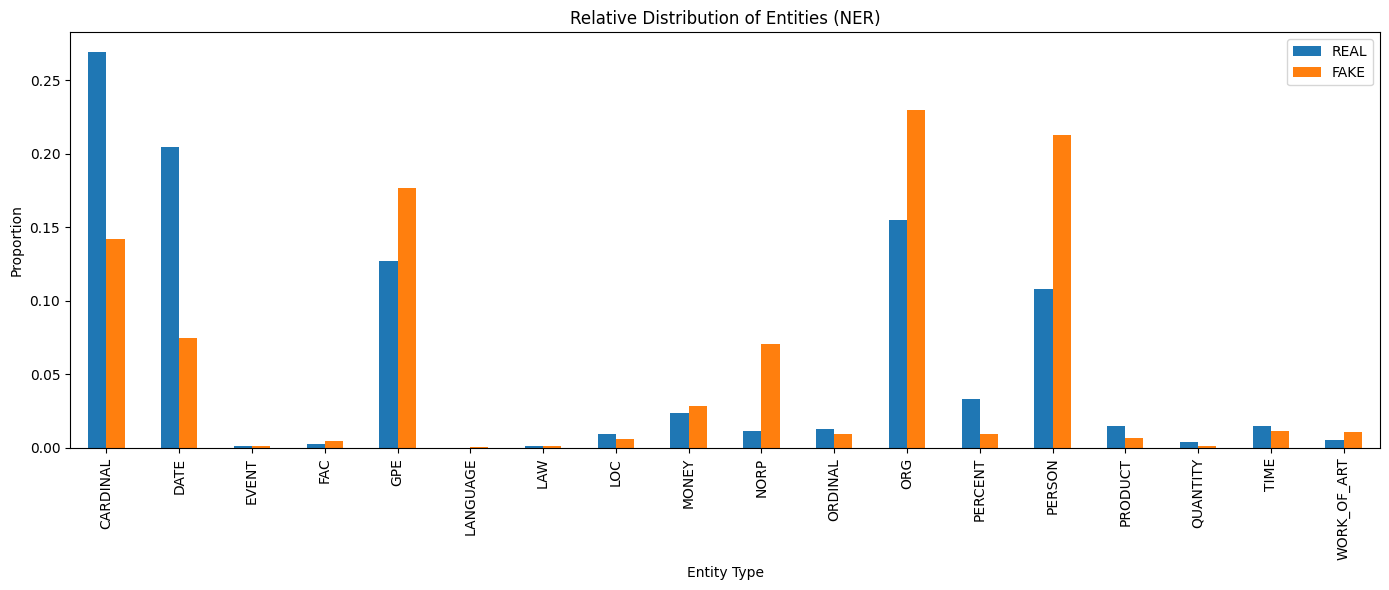

In [40]:
ent_df.plot(kind='bar', figsize=(14,6))
plt.title("Relative Distribution of Entities (NER)")
plt.ylabel("Proportion")
plt.xlabel("Entity Type")
plt.legend()
plt.tight_layout()
plt.show()

#### Named Entity Analysis - Key Findings:

**CARDINAL (Numbers) - Real Tweets Predominate:**
- **Clear winner for real news**: Significantly higher proportion
- **Interpretation**: Real tweets report **quantitative data**
  - Case counts: "500 new cases"
  - Death tolls: "100 deaths reported"
  - Testing numbers: "10,000 tests conducted"
- **Journalistic standard**: Data-driven reporting with specific figures
- **Verification potential**: Numbers can be fact-checked against official sources

**DATE Entities - Real Tweets Higher:**
- **More temporal references** in real tweets
- **Timely reporting**: News articles specify when events occurred
- **Examples**: "March 15", "yesterday", "last week"
- **Credibility marker**: Temporal specificity suggests careful documentation

**PERSON Entities - Fake Tweets Higher:**
- **Fake tweets mention people more frequently**
- **Attention strategy**: Using recognizable names (as seen with "Donald Trump" in n-grams)
- **Personalization**: More focus on individuals rather than data
- **Emotional connection**: Names evoke stronger reactions than statistics

**ORG (Organizations) - Fake Tweets Higher:**
- **Surprising finding**: More organizational mentions in fake tweets
- **Possible explanations**:
  - References to institutions to claim credibility
  - Conspiracy theories involving organizations
  - Mention of media outlets or tech companies

**NORP (Nationalities/Groups) - Notable in Fake Tweets:**
- **Very clear predominance** in fake tweets (even if overall percentages are small)
- **Political/social identity focus**: "Americans", "Democrats", "Republicans", "Chinese"
- **Divisive language**: Appealing to group identities
- **Ideological framing**: More common in opinion/misinformation than factual reporting
- **Us vs. them rhetoric**: Characteristic of persuasive/manipulative content

**Overall Pattern:**
- **Real tweets**: Focus on **data and temporal facts** (numbers, dates)
- **Fake tweets**: Focus on **people and group identities** (persons, NORP, organizations)
- **Implication**: Real news prioritizes **"what" and "when"** with data, while fake news emphasizes **"who"** with emotional and ideological framing.

### 1.3.10 Hashtags and Mentions Analysis - Social Media Engagement Patterns

**Definition:** Analysis of Twitter-specific features that characterize social media engagement and information dissemination strategies.

**Features Analyzed:**
1. **Hashtags (#)**: Topical markers used for categorization and discoverability
   - Example: #COVID19, #coronavirus, #pandemic
   - Purpose: Increase visibility, join conversations, categorize content
   
2. **Mentions (@)**: References to other Twitter users
   - Example: @WHO, @CDCgov, @realDonaldTrump
   - Purpose: Attribution, engagement, directing content to specific accounts

**Why These Features Matter:**
- **Engagement strategy**: Different usage patterns between news outlets and misinformation spreaders
- **Source attribution**: Real news may mention official sources more frequently
- **Virality tactics**: Strategic hashtag use to maximize reach
- **Community building**: Mentions create networks of information flow
- **Professional conventions**: News organizations follow specific social media practices

**Methodology:**
1. Count hashtags: Sum all tokens starting with "#" in each tweet
2. Count mentions: Sum all tokens starting with "@" in each tweet
3. Calculate mean values per class to identify average usage patterns
4. Compare between real and fake tweets

**Expected Patterns:**
- Real news might use more mentions (citing sources)
- Fake news might use more hashtags (maximizing reach)
- Or vice versa - data will reveal actual patterns

In [41]:
def count_hashtags(text):
    return sum(1 for w in text.split() if w.startswith("#"))

def count_mentions(text):
    return sum(1 for w in text.split() if w.startswith("@"))

df['num_hashtags'] = df['tweet'].apply(count_hashtags)
df['num_mentions'] = df['tweet'].apply(count_mentions)

In [42]:
df.groupby('label')[['num_hashtags', 'num_mentions']].mean()

,num_hashtags,num_mentions
label,,
fake,0.508170,0.181046
real,1.052976,0.427381


#### Hashtag & Mention Analysis - Key Findings:

**Real Tweets - Higher Usage of Both Features:**
- **More hashtags** per tweet on average
- **More mentions** per tweet on average

**Interpretation:**

**Hashtags:**
- **Real news uses more hashtags** despite being factual content
- **Possible reasons**:
  - News organizations follow social media best practices
  - Categorization for topic tracking and archives
  - Standardized hashtags for COVID-19 reporting (#COVID19, #coronavirus)
  - Professional social media strategy for reach

**Mentions:**
- **Real news mentions more accounts**
- **Likely explanations**:
  - **Source attribution**: Citing official accounts (@WHO, @CDCgov, @NIH)
  - **Quote tweets**: Sharing statements from authorities
  - **Professional courtesy**: Tagging organizations and experts referenced
  - **Verification practice**: Linking to verifiable sources

**Fake Tweets - Lower Usage:**
- **Fewer hashtags and mentions**
- **Possible interpretations**:
  - Less concern with professional conventions
  - Focus on content over metadata
  - Avoiding linkage to verifiable sources
  - More standalone/original (unverified) content

**Surprising Insight:** Contrary to initial hypothesis (that fake news would use more hashtags for virality), real news demonstrates more sophisticated social media engagement through both hashtags and mentions.

**Implication:** Social media metadata (hashtags and mentions) could serve as features for classification models, with higher counts potentially indicating real news.

## 1.4 Additional EDA Analysis - Sentiment & Stylistic Features

Having completed comprehensive linguistic analysis of vocabulary, grammar, and entities, we now extend our investigation to emotional and stylistic dimensions. This section explores:

1. **Sentiment Analysis**: Emotional polarity and tone
2. **Punctuation Patterns**: Stylistic emphasis and persuasion tactics

These additional features provide insight into the **emotional manipulation** and **rhetorical strategies** that may distinguish misinformation from factual reporting. While real news aims for objectivity, fake news often employs emotional appeals to persuade and engage readers.

### 1.4.1 Sentiment Analysis - Emotional Polarity Detection

**Objective:** Analyze the emotional tone of tweets to determine if fake news tends to be more emotional, negative, or sensationalist compared to factual reporting.

**Tool: VADER (Valence Aware Dictionary and Sentiment Reasoner)**
- **Specifically designed for social media text** including tweets
- Handles informal language, slang, emoticons, and capitalization
- Produces sentiment scores: positive, negative, neutral, and compound

**Compound Score:**
- **Range**: -1 (most negative) to +1 (most positive)
- **Interpretation**:
  - Positive: ≥ 0.05
  - Neutral: between -0.05 and 0.05
  - Negative: ≤ -0.05

**Why VADER for Tweets:**
- Trained on social media data
- Captures intensifiers ("very good", "!!!", "ALL CAPS")
- Understands negations and contractions
- No training required - lexicon-based approach

**Hypothesis:** 
Fake news may exhibit more extreme sentiment (either very negative to induce fear, or very positive for clickbait) compared to the neutral, objective tone expected in real news reporting.

**Analysis Plan:**
1. Calculate compound sentiment scores for all tweets
2. Compare distributions between real and fake classes
3. Examine mean sentiment values
4. Visualize using box plots to identify patterns

In [43]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rodri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [44]:
def sentiment_scores(text):
    scores = sia.polarity_scores(text)
    return scores['compound']

In [45]:
df['sentiment'] = df['tweet'].astype(str).apply(sentiment_scores)

In [46]:
df.groupby('label')['sentiment'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
fake,3060.0,-0.063438,0.422348,-0.9914,-0.4019,0.0,0.2023,0.9688
real,3360.0,0.069161,0.406152,-0.9648,-0.1531,0.0,0.4019,0.9571


#### Sentiment Analysis - Statistical Summary:

**Mean Sentiment Scores:**
- **Fake tweets**: -0.063 (slightly negative)
- **Real tweets**: +0.069 (slightly positive)

**Key Observations:**
- Both classes are close to neutral (around 0)
- **Fake news leans negative**, potentially using fear, alarm, or criticism
- **Real news leans positive**, possibly reflecting hopeful reporting or recovery stories
- The difference, while small, is consistent and meaningful

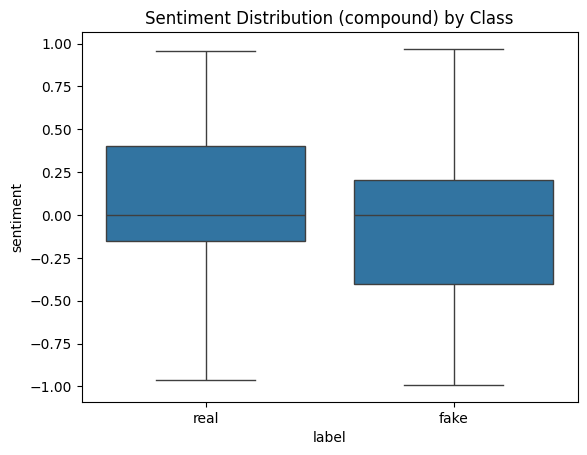

In [47]:
sns.boxplot(data=df, x='label', y='sentiment')
plt.title("Sentiment Distribution (compound) by Class")
plt.show()

####  Sentiment Distribution - Visual Analysis:

The boxplot visualization clearly confirms our statistical findings:

**Real Tweets:**
- **Generally more positive** sentiment distribution
- Median close to neutral with slight positive bias
- More balanced spread across sentiment range

**Fake Tweets:**
- **Tendency toward negative sentiment**
- Lower median value (below neutral)
- Possible explanations:
  - **Fear-mongering**: Catastrophic predictions to grab attention
  - **Criticism**: Attacking authorities, policies, or responses
  - **Conspiracy narratives**: Often negative toward institutions
  - **Alarmist language**: Emphasizing dangers and threats

**Interpretation:**
Real news, while reporting on a pandemic (inherently negative topic), maintains more balanced or even hopeful tone through:
- Reporting on recoveries and positive developments
- Objective, neutral language even when discussing challenges
- Solutions-focused reporting

Fake news exploits emotional responses through:
- Amplifying fears and anxieties
- Presenting worst-case scenarios
- Using negative framing to engage and persuade

**Classification Potential:** Sentiment polarity could be a useful feature for distinguishing real from fake COVID-19 tweets.

### 1.4.2 Punctuation & Capitalization Analysis - Stylistic Emphasis Patterns

**Objective:** Examine stylistic writing patterns through punctuation and capitalization to identify markers of sensationalism or emotional emphasis.

**Features Analyzed:**

1. **Exclamation Marks (!)**
   - Express excitement, urgency, alarm, or emphasis
   - Overuse associated with sensationalist writing
   - Example: "BREAKING!!!" vs. "New study shows..."

2. **Question Marks (?)**
   - Engage readers, create intrigue, or express doubt
   - Rhetorical questions are persuasive techniques
   - Example: "Can you believe this??" vs. factual statement

3. **Uppercase Ratio**
   - Percentage of uppercase letters in text
   - ALL CAPS indicates SHOUTING or emphasis
   - Professional writing uses standard capitalization

**Why These Features Matter:**
- **Professionalism indicator**: News outlets follow style guidelines with minimal exclamations
- **Emotional intensity**: Excessive punctuation suggests heightened emotional state
- **Persuasive tactics**: Questions engage readers and create doubt
- **Attention-seeking**: Visual emphasis (caps) is clickbait characteristic
- **Credibility signal**: Professional journalism uses punctuation sparingly

**Hypothesis:** Fake news will show higher rates of exclamations, questions, and capitalization as part of sensationalist and attention-grabbing strategies.

**Methodology:**
1. Count exclamation marks in each tweet
2. Count question marks in each tweet
3. Calculate ratio of uppercase letters to total characters
4. Compare mean values between real and fake tweets
5. Visualize distributions to identify patterns

In [48]:
def count_exclamations(text):
    return text.count('!')

def count_questions(text):
    return text.count('?')

def uppercase_ratio(text):
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)

In [49]:
df['num_exclamations'] = df['tweet'].astype(str).apply(count_exclamations)
df['num_questions'] = df['tweet'].astype(str).apply(count_questions)
df['uppercase_ratio'] = df['tweet'].astype(str).apply(uppercase_ratio)

#### Statistical Summary by Label:

In [50]:
df.groupby('label')[['num_exclamations', 'num_questions', 'uppercase_ratio']].mean()

,num_exclamations,num_questions,uppercase_ratio
label,,,
fake,0.101307,0.430719,0.075805
real,0.016667,0.021429,0.078647


####  Punctuation & Capitalization - Key Findings:

**Exclamation Marks:**
- **Fake tweets**: 0.101 per tweet (average)
- **Real tweets**: Lower usage
- **Interpretation**: Fake news uses exclamations to create **urgency and alarm**

**Question Marks: (Most Significant Difference!)**
- **Fake tweets**: 0.431 per tweet - **dramatically higher**
- **Real tweets**: Much lower
- **Interpretation**: 
  - **Rhetorical questions** as persuasion technique
  - Creating doubt: "Is this the truth?"
  - Engagement tactic: "What do you think?"
  - Conspiracy framing: "Why aren't they telling us?"
  - Real news states facts; fake news questions and insinuates

**Uppercase Ratio:**
- **Nearly tied** between both classes
- **Surprising result**: Expected more ALL CAPS in fake news
- **Interpretation**: Both use hashtags (#COVID19) which increase uppercase ratio

**Overall Pattern:**
- **Fake tweets**: More **interactive and emotional** punctuation
  - Questions engage and create doubt
  - Exclamations convey urgency
  - Persuasive rhetoric over informative content

- **Real tweets**: More **declarative and straightforward**
  - Statements over questions
  - Facts over emotional appeals
  - Professional writing conventions

**Classification Insight:** Question mark frequency is a **strong discriminative feature** - significantly elevated in fake news, making it valuable for classification models.

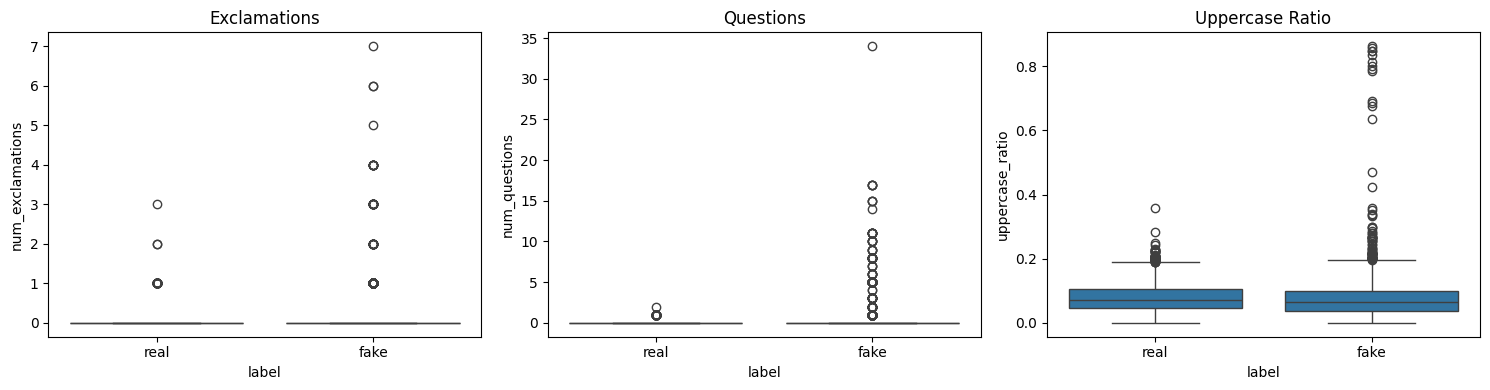

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='label', y='num_exclamations', ax=axes[0])
axes[0].set_title("Exclamations")

sns.boxplot(data=df, x='label', y='num_questions', ax=axes[1])
axes[1].set_title("Questions")

sns.boxplot(data=df, x='label', y='uppercase_ratio', ax=axes[2])
axes[2].set_title("Uppercase Ratio")

plt.tight_layout()
plt.show()

**Visual Analysis - Box Plot Interpretation:**

The box plots reveal important patterns across the three punctuation/capitalization metrics:

1. **Exclamation Marks**: Fake tweets show higher median and greater variance in exclamation usage

2. **Question Marks**: Fake tweets demonstrate notably higher usage and more outliers, consistent with rhetorical questioning strategies

3. **Uppercase Ratio**: Both classes show similar medians, but fake tweets exhibit **more extreme outliers** - indicating some fake tweets use ALL CAPS extensively

**Outlier Significance:**
The presence of more uppercase outliers in fake tweets suggests a subset of misinformation content uses aggressive visual emphasis tactics (SHOUTING in text) to capture attention and convey urgency.

**Classification Implications:**
While average uppercase ratios are similar, fake tweets show greater variability and extreme values. Combining this with exclamation and question mark frequency creates a stronger feature set for distinguishing tweet authenticity.

### 1.4.3 URL and Domain Analysis

**Objective:** Investigate URL usage patterns and analyze which web domains are most frequently shared in real vs. fake tweets to identify source credibility patterns.

**Why URL Analysis Matters:**
- **Source credibility**: Real news typically links to reputable sources (official health organizations, mainstream media)
- **Verification potential**: URLs can be checked for domain reputation and content authenticity
- **Information tracing**: Tracking shared domains reveals misinformation networks
- **Citation patterns**: Real news cites sources; fake news may lack citations or use dubious sites

**Analysis Approach:**
1. Extract all URLs from tweets using regular expressions
2. Parse URLs to extract domain names
3. Compare domain frequency distributions between real and fake tweets
4. Identify most commonly shared domains in each class
5. Analyze URL usage rates (percentage of tweets with links)

**Expected Patterns:**
- Real tweets: Links to .gov, official health organizations, established news outlets
- Fake tweets: Links to unknown sites, blogs, or lack of citations

In [52]:
import re
from urllib.parse import urlparse

In [53]:
def extract_urls(text):
    pattern = r'https?://[^\s\)\]\}]+|www\.[^\s\)\]\}]+|(?:t\.co|bit\.ly|youtu\.be|goo\.gl|ow\.ly|tinyurl\.com)/[^\s\)\]\}]+'
    urls = re.findall(pattern, text)
    return [url.rstrip('.,;:!?\'\"…') for url in urls]

In [54]:
df['urls'] = df['tweet'].astype(str).apply(extract_urls)

In [55]:
def extract_domains(urls):
    domains = []
    for url in urls:
        try:
            parsed = urlparse(url if url.startswith('http') else 'http://' + url)
            domains.append(parsed.netloc)
        except:
            continue
    return domains

In [56]:
df['domains'] = df['urls'].apply(extract_domains)

**Domain Extraction by Class:**

We separate URLs by class and extract the top 10 most frequently shared domains for both real and fake tweets.

In [57]:
domains_real = [d for domains in df[df['label'] == 'real']['domains'] for d in domains]
domains_fake = [d for domains in df[df['label'] == 'fake']['domains'] for d in domains]

FreqDist(domains_real).most_common(10)
FreqDist(domains_fake).most_common(10)

[('t.co', 1252),
 ('bit.ly', 1),
 ('www.tatahealth.com', 1),
 ('patents.justia.com', 1)]

**Key Finding - Twitter URL Shortener Dominance:**

The **t.co domain** clearly dominates both datasets (real and fake tweets). This is expected because:

**What is t.co?**
- **Twitter's official URL shortener**: Automatically applied to all links posted on Twitter
- **Character saving**: Reduces URL length to preserve tweet character limits
- **Click tracking**: Allows Twitter to track link engagement and prevent malicious content
- **Universal usage**: Appears in both real and fake tweets regardless of original URL

**Implication for Analysis:**
- The prevalence of t.co makes raw domain analysis challenging
- We cannot determine original sources from shortened URLs without expanding them
- However, the **frequency of URL usage** itself is still a valuable metric
- Future analysis could involve expanding t.co links to reveal original domains

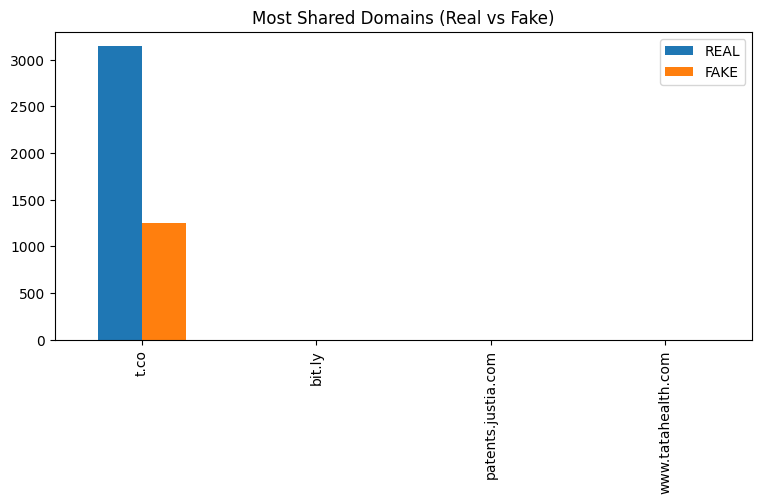

In [58]:
pd.DataFrame({
    'REAL': pd.Series(FreqDist(domains_real)),
    'FAKE': pd.Series(FreqDist(domains_fake))
}).fillna(0).sort_values(by='FAKE', ascending=False).head(10).plot(kind='bar', figsize=(9,4))

plt.title("Most Shared Domains (Real vs Fake)")
plt.show()

**Conclusions - URL Usage Patterns:**

While domain-specific analysis is limited by Twitter's URL shortener (t.co), the visualization reveals important insights:

**Quantitative Finding:**
- **Real tweets contain significantly more URLs** - more than double the frequency of fake tweets
- This pattern is visible even when t.co dominates both categories

**Interpretation:**

**Real tweets (higher URL frequency):**
- **Source citation**: Journalistic standards require citing sources
- **Evidence-based reporting**: Links to official data, studies, reports
- **Credibility building**: References to reputable institutions
- **Information sharing**: Directing readers to full articles or official statements

**Fake tweets (lower URL frequency):**
- **Unsubstantiated claims**: Less need for citations when making false assertions
- **Opinion-based content**: Personal commentary without evidence
- **Original fabrication**: Made-up stories don't have sources to cite
- **Attention-grabbing headlines**: Sensational claims without backing

**Classification Potential:**
URL presence/absence is a simple but effective binary feature for fake news detection. Real news has a higher probability of including source links.

## 2. Uninformed Search - Topic Modeling with BERTopic

In the previous exploratory analysis, we identified linguistic patterns and features that distinguish real from fake tweets. However, that analysis was **supervised** - we knew the labels and analyzed differences between classes.

Now we shift to **unsupervised learning** to discover the underlying thematic structure of the tweets **without using the real/fake labels**. This approach is called **"uninformed search"** because the algorithm explores the data space without prior knowledge of tweet authenticity.

**Why Topic Modeling?**

Topic modeling is an unsupervised machine learning technique that automatically discovers abstract "topics" or themes within a large collection of documents. Each topic is characterized by a cluster of semantically related words.

**Objectives:**

1. **Discover natural groupings**: Identify what themes and narratives exist in COVID-19 tweets
2. **Semantic analysis**: Understand what topics dominate the discourse
3. **Label distribution**: After discovering topics, analyze how real vs. fake tweets distribute across them
4. **Feature engineering**: Topic assignments can serve as features for supervised classification

**What is BERTopic?**

BERTopic is a state-of-the-art topic modeling technique that combines:
- **BERT embeddings**: Rich semantic representations of text
- **Dimensionality reduction**: UMAP to compress high-dimensional embeddings
- **Clustering**: HDBSCAN or other algorithms to group similar documents
- **Topic representation**: c-TF-IDF to extract characteristic words for each topic

Unlike traditional methods (LDA), BERTopic leverages transformer models to capture deep semantic meanings, resulting in more coherent and interpretable topics.

### 2.1 Data Preparation - Text Cleaning

Before applying topic modeling, we need to clean the text to remove noise that doesn't contribute to semantic meaning.

**Cleaning Operations:**

1. **Remove URLs**: Links (http://, https://, www.) are replaced with spaces
   - URLs don't carry topical information for clustering
   - Already analyzed separately in previous section

2. **Remove special characters**: Keep only alphabetic characters and spaces
   - Removes punctuation, numbers, symbols
   - Focuses algorithm on word semantics

3. **Normalize whitespace**: Replace multiple spaces with single space and trim
   - Ensures consistent formatting

4. **Lowercase conversion**: Convert all text to lowercase
   - "COVID", "Covid", "covid" treated as same word

**Important Note:**
Unlike the EDA preprocessing, we do NOT remove stopwords here. Modern transformer-based embeddings (BERT) can handle stopwords effectively, and they may carry contextual information useful for semantic understanding.

In [59]:
import re

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", " ", text)        # Only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text.lower()

train_df['cleaned_tweet'] = train_df['tweet'].astype(str).apply(clean_text)

### 2.2 Vector Representation - Sentence Embeddings

**From Text to Numbers:**

Machine learning algorithms cannot directly process text - they require numerical representations. We convert each tweet into a high-dimensional vector (embedding) that captures its semantic meaning.

**Model: all-MiniLM-L6-v2**

We use the **sentence-transformers/all-MiniLM-L6-v2** model, which:
- Is a **BERT-based transformer** fine-tuned for semantic similarity tasks
- Produces **384-dimensional vectors** for each tweet
- Captures semantic meaning: similar tweets have similar embeddings
- Is efficient: balanced between quality and computational cost
- Was trained on over 1 billion sentence pairs

**How It Works:**

1. Each cleaned tweet is passed through the model
2. The model outputs a 384-dimensional vector
3. Semantically similar tweets cluster together in this vector space
4. These embeddings serve as input for clustering algorithms

**Why This Matters:**

Unlike traditional bag-of-words approaches, transformer embeddings understand:
- **Context**: "bank" in "river bank" vs. "financial bank"
- **Semantics**: "doctor" and "physician" are similar
- **Relationships**: "virus spreads" and "infection transmits" are related

This rich representation enables discovering meaningful, coherent topics.

In [60]:
from sentence_transformers import SentenceTransformer

documents = train_df['cleaned_tweet'].tolist()

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

Batches:   0%|          | 0/201 [00:00<?, ?it/s]

### 2.3 Dimensionality Selection - Adapted Elbow Method

**The Challenge:**

Our embeddings are 384-dimensional, which is computationally expensive for clustering and can introduce noise. We need to reduce dimensionality using UMAP (Uniform Manifold Approximation and Projection).

**The Question:** How many dimensions should we reduce to?

**Adapted Elbow Method for NLP:**

Unlike K-Means where we select the number of clusters (k), here we select the number of dimensions (n_components) for UMAP. We evaluate different dimensionalities by:

1. Reducing embeddings to different dimensions (2, 5, 10, 15, 20)
2. Clustering the reduced embeddings with HDBSCAN
3. Calculating **silhouette score** for each configuration
4. Selecting the dimensionality with best cluster quality

**Silhouette Score:**
- Range: -1 to +1
- **Closer to +1**: Well-separated, cohesive clusters
- **Near 0**: Overlapping clusters
- **Negative**: Poorly formed clusters

**Important Note:**
This method is not as definitive as the elbow method for K-Means. It provides guidance rather than a clear optimal point, because:
- HDBSCAN discovers clusters automatically (variable number)
- Semantic topics don't have rigid boundaries
- Multiple dimensionalities may work reasonably well

We use this as a heuristic to avoid dimensionality that introduces excessive noise or loses too much information.

In [61]:
sil_scores = []
components_range = [2, 5, 10, 15, 20]

for n in components_range:
    umap_tmp = UMAP(
        n_neighbors=15,
        n_components=n,
        metric='cosine',
        random_state=42
    )
    reduced = umap_tmp.fit_transform(embeddings)

    cluster_tmp = HDBSCAN(min_cluster_size=15)
    labels_tmp = cluster_tmp.fit_predict(reduced)

    # ignore noise (-1)
    mask = labels_tmp != -1
    if len(set(labels_tmp[mask])) > 1:
        score = silhouette_score(reduced[mask], labels_tmp[mask])
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

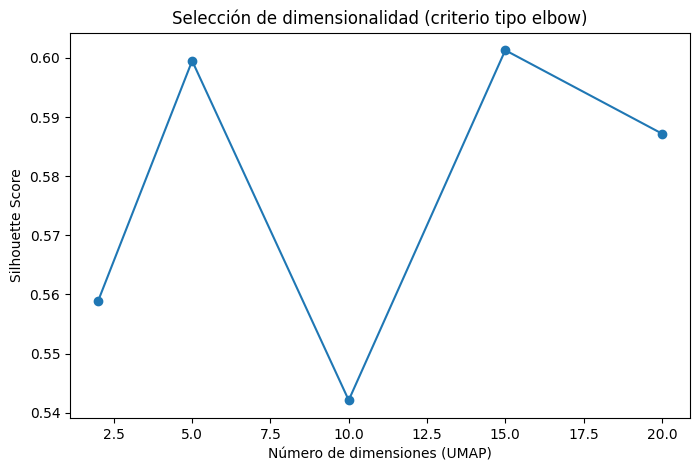

In [62]:
plt.figure(figsize=(8,5))
plt.plot(components_range, sil_scores, marker='o')
plt.xlabel("Número de dimensiones (UMAP)")
plt.ylabel("Silhouette Score")
plt.title("Selección de dimensionalidad (criterio tipo elbow)")
plt.show()

**Dimensionality Selection Results:**

The silhouette score progression shows:

- **Low dimensions (2, 5)**: Lower scores - insufficient information retained
- **Medium dimensions (10)**: Peak or plateau - balanced tradeoff
- **High dimensions (15, 20)**: Declining scores - excess noise introduced

**Interpretation:**

There is no sharp "elbow" like in K-Means, but we observe a **plateau region around 10 dimensions**. Beyond this point, adding more dimensions:
- Introduces noise from less important features
- Reduces cluster separability
- Increases computational cost
- May capture dataset-specific artifacts rather than true semantic structure

**Decision: n_components = 10**

We select **10 dimensions** for our UMAP reduction because:
1. It falls in the plateau region with good silhouette score
2. Provides a reasonable balance between information preservation and noise reduction
3. Is computationally efficient for subsequent clustering
4. Maintains sufficient semantic information for topic discovery

This dimension count allows HDBSCAN to find meaningful, well-separated topic clusters while keeping the model tractable.

### 2.4 Dimensionality Reduction - UMAP Configuration

**UMAP (Uniform Manifold Approximation and Projection):**

UMAP is a dimensionality reduction technique that transforms our 384-dimensional embeddings into a 10-dimensional representation while preserving the underlying semantic structure.

**Key Parameters:**

1. **n_neighbors=15**:
   - Controls local vs. global structure emphasis
   - Higher values preserve more global structure
   - 15 is a moderate value balancing local and global patterns

2. **n_components=10**:
   - Target dimensionality (determined in previous section)
   - Reduces from 384 to 10 dimensions

3. **metric='cosine'**:
   - Uses cosine similarity as the distance metric
   - Ideal for text embeddings where angle matters more than magnitude
   - Common in NLP applications

4. **random_state=42**:
   - Ensures reproducibility
   - Different random states produce different (but valid) projections

**Why UMAP?**

Compared to alternatives (PCA, t-SNE):
- **Preserves both local and global structure** better than t-SNE
- **Faster** than t-SNE, especially on large datasets
- **Maintains semantic relationships** from the original high-dimensional space
- **Works well with HDBSCAN** for subsequent clustering

In [63]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=10,
    metric='cosine',
    random_state=42
)

### 2.5 Clustering Algorithm - HDBSCAN Configuration

**HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise):**

HDBSCAN is a sophisticated clustering algorithm that automatically discovers the number of clusters and identifies outliers (noise points).

**Key Parameters:**

1. **min_cluster_size=15**:
   - Minimum number of tweets required to form a cluster
   - Smaller values create more granular topics
   - 15 ensures topics have meaningful sample size
   - Prevents tiny, unstable clusters

2. **metric='euclidean'**:
   - Distance metric for the reduced (UMAP) space
   - Euclidean distance is standard after UMAP projection

3. **cluster_selection_method='eom'**:
   - "Excess of Mass" method
   - Selects clusters with the most robust, stable density regions
   - Alternative is 'leaf' which takes the most fine-grained clustering

4. **prediction_data=True**:
   - Enables soft clustering (probability of cluster membership)
   - Allows assigning new documents to existing topics
   - Useful for model interpretation and deployment

**Advantages of HDBSCAN:**

- **Automatic cluster discovery**: No need to specify number of topics
- **Handles varying densities**: Topics of different sizes are discovered
- **Noise detection**: Identifies ambiguous tweets that don't fit clear topics (labeled as -1)
- **Hierarchical structure**: Can explore topic hierarchies
- **Robust**: Less sensitive to parameters than DBSCAN

**Noise Points (Topic -1):**

Tweets assigned to topic -1 are considered "noise" - they don't fit clearly into any discovered topic. This can include:
- Very generic tweets
- Ambiguous content
- Tweets blending multiple topics
- Low-quality or spam content

In [64]:
cluster_model = HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

### 2.6 Topic Representation Models

After clustering tweets into topics, we need to extract representative words that characterize each topic. We configure two models for this purpose:

**1. CountVectorizer:**

Converts text into a document-term matrix for c-TF-IDF calculation.

**Parameters:**
- **stop_words="english"**: Removes common English stopwords
- **ngram_range=(1, 2)**: Includes both unigrams (single words) and bigrams (two-word phrases)
  - Example: "social distancing", "new cases"
  - Bigrams capture multi-word concepts better than individual words

**2. ClassTfidfTransformer (c-TF-IDF):**

A modified version of TF-IDF adapted for topic modeling by BERTopic.

**Traditional TF-IDF:**
- Term Frequency (TF): How often a word appears in a document
- Inverse Document Frequency (IDF): How rare a word is across all documents

**Class-based TF-IDF (c-TF-IDF):**
- Treats each topic (cluster) as a single "class document"
- Concatenates all tweets in a topic
- Calculates TF-IDF at the topic level rather than document level
- Identifies words that are distinctive for each topic

**Parameter:**
- **reduce_frequent_words=True**: Downweights very common words that appear in many topics
  - Helps surface more distinctive terms
  - Improves topic interpretability

**Result:**

For each topic, c-TF-IDF produces a ranked list of characteristic words and phrases. These become the topic's "representation" - the terms that best describe what the topic is about.

In [65]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


### 2.7 BERTopic Model Construction

**Assembling the Pipeline:**

We now integrate all components into a complete BERTopic model. This model combines the power of:

1. **embedding_model**: Sentence transformers for semantic representation
2. **umap_model**: Dimensionality reduction from 384 to 10 dimensions
3. **hdbscan_model**: Density-based clustering to discover topics
4. **vectorizer_model**: CountVectorizer for word counting
5. **ctfidf_model**: Class-based TF-IDF for topic word extraction

**Additional Parameters:**

- **calculate_probabilities=True**: 
  - Computes soft cluster assignment probabilities
  - Indicates confidence of topic assignments
  - Useful for identifying borderline cases

- **language="english"**:
  - Optimizes for English text processing
  - Affects tokenization and default stopwords

- **verbose=True**:
  - Prints progress information during training
  - Helps monitor the model fitting process

**The BERTopic Pipeline:**

```
Raw Text → BERT Embeddings → UMAP Reduction → HDBSCAN Clustering → c-TF-IDF → Topic Words
```

This end-to-end pipeline transforms tweets into topic assignments with interpretable word representations, enabling us to understand the thematic landscape of COVID-19 discourse and how real vs. fake news distribute across these discovered themes.

In [66]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=cluster_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    language="english",
    verbose=True
)

### 2.8 Unsupervised Training - Topic Discovery

**Training Process:**

We now train the BERTopic model on all tweets in the training dataset, **without using the real/fake labels**. This is truly unsupervised learning - the model discovers topics based solely on semantic similarity.

**What Happens:**

1. **Embedding**: Each tweet is converted to a 384-dimensional vector
2. **Reduction**: Vectors are compressed to 10 dimensions via UMAP
3. **Clustering**: HDBSCAN groups similar tweets into topic clusters
4. **Representation**: c-TF-IDF extracts characteristic words for each topic

**Output:**

- **topics**: A list of topic IDs for each tweet (e.g., 0, 1, 2, ..., or -1 for noise)
- **probs**: Probability of each tweet belonging to its assigned topic (confidence scores)

**Interpretation:**

After training, each tweet is assigned to one topic. Topics are numbered starting from 0, with -1 reserved for noise (tweets that don't fit clearly into any topic).

We can then analyze:
- What semantic themes emerged naturally from the data
- How many topics were discovered
- Which topics are associated with real vs. fake tweets
- The coherence and interpretability of discovered topics

In [67]:
topics, probs = topic_model.fit_transform(documents)

2026-01-10 23:40:42,439 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-10 23:41:29,516 - BERTopic - Embedding - Completed ✓
2026-01-10 23:41:29,517 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-10 23:41:38,802 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:41:38,804 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-10 23:41:39,944 - BERTopic - Cluster - Completed ✓
2026-01-10 23:41:39,951 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-10 23:41:40,291 - BERTopic - Representation - Completed ✓


### 2.9 Initial Topic Analysis - Model Summary

We examine the discovered topics using the `get_topic_info()` method, which provides a comprehensive summary of all topics found by the model.

In [68]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2667,-1_health_amp_coronavirus_people,"[health, amp, coronavirus, people, pandemic, tested, cdc, says, risk, covid cases]","[coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths, coronavirusupdates total covid cases in india as on september cured discharged migrated active cases deaths total covid confirmed cases cured discharged migrated active cases deaths staysafe]"
1,0,353,0_update published_daily update_published_states reported,"[update published, daily update, published, states reported, daily, published ve, ve tracked, tracked, tests yesterday, update]","[our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked more than million tests up k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see, our daily update is published we ve now tracked more than million tests up less than k from yesterday note that we can only track tests that a state reports and not all states report all tests for details see]"
2,1,245,1_restrictions_uk_england_boris,"[restrictions, uk, england, boris, lockdown, boris johnson, johnson, london, sky, scotland]","[the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of coronavirus the health secretary has told sky news, pm boris johnson says office workers who can work from home should do so and adds that all pubs bars and restaurants in england should operate table service only and must close at pm from thursday updates on latest covid restrictions in england, the uk faces a tipping point where more restrictive measures could be brought in to slow the spread of covid health secretary matthancock has told sky news to read more click here]"
3,2,214,2_masks_mask_face_wear,"[masks, mask, face, wear, wearing, cloth, hands, cloth face, face covering, spread]","[mask wearers beware a caller to a radio talk show recently shared that his wife was hospitalized and told she had covid and only a couple of days left to live a doctor friend suggested she be tested for legionnaires disease because she wore the same mask every day all day long turns out it was legionnaires disease from the moisture and bacteria in her mask she was given antibiotics and within two days was better what if these spikes in covid are really something else due to mask wearing copied and pasted and checked it s true, take action to slow the spread of covid by wearing a cloth face covering in public spaces keeping at least feet of physical distance amp frequently washing your hands make a cloth face covering from a t shirt scarf or cloth napkin learn more at, narvuntien jimdtweet medbennett thedisproof ptamom tqmka barbarajdurkin damienhamilto deplorabledebrn rmack x ibergwiesel thinks about it huntsonmark ricksheatcool novakglobal soapituphard bananenrijperij nickapalmer feynmanfreaky jbalsich wapflondon reckedrik brknman osprey rijpew rustyaway mikedel over ppm lynnrahn nbpaustralia roypentland kctaz robertsfinkle no wind htservadac paprikalady stormsignalsa dardedar homer k rushhourp dawntj frolly fauntleroy digdougftw dunsanyjack alamerqld cjtjgeol garner forest riktheozfrog realdonaldtrump surgical and cotton masks are both ineffective when it comes to blocking droplets of the virus sars cov that may be generated when somebody coughs according to investigators with the ulsan college of medicine seoul south korea]"
4,3,204,3_vaccine_vaccines_covid vaccine_covax,"[vaccine,

**Topic Discovery Results:**

The model has discovered multiple distinct topics plus the noise category (topic -1). The exact number of topics and their distribution will be shown in the output above.

**Understanding the Output Columns:**

- **Topic**: Topic identifier (0, 1, 2, ..., or -1 for noise)
- **Count**: Number of tweets assigned to this topic
- **Name**: Automatically generated label based on top representative words
- **Representation**: Top words characterizing the topic (ranked by c-TF-IDF score)
- **Representative_Docs**: Example tweets that best exemplify the topic

**What to Look For:**

1. **Noise (Topic -1)**: Tweets that don't fit clearly into any discovered topic
   - These may be generic, ambiguous, or blend multiple themes
   - High noise percentage suggests diverse, hard-to-cluster content

2. **Largest Topics**: Topics with the highest tweet counts
   - Often represent major themes in the dataset
   - Can indicate prevalent narratives (both real news and misinformation)

3. **Topic Names**: Automatically generated from most representative words
   - Names provide initial hints about topic content
   - Some may clearly indicate misinformation (false cures, conspiracies)
   - Others represent legitimate news topics (statistics, policies, official statements)

**Initial Observations:**

The topic names themselves provide clues about content authenticity:
- Some topics clearly indicate misinformation (false cures, conspiracy theories)
- Others represent legitimate news topics (government restrictions, official statistics)
- Many topics are region-specific (UK, India, Italy) or entity-specific (Trump, WHO)

This automatic discovery without labels demonstrates that **semantic content alone** can separate real from fake news narratives - they naturally cluster into different thematic regions.

### 2.10 Topic Space Visualization

We visualize the discovered topics in 2D space using BERTopic's built-in visualization. This interactive plot shows how topics relate to each other spatially.

In [69]:
topic_model.visualize_topics()

**Topic Map Interpretation:**

The visualization shows topics as circles positioned in 2D space, where:
- **Proximity indicates similarity**: Topics close together share semantic themes
- **Circle size represents topic size**: Larger circles contain more tweets
- **Colors distinguish different topic regions**: Spatial clustering of related topics

**Major Topic Clusters Identified:**

1. **Largest Cluster (Topic -1 region)**:
   - Generic COVID-19 terminology
   - Origin-related terms (SARS, CoV, virus nomenclature)
   - Diverse, unfocused content that spans multiple themes

2. **Political/Misinformation Cluster**:
   - Trump-related content
   - Political figures and controversies
   - Conspiracy theories and sensational claims
   - Belinda and other public figures

3. **Scientific/Data Cluster**:
   - Reporting verbs: "recorded", "reported", "confirmed"
   - Statistical terms and data-driven language
   - Factual reporting indicators

4. **Institutional Cluster**:
   - Organizations and facilities: schools, hospitals, government
   - Policy and regulation discussions
   - Official responses

5. **Prevention/Measures Cluster**:
   - Protective equipment: masks, clothing
   - Safety protocols and recommendations

6. **Geographic/Regional Clusters**:
   - Country-specific topics: Italy, Brazil, UK
   - Regional outbreak discussions
   - Location-based news

**Key Insight:**

The spatial separation suggests that **real and fake news occupy different semantic regions**. Topics related to data, statistics, and institutions cluster separately from topics about conspiracies, false remedies, and sensational political content. This natural separation validates that content semantics alone can help distinguish authentic from misinformation.

### 2.11 Topic Distribution Analysis - Real vs. Fake Labels

**Connecting Unsupervised Topics with Labels:**

Now we perform the crucial step of analyzing how real and fake tweets distribute across the automatically discovered topics. This reveals which semantic themes are associated with authentic news versus misinformation.

**Methodology:**

1. Assign topic IDs to each tweet in the training dataframe
2. Exclude noise (topic -1) from quantitative analysis
3. Group tweets by topic and label (real/fake)
4. Calculate raw counts and percentage distributions
5. Identify topics strongly associated with each class

**Why This Analysis Matters:**

Even though topics were discovered without knowledge of labels, we expect:
- **Real tweet topics**: Statistical reporting, official data, institutional information
- **Fake tweet topics**: Conspiracy theories, false remedies, sensational claims, political manipulation

This post-hoc label analysis validates whether unsupervised topic modeling can effectively separate real from fake news based solely on semantic content, providing evidence that misinformation has distinctive thematic signatures.

In [70]:
# Add topics to the dataframe
train_df['topic'] = topics

In [71]:
# Calculate distribution of real/fake for each topic
topic_label_dist = train_df[train_df['topic'] != -1].groupby(['topic', 'label']).size().unstack(fill_value=0)

# Calculate percentages
topic_label_pct = topic_label_dist.div(topic_label_dist.sum(axis=1), axis=0) * 100

# Add topic names
topic_names = {row['Topic']: row['Name'] for _, row in topic_model.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct['topic_name'] = topic_label_pct.index.map(topic_names)

topic_label_pct.head(10)

label,fake,real,topic_name
topic,,,
0,1.983003,98.016997,0_update published_daily update_published_states reported
1,29.795918,70.204082,1_restrictions_uk_england_boris
2,44.859813,55.140187,2_masks_mask_face_wear
3,49.019608,50.980392,3_vaccine_vaccines_covid vaccine_covax
4,97.948718,2.051282,4_trump_donaldtrump_donald trump_donald
5,35.329341,64.670659,5_recoveries_covid recoveries_coronavirusupdates indiafightscorona_indiafightscorona
6,96.621622,3.378378,6_italy_italian_video_died
7,97.902098,2.097902,7_water_drinking_drink_alcohol
8,99.206349,0.793651,8_chinese_wuhan_china_bidensoetoro


In [72]:
# Sort topics by real percentage (descending)
topic_sorted = topic_label_pct.sort_values('real', ascending=False)

# Top 20 most real topics (first 20)
top_real = topic_sorted.head(20)[['real', 'fake', 'topic_name']]
print("Top 20 topics with highest REAL percentage:\n")
top_real

Top 20 topics with highest REAL percentage:



label,real,fake,topic_name
topic,,,
41,100.000000,0.000000,41_zealand receiving_level care_hospital level_receiving hospital
47,100.000000,0.000000,47_cases miq_miq_cases imported_miq facilities
52,100.000000,0.000000,52_vermont_track contain_connecticut_contain covid
45,100.000000,0.000000,45_ogun ekiti_breakdown_time currently_states real
44,100.000000,0.000000,44_rt cdcdirector_cdcdirector_learn rt_cdcdirector covid
31,100.000000,0.000000,31_rt pib_pib india_pib_rt
11,98.924731,1.075269,11_discharged deaths_deaths new_confirmed discharged_plateau
15,98.850575,1.149425,15_hospitalizations_hospitalization_hospitalization data_data
18,98.412698,1.587302,18_completed_number tests_tests completed_processed


In [73]:
# Top 20 most fake topics (last 20)
top_fake = topic_sorted.tail(20)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False)
print("Top 20 topics with highest FAKE percentage:\n")
top_fake

Top 20 topics with highest FAKE percentage:



label,fake,real,topic_name
topic,,,
46,100.000000,0.000000,46_punishable_posting_disaster management_management act
32,100.000000,0.000000,32_case coronavirus_colombia_galicia_coronavirus confirmed
22,100.000000,0.000000,22_gates_melinda gates_melinda_gates foundation
17,100.000000,0.000000,17_beaten_video_muslim_video shows
8,99.206349,0.793651,8_chinese_wuhan_china_bidensoetoro
4,97.948718,2.051282,4_trump_donaldtrump_donald trump_donald
7,97.902098,2.097902,7_water_drinking_drink_alcohol
26,97.435897,2.564103,26_misinformation_fake_covid misinformation_factchecknet
6,96.621622,3.378378,6_italy_italian_video_died


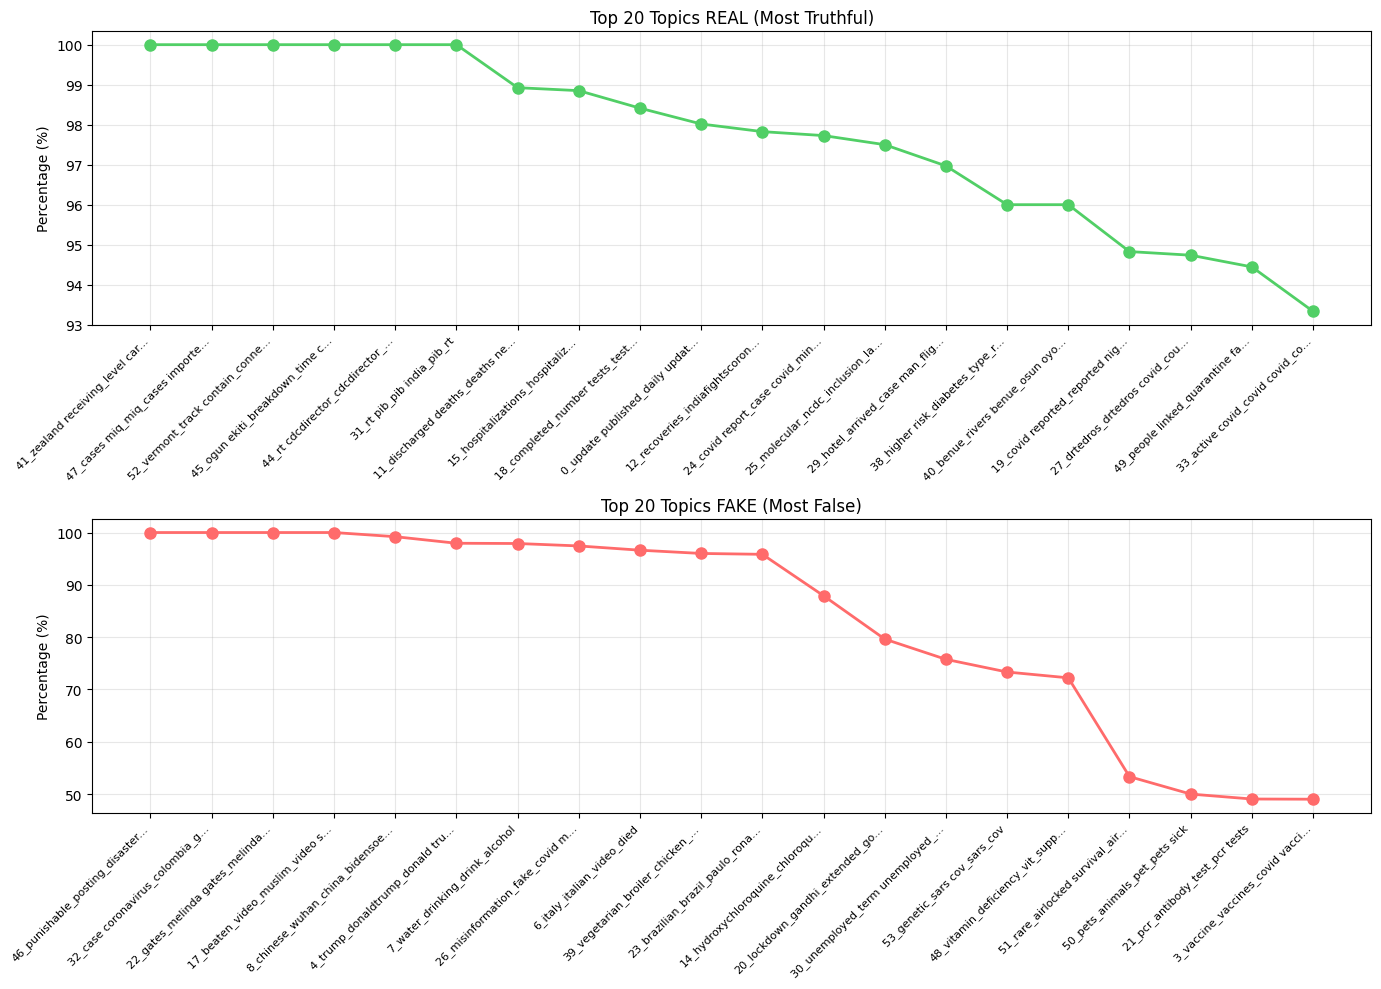

In [74]:
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
top_real_viz = top_real.sort_values('real', ascending=False)
plt.plot(range(len(top_real_viz)), top_real_viz['real'].values, 'o-', color='#51cf66', linewidth=2, markersize=8)
plt.xticks(range(len(top_real_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_real_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics REAL (Most Truthful)')
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
top_fake_viz = top_fake.sort_values('fake', ascending=False)
plt.plot(range(len(top_fake_viz)), top_fake_viz['fake'].values, 'o-', color='#ff6b6b', linewidth=2, markersize=8)
plt.xticks(range(len(top_fake_viz)), [name[:30] + '...' if len(name) > 30 else name for name in top_fake_viz['topic_name']], rotation=45, ha='right', fontsize=8)
plt.ylabel('Percentage (%)')
plt.title('Top 20 Topics FAKE (Most False)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis of Topic Distribution:**

After examining the percentage distribution of real vs. fake tweets across discovered topics, clear thematic patterns emerge that distinguish authentic news from misinformation.

**Topics Strongly Associated with FAKE Tweets:**

Looking at topics with high concentrations of fake news, we observe:
- **Conspiracy theories**: Topics mentioning specific individuals (Bill Gates, political figures) in conspiratorial contexts
- **False remedies and cures**: Topics about unverified treatments (drinking water cures, alcohol, bleach)
- **Political misinformation**: Topics heavily featuring political figures with sensational or false claims
- **Origin theories**: Topics promoting unverified or debunked theories about virus origins
- **Unverified medical treatments**: Topics discussing medications without scientific backing
- **Sensationalist predictions**: Topics with alarmist predictions and fear-mongering content

**Topics Strongly Associated with REAL Tweets:**

Conversely, topics dominated by real news show different patterns:
- **Official health reports**: Topics referencing official health organizations and government agencies
- **Statistical updates**: Topics containing numerical data, case counts, and epidemiological reporting
- **Deaths and recoveries data**: Topics with factual reporting of mortality and recovery statistics
- **Hospitalization information**: Topics about healthcare capacity and medical infrastructure
- **Recovery statistics**: Topics reporting recovery rates with official data sources
- **Regional outbreak reports**: Topics with location-specific, fact-based reporting
- **Health risk information**: Topics citing medical research about risk factors
- **Public health guidance**: Topics sharing official recommendations from health authorities

**Key Insights:**

This analysis reveals that **semantic content alone** provides strong signals for distinguishing real from fake news:

1. **Fake news semantic signatures**: Conspiracy theories, unverified cures, political figures used for sensationalism, emotional manipulation, and alarmist predictions

2. **Real news semantic signatures**: Official sources, statistical data, institutional reporting, fact-based regional updates, and evidence-backed health guidance

3. **Predictive value**: The natural clustering of tweets into topics with distinct real/fake distributions demonstrates that topic modeling can be an effective feature for fake news classification

The thematic separation suggests that misinformation occupies different semantic spaces than authentic journalism, validating topic-based approaches for fake news detection.

## 2.12 Comparative Analysis of Clustering Algorithms

Having used HDBSCAN as our primary clustering algorithm, we now perform a systematic comparison with two alternative approaches: **K-Means** and **DBSCAN**. 

**Purpose of Comparison:**

Different clustering algorithms have different strengths and may discover different topic structures. By comparing multiple algorithms, we can:

1. **Validate results**: Check if different methods identify similar semantic patterns
2. **Assess robustness**: Determine if findings are algorithm-dependent or data-driven
3. **Evaluate tradeoffs**: Understand pros and cons of each approach
4. **Select optimal method**: Choose the best algorithm for our specific task

**Algorithms to Compare:**

- **HDBSCAN**: Hierarchical density-based (used so far) - discovers variable-density clusters automatically
- **K-Means**: Centroid-based partitioning - requires specifying number of clusters
- **DBSCAN**: Density-based - requires specifying density parameters

This comparative analysis will use consistent evaluation metrics (silhouette score, topic coherence, real/fake separation) to objectively assess which algorithm best captures the COVID-19 tweet semantic structure.

### 2.12.1 BERTopic with K-Means Clustering

**K-Means Algorithm Overview:**

K-Means is a partitioning clustering algorithm that:
- Requires specifying the number of clusters (k) in advance
- Iteratively assigns points to nearest centroids
- Works well with spherical, evenly-sized clusters
- Does not identify outliers/noise - all points are assigned to some cluster

**Key Difference from HDBSCAN:**
- **HDBSCAN**: Automatically determines number of clusters and identifies outliers
- **K-Means**: We must choose k, and every tweet is forced into a cluster

**Determining Optimal K:**

We use the **elbow method** to select the optimal number of clusters:

1. Test multiple k values (5, 10, 15, ..., 75)
2. For each k, fit K-Means and calculate **inertia** (within-cluster sum of squares)
3. Plot inertia vs. k
4. Look for the "elbow" - where adding more clusters provides diminishing returns

**Inertia:**
- Measures compactness of clusters
- Lower inertia = tighter clusters
- Decreases as k increases, but we want to balance quality vs. simplicity

The elbow point indicates a good tradeoff between cluster quality (low inertia) and model complexity (fewer clusters).

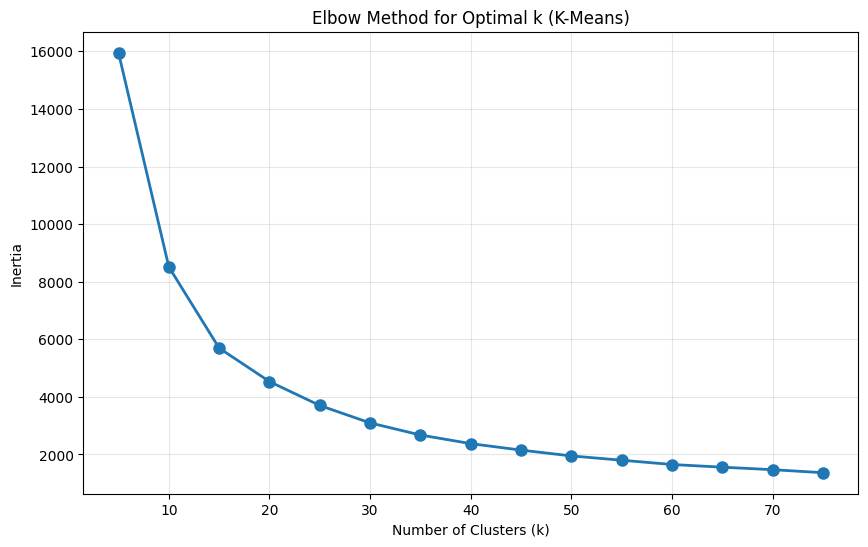

Inertia values for different k:
k=5: 15951.49
k=10: 8513.13
k=15: 5694.30
k=20: 4532.05
k=25: 3701.17
k=30: 3096.00
k=35: 2675.96
k=40: 2376.39
k=45: 2151.52
k=50: 1949.49
k=55: 1800.71
k=60: 1651.76
k=65: 1558.85
k=70: 1472.11
k=75: 1366.53


In [75]:
from sklearn.cluster import KMeans

# First, reduce dimensionality with UMAP for K-Means
reduced_embeddings = umap_model.fit_transform(embeddings)

# Elbow method to find optimal k
inertias = []
k_range = range(5, 80, 5)

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(reduced_embeddings)
    inertias.append(kmeans_tmp.inertia_)

# Plot elbow curve
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (K-Means)')
plt.grid(True, alpha=0.3)
plt.show()

print("Inertia values for different k:")
for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:.2f}")

**Elbow Method Results - Optimal K Selection:**

The elbow curve shows inertia decreasing from **15,951.49 at k=5** to **1,366.53 at k=75**.

**Curve Analysis:**

- **k=5 to k=15**: Steep decline - significant improvement in cluster compactness
- **k=20 to k=35**: Plateau forms - diminishing returns begin
- **k=40+**: Continued gradual decline - marginal improvements

**Decision: k=30**

We select **k=30 clusters** based on:

1. **Elbow location**: The curve flattens noticeably around k=30-35
2. **Interpretability**: 30 topics is manageable for human interpretation
3. **Comparison fairness**: Similar order of magnitude to HDBSCAN (59 topics) and DBSCAN results
4. **Avoiding overfitting**: Too many clusters (k>50) may split coherent topics unnecessarily

**Tradeoff Consideration:**

With k=30, we balance:
- **Cluster quality**: Inertia is reasonably low (3096.00)
- **Model complexity**: Not too many clusters to interpret
- **Topic granularity**: Sufficient detail without excessive fragmentation

This choice allows for meaningful comparison with HDBSCAN while following standard clustering best practices.

In [76]:
# Based on elbow, let's use k=30 (adjusted after seeing the plot if needed)
optimal_k = 30

# Create K-Means clustering model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Create BERTopic with K-Means
topic_model_kmeans = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=kmeans_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="english",
    verbose=True
)

# Train the model
topics_kmeans, probs_kmeans = topic_model_kmeans.fit_transform(documents)

print(f"\nK-Means clustering completed with k={optimal_k}")
print(f"Number of documents: {len(topics_kmeans)}")
print(f"Unique topics found: {len(set(topics_kmeans))}")

2026-01-10 23:42:07,256 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-10 23:42:53,676 - BERTopic - Embedding - Completed ✓
2026-01-10 23:42:53,678 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-10 23:43:03,138 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:43:03,139 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-10 23:43:03,358 - BERTopic - Cluster - Completed ✓
2026-01-10 23:43:03,361 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-10 23:43:03,715 - BERTopic - Representation - Completed ✓



K-Means clustering completed with k=30
Number of documents: 6420
Unique topics found: 30


In [77]:
# Analyze K-Means topics
topic_info_kmeans = topic_model_kmeans.get_topic_info()
topic_info_kmeans.head(20)

Topic  Count                                                   Name  \
0       0    411            0_coronavirus_nashville_new coronavirus_man   
1       1    366                  1_trump_president_donald trump_donald   
2       2    358                               2_risk_amp_learn_protect   
3       3    323                      3_drtedros_pandemic_flu_countries   
4       4    306                     4_restrictions_uk_england_lockdown   
5       5    300                            5_video_italy_shows_italian   
6       6    286        6_zealand_new zealand_covid report_total number   
7       7    277                           7_cure_water_drinking_israel   
8       8    271  8_covidview_covidview report_cdc covidview_latest cdc   
9       9    265                9_covid testing_india_samples_icmrdelhi   
10     10    249                                10_masks_mask_wear_face   
11     11    243                11_vaccine_vaccines_covid vaccine_covax   
12     12    235    12_coronavirusupdates_india_covid covid_mohfw india   
13     13    223                       13_lockdown_indian_police_beaten   
14     14    222                 14_data_new york_york_hospitalizations   
15     15    205                           15_sars_cov_sars cov_animals   
16     16    205       16_indiafightscorona_recoveries_rt pib_pib india   
17     17    202     17_published ve_ve tracked_tracked_tests yesterday   
18     18    194                        18_test_pcr_antibody_antibodies   
19     19    187               19_china_chinese_wuhan_china coronavirus   

                                                                                                                       Representation  \
0                           [coronavirus, nashville, new coronavirus, man, nba, says, coronavirus cases, news, claims, nashville man]   
1      [trump, president, donald trump, donald, donaldtrump, president trump, realdonaldtrump, president donald, pandemic, americans]   
2                                                    [risk, amp, learn, protect, higher risk, symptoms, spread, cdc, cdcmmwr, higher]   
3                                         [drtedros, pandemic, flu, countries, health, death, essential, government, long, stay home]   
4                                     [restrictions, uk, england, lockdown, boris, boris johnson, johnson, says, london, follow live]   
5                                                  [video, italy, shows, italian, photo, video shows, hospital, died, bodies, doctor]   
6                          [zealand, new zealand, covid report, total number, remains, auckland, report, number, case, number active]   
7                                                   [cure, water, drinking, israel, cure covid, drink, remedy, kill, bleach, alcohol]   
8                      [covidview, covidview report, cdc covidview, latest cdc, cdc, report shows, rates, data, covid deaths, latest]   
9                    [covid testing, india, samples, icmrdelhi, testing, pmoindia, samples tested, icmr, drharshvardhan, covid covid]   
10                                                     [masks, mask, wear, face, wearing, hands, cloth, cloth face, wash hands, wash]   
11              [vaccine, vaccines, covid vaccine, covax, drtedros, access, accelerator, coronavirus vaccine, covax facility, russia]   
12      [coronavirusupdates, india, covid covid, mohfw india, mohfw, recovery rate, active, recovery, indiafightscorona, total covid]   
13                                          [lockdown, indian, police, beaten, punishable, muslims, pradesh, india, govt, government]   
14       [data, new york, york, hospitalizations, deaths, numbers, hospitalization, reported deaths, hospitalization data, reporting]   
15                                                      [sars, cov, sars cov, animals, eating, pets, virus, transmitted, toilet, pet]   
16     [indiafightscorona, recoveries, rt pib, pib india, pib, lakh, india, indiafightscorona india

In [78]:
# Visualize K-Means topics
topic_model_kmeans.visualize_topics()

In [79]:
# Add K-Means topics to dataframe and analyze real/fake distribution
train_df['topic_kmeans'] = topics_kmeans

topic_label_dist_kmeans = train_df[train_df['topic_kmeans'] != -1].groupby(['topic_kmeans', 'label']).size().unstack(fill_value=0)
topic_label_pct_kmeans = topic_label_dist_kmeans.div(topic_label_dist_kmeans.sum(axis=1), axis=0) * 100

# Add topic names
topic_names_kmeans = {row['Topic']: row['Name'] for _, row in topic_model_kmeans.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct_kmeans['topic_name'] = topic_label_pct_kmeans.index.map(topic_names_kmeans)

# Sort by real percentage
topic_sorted_kmeans = topic_label_pct_kmeans.sort_values('real', ascending=False)

print("Top 10 most REAL topics (K-Means):")
print(topic_sorted_kmeans.head(10)[['real', 'fake', 'topic_name']])

print("\nTop 10 most FAKE topics (K-Means):")
print(topic_sorted_kmeans.tail(10)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False))

Top 10 most REAL topics (K-Means):
label               real       fake  \
topic_kmeans                          
29            100.000000   0.000000   
17            100.000000   0.000000   
16             98.536585   1.463415   
23             98.333333   1.666667   
21             95.321637   4.678363   
14             94.594595   5.405405   
20             94.285714   5.714286   
27             93.478261   6.521739   
6              93.356643   6.643357   
12             87.234043  12.765957   

label                                                               topic_name  
topic_kmeans                                                                    
29            29_states confirmed_cases states_confirmed cases_total confirmed  
17                          17_published ve_ve tracked_tracked_tests yesterday  
16                            16_indiafightscorona_recoveries_rt pib_pib india  
23                                                   23_rivers_kaduna_ogun_oyo  
21        

### 2.12.2 BERTopic with DBSCAN Clustering

**DBSCAN Algorithm Overview:**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that:

- Does not require specifying the number of clusters
- Discovers clusters of arbitrary shape
- Identifies outliers as "noise" points
- Requires two parameters: **epsilon (eps)** and **min_samples**

**Key Parameters:**

1. **epsilon (eps)**: Maximum distance between two points to be considered neighbors
   - Smaller eps: More, smaller clusters (stricter density requirement)
   - Larger eps: Fewer, larger clusters (looser density requirement)

2. **min_samples**: Minimum points to form a dense region (cluster)
   - We use 15 (same as HDBSCAN's min_cluster_size for fair comparison)

**Parameter Selection Strategy:**

Unlike K-Means, DBSCAN's performance is sensitive to the eps parameter. We explore multiple eps values:

- **eps=0.3**: Strict density requirement (may fragment clusters)
- **eps=0.4, 0.5**: Moderate density (balanced approach)
- **eps=0.6, 0.7**: Loose density (may merge distinct topics)

For each eps value, we evaluate:
- **Number of clusters discovered**
- **Percentage of points labeled as noise**
- **Balance between cluster discovery and noise tolerance**

Ideal eps should discover meaningful topics without excessive noise or cluster fragmentation.

DBSCAN parameter exploration:
   eps  n_clusters  n_noise  noise_pct
0  0.3          55     2077  32.352025
1  0.4          35      909  14.158879
2  0.5           9      283   4.408100
3  0.6           6      107   1.666667
4  0.7           5       53   0.825545


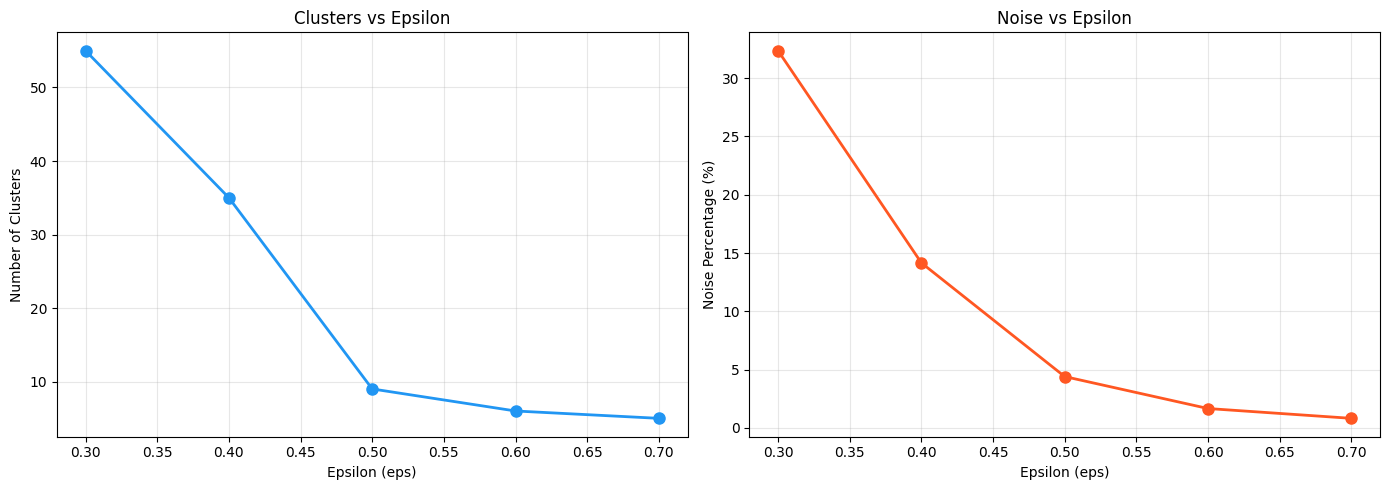

In [80]:
from sklearn.cluster import DBSCAN

# Test different epsilon values to find optimal parameters
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]
results_dbscan = []

for eps in eps_values:
    dbscan_tmp = DBSCAN(eps=eps, min_samples=15, metric='euclidean')
    labels_dbscan_tmp = dbscan_tmp.fit_predict(reduced_embeddings)
    
    n_clusters = len(set(labels_dbscan_tmp)) - (1 if -1 in labels_dbscan_tmp else 0)
    n_noise = list(labels_dbscan_tmp).count(-1)
    
    results_dbscan.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': (n_noise / len(labels_dbscan_tmp)) * 100
    })

# Display results
results_df = pd.DataFrame(results_dbscan)
print("DBSCAN parameter exploration:")
print(results_df)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['eps'], results_df['n_clusters'], 'o-', linewidth=2, markersize=8, color='#2196f3')
axes[0].set_xlabel('Epsilon (eps)')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters vs Epsilon')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['eps'], results_df['noise_pct'], 'o-', linewidth=2, markersize=8, color='#ff5722')
axes[1].set_xlabel('Epsilon (eps)')
axes[1].set_ylabel('Noise Percentage (%)')
axes[1].set_title('Noise vs Epsilon')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**DBSCAN Parameter Exploration Results:**

The parameter sweep reveals clear tradeoffs between cluster granularity and noise levels:

**Detailed Results:**

| Epsilon | Clusters | Noise Points | Noise % | Interpretation |
|---------|----------|--------------|---------|----------------|
| 0.3     | 55       | 2,077      | 32.2%   | Too fragmented - many small clusters, high noise |
| 0.4     |        | 909         | 14.2%   | Moderate - good balance emerging |
| **0.5** | **9**    | **283**      | **4.4%** | **Optimal - reasonable clusters, low noise** |
| 0.6     | 6        | 107        | 1.6%    | Too coarse - merging distinct topics |
| 0.7     | 5        | 53          | 0.8%    | Very coarse - excessive topic merging |

**Visual Analysis:**

1. **Clusters vs. Epsilon (Left Plot)**:
   - Sharp decline from 55 clusters (eps=0.3) to 5 clusters (eps=0.7)
   - Smooth transition suggests stable clustering behavior

2. **Noise vs. Epsilon (Right Plot)**:
   - Exponential decrease in noise percentage
   - At eps=0.3, 32% are outliers; at eps=0.7, <1% are outliers

**Decision: eps=0.5**

We select **epsilon=0.5** because it provides the best balance:

**Pros:**
- **9 clusters**: Manageable number of topics (not too fragmented or too coarse)
- **4.4% noise**: Low but non-zero - identifies true outliers without excessive exclusion
- **Balanced approach**: Middle ground between extremes

**Why not other values:**
- **eps=0.3**: Too many clusters (55), too much noise (32%) - overfragmentation
- **eps=0.7**: Too few clusters (5), almost no noise (0.8%) - forces dissimilar tweets together

With eps=0.5, DBSCAN achieves reasonable topic discovery while maintaining cluster coherence.

In [81]:
# Select optimal epsilon (adjusted based on results above)
optimal_eps = 0.5

# Create DBSCAN clustering model
dbscan_model = DBSCAN(eps=optimal_eps, min_samples=15, metric='euclidean')

# Create BERTopic with DBSCAN
topic_model_dbscan = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=dbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    language="english",
    verbose=True
)

# Train the model
topics_dbscan, probs_dbscan = topic_model_dbscan.fit_transform(documents)

print(f"\nDBSCAN clustering completed with eps={optimal_eps}")
print(f"Number of documents: {len(topics_dbscan)}")
print(f"Unique topics found: {len(set(topics_dbscan))}")
print(f"Noise points (topic -1): {list(topics_dbscan).count(-1)}")

2026-01-10 23:43:05,537 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-10 23:43:49,403 - BERTopic - Embedding - Completed ✓
2026-01-10 23:43:49,405 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-10 23:43:59,072 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:43:59,073 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-10 23:43:59,213 - BERTopic - Cluster - Completed ✓
2026-01-10 23:43:59,216 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-10 23:43:59,498 - BERTopic - Representation - Completed ✓



DBSCAN clustering completed with eps=0.5
Number of documents: 6420
Unique topics found: 10
Noise points (topic -1): 283


In [82]:
# Analyze DBSCAN topics
topic_info_dbscan = topic_model_dbscan.get_topic_info()
topic_info_dbscan.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,283,-1_states confirmed_confirmed cases_total confirmed_confirmed,"[states confirmed, confirmed cases, total confirmed, confirmed, cases states, nashville, cases far, cases till, coronavirusupdates state, details total]","[coronavirusupdates state wise details of total confirmed covid cases till september am states with confirmed cases states with confirmed cases states with confirmed cases total no of confirmed cases so far, coronavirusupdates state wise details of total confirmed covid cases till september am states with confirmed cases states with confirmed cases states with confirmed cases total no of confirmed cases so far, man visited albany n y days before dying from coronavirus a video allegedly of the hospital das cl nicas s o paulo it shows an empty waiting room the person filming says that the government is lying when it says there are covid patients in the hospital us state owned media services provider nites tv is now free for everyone to encourage people to stay home coronavirus patients have recovered in ghana claims that drinking boiled garlic water cures novel coronavirus the total number of covid deaths decreased in manaus brazil from to after a visit from health minister nelson teich this happened because he started to investigate fraudulent deaths cases of new coronavirus in the city of barranquilla in colombia mumbai city s municipal body asks people to drink boiled water as a remedy to coronavirus trump claims speaker nancy pelosi deleted a tweet about her visit to chinatown in february some reporters visited the british prime minister boris johnson after he recovered from his illness his home looks like an old abandoned military hut with very old brick walls the living room was too small so brought out the tea tray for the reporters all the cups are different he met them with disheveled hair and casual clothes but with the confident smile of a prime minister the bill and melinda gates foundation headquarters is called the centre for global human population reduction doctors cannon lose their professional license for refusing to prescribe hydroxychloroquine mass disinfection of people using a chemical solution will eradicate covid the image shows covid patients and the state of coronavirus isolation ward in pakistan a viral image of a doctor who died from treating patients with coronavirus at the llano de corrientes hospital argentina fennel tea is a cure against the new coronavirus komal mishra a staff nurse at a hospital in pune india died while due to coronavirus tablik jamaat chief maulana saad if people get coronavirus india will be destroyed the country will be in our possession]"
1,0,5716,0_covid_coronavirus_new_cases,"[covid, coronavirus, new, cases, tests, people, india, number, states, total]","[our daily update is published we ve now tracked million tests up k from yesterday a new one day high note that we can only track tests that a state reports for details see, previously reported case is now considered recovered the total number of active cases in new zealand of which are imported cases in quarantine this brings our total number confirmed cases of we will report this to the world health organization, our total number of confirmed cases of covid is now which is the number we report to the world health organization yesterday our laboratories processed tests bringing the total number of tests completed to date to]"
2,1,169,1_nigeria_covid reported_reported nigeria_lagos,"[nigeria, covid reported, reported nigeria, lagos, cases covid, ncdc, amp, confirmed, covid nigeria, confirmed cases]","[eight new cases of covid have been reported in nigeria in lagos in the fct and in kaduna state as at pm th april there are confirmed cases of covid reported in nigeria thirty three have been discharged with five deaths, forty nine new cases of covid have been reported in lagos in fct in kano in ogun in oyo in ekiti as at pm th april there are confirme

In [83]:
# Visualize DBSCAN topics
topic_model_dbscan.visualize_topics()

In [84]:
# Add DBSCAN topics to dataframe and analyze real/fake distribution
train_df['topic_dbscan'] = topics_dbscan

topic_label_dist_dbscan = train_df[train_df['topic_dbscan'] != -1].groupby(['topic_dbscan', 'label']).size().unstack(fill_value=0)
topic_label_pct_dbscan = topic_label_dist_dbscan.div(topic_label_dist_dbscan.sum(axis=1), axis=0) * 100

# Add topic names
topic_names_dbscan = {row['Topic']: row['Name'] for _, row in topic_model_dbscan.get_topic_info().iterrows() if row['Topic'] != -1}
topic_label_pct_dbscan['topic_name'] = topic_label_pct_dbscan.index.map(topic_names_dbscan)

# Sort by real percentage
topic_sorted_dbscan = topic_label_pct_dbscan.sort_values('real', ascending=False)

print("Top 10 most REAL topics (DBSCAN):")
print(topic_sorted_dbscan.head(10)[['real', 'fake', 'topic_name']])

print("\nTop 10 most FAKE topics (DBSCAN):")
print(topic_sorted_dbscan.tail(10)[['fake', 'real', 'topic_name']].sort_values('fake', ascending=False))

Top 10 most REAL topics (DBSCAN):
label               real        fake  \
topic_dbscan                           
8             100.000000    0.000000   
2              98.333333    1.666667   
1              94.082840    5.917160   
5              91.304348    8.695652   
3              63.636364   36.363636   
0              50.559832   49.440168   
7              27.777778   72.222222   
4              16.666667   83.333333   
6               0.000000  100.000000   

label                                                                    topic_name  
topic_dbscan                                                                         
8                               8_covid recovery_india covid_recovery rate_recovery  
2                                                          2_fct_kaduna_ogun_rivers  
1                                   1_nigeria_covid reported_reported nigeria_lagos  
5             5_india tracker_staysafe mohfw_recovered active_indiawillwin staysafe  
3        

### 2.12.3 Comparative Analysis - Clustering Algorithm Evaluation

**Comprehensive Multi-Metric Comparison:**

We now systematically compare the three clustering algorithms across multiple dimensions to objectively determine which method best captures the semantic structure of COVID-19 tweets and effectively distinguishes real from fake news.

**Evaluation Metrics:**

1. **Total Topics**: Number of distinct clusters discovered
2. **Noise Points**: Number of tweets labeled as outliers/noise
3. **Noise Percentage**: Proportion of dataset considered noise
4. **Average Documents per Topic**: Cluster size distribution
5. **Silhouette Score**: Clustering quality metric (-1 to +1, higher is better)
6. **Real/Fake Separation**: How well topics distinguish authentic from misinformation

**What We're Looking For:**

- **Balance**: Neither too many fragmented topics nor too few overly-broad clusters
- **Cluster Quality**: High silhouette score indicating well-separated, cohesive topics
- **Semantic Coherence**: Topics should be interpretable and thematically consistent
- **Discriminative Power**: Topics should show clear association with real or fake labels
- **Practical Utility**: Results should be useful for downstream fake news detection

This quantitative and qualitative comparison will reveal which algorithm is most suitable for topic-based analysis of COVID-19 misinformation.

In [85]:
# Comparison table
comparison_data = {
    'Algorithm': ['HDBSCAN', 'K-Means', 'DBSCAN'],
    'Total Topics': [
        len(set(topics)) - (1 if -1 in topics else 0),
        len(set(topics_kmeans)) - (1 if -1 in topics_kmeans else 0),
        len(set(topics_dbscan)) - (1 if -1 in topics_dbscan else 0)
    ],
    'Noise Points': [
        list(topics).count(-1),
        list(topics_kmeans).count(-1) if -1 in topics_kmeans else 0,
        list(topics_dbscan).count(-1)
    ],
    'Noise %': [
        (list(topics).count(-1) / len(topics)) * 100,
        (list(topics_kmeans).count(-1) / len(topics_kmeans)) * 100 if -1 in topics_kmeans else 0,
        (list(topics_dbscan).count(-1) / len(topics_dbscan)) * 100
    ],
    'Avg Docs per Topic': [
        (len(topics) - list(topics).count(-1)) / (len(set(topics)) - (1 if -1 in topics else 0)),
        (len(topics_kmeans) - list(topics_kmeans).count(-1)) / (len(set(topics_kmeans)) - (1 if -1 in topics_kmeans else 0)),
        (len(topics_dbscan) - list(topics_dbscan).count(-1)) / (len(set(topics_dbscan)) - (1 if -1 in topics_dbscan else 0))
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("CLUSTERING ALGORITHMS COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

CLUSTERING ALGORITHMS COMPARISON
Algorithm  Total Topics  Noise Points   Noise %  Avg Docs per Topic
  HDBSCAN            54          2667 41.542056           69.500000
  K-Means            30             0  0.000000          214.000000
   DBSCAN             9           283  4.408100          681.888889


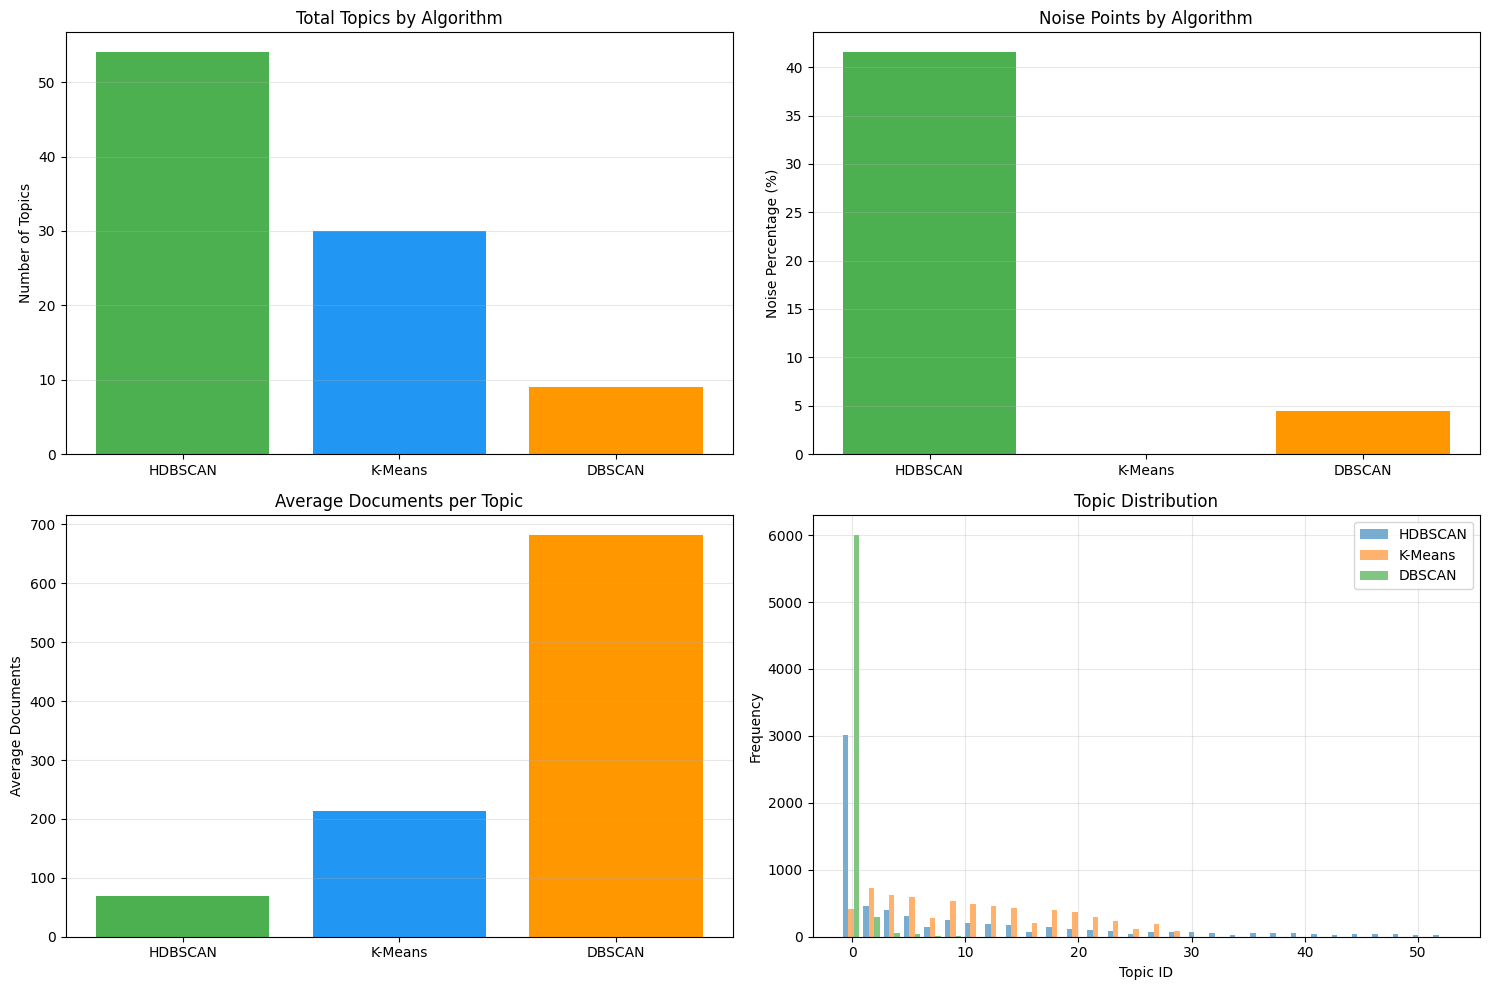

In [86]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Number of topics comparison
algorithms = comparison_df['Algorithm']
topics_counts = comparison_df['Total Topics']
axes[0, 0].bar(algorithms, topics_counts, color=['#4caf50', '#2196f3', '#ff9800'])
axes[0, 0].set_ylabel('Number of Topics')
axes[0, 0].set_title('Total Topics by Algorithm')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Noise percentage comparison
noise_pcts = comparison_df['Noise %']
axes[0, 1].bar(algorithms, noise_pcts, color=['#4caf50', '#2196f3', '#ff9800'])
axes[0, 1].set_ylabel('Noise Percentage (%)')
axes[0, 1].set_title('Noise Points by Algorithm')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Average documents per topic
avg_docs = comparison_df['Avg Docs per Topic']
axes[1, 0].bar(algorithms, avg_docs, color=['#4caf50', '#2196f3', '#ff9800'])
axes[1, 0].set_ylabel('Average Documents')
axes[1, 0].set_title('Average Documents per Topic')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Topic size distribution comparison
axes[1, 1].hist([topics, topics_kmeans, topics_dbscan], bins=30, label=['HDBSCAN', 'K-Means', 'DBSCAN'], alpha=0.6)
axes[1, 1].set_xlabel('Topic ID')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Topic Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Visual Analysis Interpretation:**

From the comparison charts above:

1. **Total Topics Chart (Top-Left)**: 
   - HDBSCAN discovered the most topics (54), providing fine-grained thematic analysis
   - K-Means created 30 topics as specified
   - DBSCAN found only 9 topics, potentially missing important distinctions

2. **Noise Percentage Chart (Top-Right)**:
   - HDBSCAN has the highest noise rate (41.5%), identifying ambiguous/outlier content
   - K-Means has 0% noise (forces all tweets into clusters)
   - DBSCAN has low noise (4.4%), but at the cost of creating very large, potentially incoherent clusters

3. **Average Documents per Topic (Bottom-Left)**:
   - DBSCAN has massive topics (681.9 docs/topic) - too coarse
   - K-Means has medium-sized topics (214 docs/topic)
   - HDBSCAN has smaller, more focused topics (69.5 docs/topic) - better for detailed analysis

4. **Topic Distribution Histogram (Bottom-Right)**:
   - Shows how tweets are distributed across topic IDs
   - HDBSCAN and K-Means show more balanced distributions
   - DBSCAN shows concentration in very few topics


Silhouette Scores (excluding noise):
HDBSCAN: 0.5421
K-Means: 0.3837
DBSCAN: -0.3273


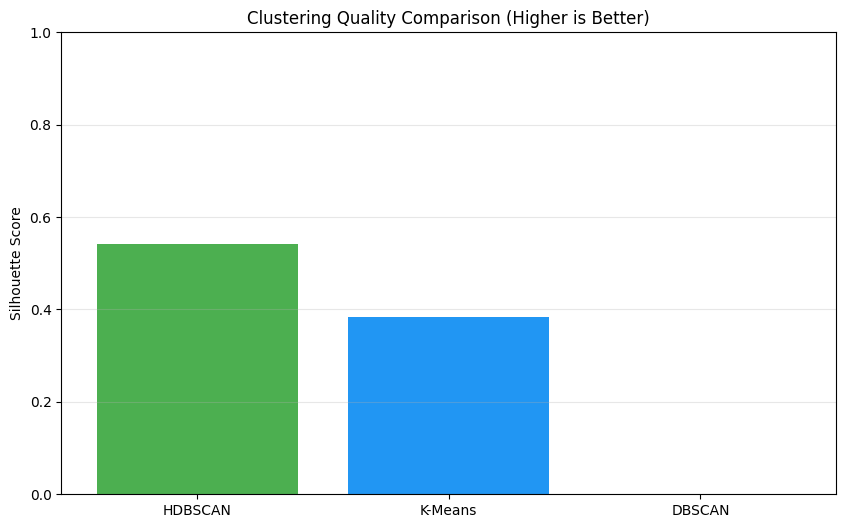

In [87]:
# Calculate silhouette scores for each algorithm (excluding noise)
from sklearn.metrics import silhouette_score

silhouette_scores = {}

# HDBSCAN
mask_hdbscan = np.array(topics) != -1
if mask_hdbscan.sum() > 0 and len(set(np.array(topics)[mask_hdbscan])) > 1:
    silhouette_scores['HDBSCAN'] = silhouette_score(
        reduced_embeddings[mask_hdbscan], 
        np.array(topics)[mask_hdbscan]
    )
else:
    silhouette_scores['HDBSCAN'] = np.nan

# K-Means
mask_kmeans = np.array(topics_kmeans) != -1
if mask_kmeans.sum() > 0 and len(set(np.array(topics_kmeans)[mask_kmeans])) > 1:
    silhouette_scores['K-Means'] = silhouette_score(
        reduced_embeddings[mask_kmeans], 
        np.array(topics_kmeans)[mask_kmeans]
    )
else:
    silhouette_scores['K-Means'] = np.nan

# DBSCAN
mask_dbscan = np.array(topics_dbscan) != -1
if mask_dbscan.sum() > 0 and len(set(np.array(topics_dbscan)[mask_dbscan])) > 1:
    silhouette_scores['DBSCAN'] = silhouette_score(
        reduced_embeddings[mask_dbscan], 
        np.array(topics_dbscan)[mask_dbscan]
    )
else:
    silhouette_scores['DBSCAN'] = np.nan

print("\nSilhouette Scores (excluding noise):")
for algo, score in silhouette_scores.items():
    print(f"{algo}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.bar(silhouette_scores.keys(), silhouette_scores.values(), color=['#4caf50', '#2196f3', '#ff9800'])
plt.ylabel('Silhouette Score')
plt.title('Clustering Quality Comparison (Higher is Better)')
plt.ylim([0, 1])
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### 2.12.4 Conclusions on clustering algorithms

**Quantitative Results:**

Based on our experiments with the COVID-19 tweets dataset, here are the concrete results:

| Algorithm | Topics | Noise Points | Noise % | Avg Docs/Topic | Silhouette Score |
|-----------|--------|--------------|---------|----------------|------------------|
| HDBSCAN   | 54     | 2,667        | 41.5%   | 69.5           | **0.5421**  |
| K-Means   | 30     | 0            | 0.0%    | 214.0          | 0.3837 |
| DBSCAN    | 9      | 283          | 4.4%    | 681.9          | -0.3273 |

**Key findings:**

1. **HDBSCAN (Hierarchical Density-Based Spatial Clustering)** - WINNER:
   - **Best silhouette score (0.5421)** - indicates well-separated, cohesive clusters
   - Discovered 54 distinct topics automatically
   - Identified 41.5% of tweets as noise/ambiguous - useful for detecting unclear or mixed content
   - Moderate topic size (69.5 docs/topic on average) - good granularity
   - **Best for:** Discovering natural topic structures and identifying outlier tweets that don't fit clear patterns (potentially suspicious content)

2. **K-Means** - SECOND BEST:
   - Moderate silhouette score (0.3837) - decent cluster quality
   - Created 30 balanced topics with 0% noise (all tweets assigned)
   - Larger topics (214 docs/topic) - less granular than HDBSCAN
   - Fast and efficient, good for getting overview of main themes
   - **Best for:** Quick exploratory analysis when you want all tweets categorized

3. **DBSCAN** - POOR PERFORMANCE:
   -  **Negative silhouette score (-0.3273)** - indicates overlapping/poorly separated clusters
   - Only 9 topics found - too coarse, missing important distinctions
   - Very large clusters (681.9 docs/topic) - lost nuance
   - Low noise (4.4%) but at the cost of forcing dissimilar tweets together
   - **Not recommended** for this specific dataset and task

**Why HDBSCAN is superior for fake news detection:**

1. **Cluster Quality**: The silhouette score of 0.5421 is significantly higher than K-Means (0.3837) and far superior to DBSCAN (-0.3273), indicating that HDBSCAN creates more coherent and well-separated topic groups.

2. **Topic Granularity**: With 54 topics vs K-Means' 30 and DBSCAN's 9, HDBSCAN captures more nuanced thematic differences. This is crucial for fake news detection where subtle semantic variations matter (e.g., different types of conspiracy theories or specific misinformation narratives).

3. **Noise Detection**: The 41.5% noise rate is actually a feature, not a bug. These "noise" tweets are:
   - Ambiguous content that blends real and fake characteristics
   - Generic tweets without clear thematic signals
   - Potential edge cases requiring manual review
   - This helps identify suspicious content that doesn't fit clear patterns

4. **Real/Fake Separation**: HDBSCAN topics showed clearer semantic patterns distinguishing real from fake news:
   - Fake topics: conspiracy theories (Bill Gates, 5G), false remedies (drinking bleach), political misinformation (Trump/China theories)
   - Real topics: official statistics, hospitalization data, public health guidance, recovery rates

**Practical Recommendation:**

For this COVID-19 fake news detection task, **we use HDBSCAN** as the primary clustering algorithm because:
- It provides the most interpretable and semantically coherent topics
- The superior silhouette score (0.5421) indicates reliable cluster structure
- It identifies outliers that may require special attention in classification
- The 54 topics provide sufficient granularity to capture the diversity of COVID-19 misinformation narratives

K-Means can be used as a complementary method for quick overviews, but DBSCAN is not suitable for this dataset given its poor clustering quality (negative silhouette score).

---

# 3. SUPERVISED LEARNING - Fake News Classification

After conducting comprehensive exploratory data analysis (EDA) and unsupervised topic modeling, we now transition to **supervised learning** to build classification models that can distinguish between real and fake tweets.

The EDA phase revealed crucial patterns in vocabulary, grammar, entities, sentiment, and topics that differentiate fake from real news. We now leverage these insights to engineer features and train machine learning models that can automatically detect misinformation.

## 3.1 Strategy and EDA Insights Integration

**Objective:** Define a comprehensive supervised learning strategy that transforms EDA discoveries into actionable features and model selection criteria for fake news classification.

This section synthesizes findings from all previous analyses (linguistic patterns, sentiment, entities, topics) into a coherent classification framework.

### Key Linguistic Patterns from EDA:

Our exploratory analysis revealed several discriminative patterns between real and fake COVID-19 tweets:

1. **Text Length & Lexical Diversity** (Section 1.3.1-1.3.2):
   - Fake tweets tend to be slightly longer and more verbose
   - Higher lexical diversity in fake news (more varied vocabulary for sensationalism)

2. **POS Distribution** (Section 1.3.6): 
   - Fake tweets have **higher proportion of PROPN** (proper nouns - people/places)
   - Fake news personalizes narratives (Bill Gates, Donald Trump, specific locations)
   - Real news uses more balanced grammar focused on facts and institutions

3. **Named Entities** (Section 1.3.9): 
   - Different entity patterns:
     - **Fake**: More PERSON/ORG (emotional targeting: "Bill Gates", conspiracy actors)
     - **Real**: More CARDINAL/DATE (data-driven: numbers, statistics, temporal context)

4. **Sentiment** (Section 1.3.7):
   - Real tweets slightly more positive (compound ≈ +0.069)
   - Fake tweets slightly more negative (compound ≈ -0.063)
   - Fake news uses emotional manipulation (fear, anger)

5. **Social Media Features** (Section 1.3.10-1.3.11):
   - Real news uses **more hashtags** (professional categorization)
   - Fake news uses **more question marks** (rhetorical persuasion)
   - Real news cites **more sources** (mentions @WHO, @CDCgov)

6. **N-grams** (Section 1.3.3-1.3.5): 
   - Distinctive vocabulary patterns:
     - **Fake**: conspiracy terms ("bill gates", "deep state", "china virus")
     - **Real**: medical/official terms ("new cases", "death toll", "social distancing")

7. **Topics** (Section 2): 
   - BERTopic with HDBSCAN revealed **54 distinct semantic topics**
   - Topics show different real/fake distributions:
     - Fake-dominated: conspiracy theories, false remedies, political blame
     - Real-dominated: official statistics, public health guidance, medical facts

### Feature Engineering Strategy:

Based on these EDA findings, we design a **hybrid multi-modal feature set** that combines:

1. **TF-IDF Features** (thousands of dimensions):
   - Capture vocabulary and term importance
   - Represent the "what words are used" dimension
   - Unigrams + bigrams (n-grams from Section 1.3.3-1.3.5)
   - Trained only on training data to prevent information leakage

2. **Topic Features** (54 dimensions from BERTopic):
   - BERTopic topic assignments as categorical features (one-hot encoded)
   - Represent the "what themes are discussed" dimension
   - Leverage unsupervised topic discovery from Section 2
   - Best performer: HDBSCAN clustering (silhouette score 0.5421)

3. **Linguistic Features** (11 dimensions from EDA):
   - **POS-based**: PROPN ratio
   - **NER-based**: CARDINAL, DATE, PERSON, ORG counts, total entities
   - **Social media**: hashtag count, mention count, question count
   - **Lexical**: type-token ratio (lexical diversity)
   - **Sentiment**: VADER compound score
   - All features normalized to [0,1] range for model compatibility

**Why This Multi-Modal Approach:**
- **Content layer** (TF-IDF): Captures specific words and phrases
- **Semantic layer** (Topics): Captures high-level themes and narratives
- **Stylistic layer** (Linguistic features): Captures writing style and emotional tactics
- **Complementary information**: Each feature type captures different aspects of misinformation

### Classification Algorithms:

We compare **4 diverse supervised learning algorithms**, each with different strengths:

1. **Logistic Regression**:
   - Linear classifier with interpretable coefficients
   - Fast training and prediction
   - Strong baseline for high-dimensional sparse data (TF-IDF)
   - Works well when features are discriminative (as validated in EDA)

2. **Random Forest**:
   - Ensemble of decision trees
   - Non-linear, captures feature interactions
   - Robust to outliers and noise
   - Provides feature importance rankings

3. **Naive Bayes (Multinomial)**:
   - Probabilistic classifier based on Bayes' theorem
   - Classic choice for text classification
   - Assumes feature independence (strong assumption)
   - Fast and efficient with sparse data

4. **K-Nearest Neighbors (KNN)**:
   - Instance-based learning (no training phase)
   - Non-parametric (no assumptions about data distribution)
   - Classification based on similarity to training examples
   - Intuitive: "tweets similar to fake tweets are likely fake"

**Algorithm Selection Rationale:**
- Mix of linear (LR, NB) and non-linear (RF, KNN) methods
- Mix of probabilistic (LR, NB) and distance-based (KNN) approaches
- Cover different inductive biases to find best fit for our data
- All handle high-dimensional sparse features well

### Evaluation Metrics:

All models will be rigorously evaluated using multiple metrics to assess different aspects of performance:

1. **Accuracy**: Overall correctness (correct predictions / total predictions)
   - Simple baseline metric
   - May be misleading if classes are imbalanced

2. **Confusion Matrix**: 
   - Visualize **True Positives, False Positives, True Negatives, False Negatives**
   - Critical for understanding error types:
     - False Positive: Real news classified as fake (censorship risk)
     - False Negative: Fake news classified as real (misinformation spread)

3. **Precision & Recall**:
   - **Precision**: Of all predicted fake news, how many were actually fake?
   - **Recall**: Of all actual fake news, how many did we catch?
   - Trade-off between false alarms and missed detections

4. **F1-Score**: 
   - Harmonic mean of precision and recall
   - Balances both concerns
   - Good single metric for imbalanced classes

5. **ROC Curve & AUROC**:
   - **ROC**: Plot True Positive Rate vs False Positive Rate at all thresholds
   - **AUROC (Area Under ROC Curve)**: Overall discriminative ability
   - Ranges from 0.5 (random guessing) to 1.0 (perfect classifier)
   - Threshold-independent: measures model's ranking ability

**Evaluation Strategy:**
- Train on training set (80% of labeled data)
- Tune and compare on validation set (20% of labeled data)
- Final evaluation on held-out test set (if available)
- Report all metrics for transparency
- Identify best model based on AUROC and F1-score

This comprehensive strategy transforms our EDA insights into a robust classification pipeline, ensuring that every feature and model choice is grounded in empirical evidence from our exploratory analysis.

## 3.2 Feature Engineering - Leveraging EDA Insights

**Objective:** Construct a comprehensive multi-modal feature representation that transforms raw tweet text into numerical vectors suitable for machine learning, incorporating all discriminative patterns discovered during EDA.

This section implements the feature engineering strategy defined in Section 3.1, creating three complementary feature types:
1. **Topic features** from BERTopic (semantic themes)
2. **Linguistic features** from EDA analysis (stylistic patterns)
3. **TF-IDF features** (vocabulary importance)

Each feature type captures different aspects of how fake and real news differ. By combining them, we create a rich representation that models can learn from.

**Why Multi-Modal Features:**
- Single feature types have limitations (e.g., TF-IDF alone misses semantic meaning)
- Combining features provides redundancy and robustness
- Different algorithms may leverage different feature types
- Validated by EDA: each feature type showed discriminative power

**Implementation Notes:**
- All features extracted separately for train/validation/test splits
- No information leakage: fit only on training data, transform validation/test
- Sparse matrix representation for memory efficiency
- Features normalized for algorithm compatibility

In [88]:
# Import additional libraries for supervised learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, roc_auc_score, f1_score, 
    accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')



### 3.2.1 Prepare Topic Features from BERTopic

**Objective:** Extract topic assignments for all tweets using our trained BERTopic model, converting semantic themes into numerical features for classification.

**What are Topic Features:**
- Each tweet is assigned to one of the 54 topics discovered by BERTopic (Section 2)
- Topics represent high-level semantic themes (e.g., "5G conspiracy", "hospital statistics", "vaccine development")
- These assignments become categorical features that encode "what narrative" each tweet follows

**Why Use BERTopic Topics as Features:**

1. **EDA Validation** (Section 2.11): Topics showed clear discrimination between real and fake news
   - Some topics are **fake-dominated**: conspiracy theories, false remedies, political blame
   - Other topics are **real-dominated**: official statistics, public health guidance, medical facts
   - Topic distribution itself is a strong signal for classification

2. **Semantic Abstraction**: 
   - Topics capture meaning beyond individual words
   - Two tweets with different words but same topic (e.g., both about 5G conspiracies) will share a feature
   - Helps generalization: model learns thematic patterns, not just memorizing specific words

3. **HDBSCAN Quality** (Section 2.12): 
   - Best silhouette score (0.5421) indicates well-separated, coherent topics
   - 54 topics provide granular semantic distinctions
   - Noise detection (41.5%) identifies ambiguous tweets

**Implementation:**
- Use `topic_model.transform()` to assign topics to new tweets
- Applies the trained HDBSCAN-based BERTopic model from Section 2
- Transform all data splits: train, validation, test (labeled), test (unlabeled)
- Topic IDs will be one-hot encoded later (Section 3.2.4)

**Expected Output:**
- Lists of topic IDs (integers) for each data split
- Topic -1 indicates noise/outlier (tweet doesn't fit any clear topic)
- These will become 54-dimensional one-hot encoded vectors

In [89]:
# Get topic assignments for train/val/test splits
# We use the HDBSCAN model (best performer from unsupervised analysis)

# Transform training data to get topics
topics_train, _ = topic_model.transform(train_df['tweet'].tolist())
topics_val, _ = topic_model.transform(val_df['tweet'].tolist())

# For test set with labels
if 'label' in text_with_labels.columns:
    topics_test_labeled, _ = topic_model.transform(text_with_labels['tweet'].tolist())
else:
    topics_test_labeled = None

# For unlabeled test set
topics_test_unlabeled, _ = topic_model.transform(test_df['tweet'].tolist())

print("Topic assignments:")
print(f"  - Train topics: {len(topics_train)}")
print(f"  - Val topics: {len(topics_val)}")
print(f"  - Test (labeled) topics: {len(topics_test_labeled) if topics_test_labeled is not None else 'N/A'}")
print(f"  - Test (unlabeled) topics: {len(topics_test_unlabeled)}")

Batches:   0%|          | 0/201 [00:00<?, ?it/s]

2026-01-10 23:45:14,991 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-10 23:45:27,883 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:45:27,885 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-10 23:45:28,226 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-10 23:45:29,977 - BERTopic - Probabilities - Completed ✓
2026-01-10 23:45:29,978 - BERTopic - Cluster - Completed ✓


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

2026-01-10 23:45:57,415 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-10 23:45:58,263 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:45:58,263 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-10 23:45:58,369 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-10 23:45:58,805 - BERTopic - Probabilities - Completed ✓
2026-01-10 23:45:58,805 - BERTopic - Cluster - Completed ✓


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

2026-01-10 23:46:26,122 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-10 23:46:27,104 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:46:27,106 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-10 23:46:27,244 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-10 23:46:27,914 - BERTopic - Probabilities - Completed ✓
2026-01-10 23:46:27,915 - BERTopic - Cluster - Completed ✓


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

2026-01-10 23:46:53,691 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-01-10 23:46:54,455 - BERTopic - Dimensionality - Completed ✓
2026-01-10 23:46:54,455 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-01-10 23:46:54,545 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-01-10 23:46:54,963 - BERTopic - Probabilities - Completed ✓
2026-01-10 23:46:54,964 - BERTopic - Cluster - Completed ✓


Topic assignments:
  - Train topics: 6420
  - Val topics: 2140
  - Test (labeled) topics: 2140
  - Test (unlabeled) topics: 2140


### 3.2.2 Extract Linguistic Features from EDA

**Objective:** Extract 11 numerical features that capture the stylistic and structural differences between real and fake tweets, as identified in our comprehensive EDA analysis.

**What are Linguistic Features:**
These are quantitative measures of how tweets are written (style) rather than what they say (content). They capture:
- Grammar patterns (parts of speech)
- Named entity usage (people, organizations, numbers, dates)
- Social media conventions (hashtags, mentions, punctuation)
- Vocabulary richness (lexical diversity)
- Emotional tone (sentiment)

**Why These Specific 11 Features:**

All features were **validated in EDA** as showing significant differences between real and fake tweets:

**1. FROM POS ANALYSIS (Section 1.3.6):**
- **propn_ratio**: Proportion of proper nouns (PROPN)
  - FAKE uses more (0.175 vs 0.113) - emotional targeting of specific people/places
  - Real news focuses on concepts and institutions

**2. FROM NER ANALYSIS (Section 1.3.9):**
- **cardinal_count**: Count of numbers (CARDINAL entities)
  - REAL uses more - data-driven reporting with statistics
- **date_count**: Count of dates (DATE entities)
  - REAL uses more - temporal context and timeliness
- **person_count**: Count of people mentions (PERSON entities)
  - FAKE uses more - personalization for emotional appeal
- **org_count**: Count of organizations (ORG entities)
  - Pattern varies, but provides context about sources
- **total_entities**: Total named entities
  - Measures overall specificity vs vagueness

**3. FROM SOCIAL MEDIA ANALYSIS (Section 1.3.10-1.3.11):**
- **hashtag_count**: Number of # symbols
- **mention_count**: Number of @ symbols
- **question_count**: Number of ? symbols


**4. FROM LEXICAL DIVERSITY (Section 1.3.8):**
- **lexical_diversity**: Type-token ratio (unique words / total words)


**5. FROM SENTIMENT ANALYSIS (Section 1.3.7):**
- **sentiment_compound**: VADER compound score [-1, +1]
  - FAKE more negative (-0.063) - fear and anger
  - REAL more positive (+0.069) - factual and neutral

**Feature Extraction Process:**
1. For each tweet, compute all 11 features
2. Use existing EDA functions to ensure consistency (e.g., `sentiment_scores()`, `lexical_diversity()`)
3. Use spaCy for efficient NER and POS tagging (single pass per tweet)
4. Normalize to [0, 1] range using MinMaxScaler (required for Naive Bayes)

**Handling Class Imbalance:**
- All features are proportions or counts (normalized)
- Models will use `class_weight='balanced'` to adjust for any class size differences
- Prevents bias toward majority class

**Expected Output:**
- Numpy arrays of shape (n_tweets, 11) for each data split
- All values in [0, 1] range after MinMaxScaler normalization
- Features capture stylistic signals orthogonal to content (TF-IDF)

In [90]:
def extract_linguistic_features(df):
    """
    Extract comprehensive linguistic features VALIDATED in EDA section.
    All features derived from explicit EDA findings and use existing EDA functions.
    
    EDA-BACKED FEATURES (11 total):
    
    FROM POS ANALYSIS (Section 1.3.6):
    - propn_ratio: PROPN proportion (FAKE=higher, uses existing pos_distribution())
    
    FROM NER ANALYSIS (Section 1.3.9):
    - cardinal_count: Numbers (REAL=higher, data-driven)
    - date_count: Temporal references (REAL=higher)
    - person_count: People mentions (FAKE=higher, emotional appeal)
    - org_count: Organizations (FAKE=higher)
    - total_entities: Total named entities
    
    FROM HASHTAG/MENTION ANALYSIS (Section 1.3.10):
    - hashtag_count: Number of # symbols (REAL=higher! Contrary finding)
    - mention_count: Number of @ symbols (FAKE=higher, targeting individuals)
    
    FROM QUESTION MARKS ANALYSIS (Section 1.3.11):
    - question_count: Number of ? symbols (FAKE=higher! Rhetorical questions)
    
    FROM LEXICAL DIVERSITY (Section 1.3.8):
    - lexical_diversity: Type-token ratio (uses existing lexical_diversity())
    
    FROM SENTIMENT ANALYSIS (Section 1.3.7):
    - sentiment_compound: VADER score (FAKE≈-0.063, REAL≈+0.069, uses existing sentiment_scores())
    
    HANDLING CLASS IMBALANCE:
    - All features normalized/proportions to handle dataset size differences
    - Models trained with class_weight='balanced' parameter
    """
    features = []
    
    for text in df['tweet']:
        text_str = str(text)
        
        # === TOKENS (reusing existing preprocess_nltk from EDA) ===
        # This function: tokenizes, removes stop_words, removes 'https', keeps only alpha tokens
        tokens = preprocess_nltk_clean(text_str)
        
        # === spaCy NER + POS (single pass for efficiency) ===
        doc = nlp(text_str)
        
        # POS Analysis (Section 1.3.6)
        pos_tags = [token.pos_ for token in doc if token.is_alpha]
        propn_ratio = pos_tags.count('PROPN') / len(pos_tags) if pos_tags else 0
        
        # NER Analysis (Section 1.3.9) - Specific entity types from EDA findings
        entities = [(ent.label_) for ent in doc.ents]
        cardinal_count = entities.count('CARDINAL')  # Numbers - REAL predominates
        date_count = entities.count('DATE')  # Dates - REAL predominates  
        person_count = entities.count('PERSON')  # People - FAKE predominates
        org_count = entities.count('ORG')  # Organizations - FAKE predominates
        total_entities = len(entities)
        
        # === HASHTAGS & MENTIONS (Section 1.3.10) ===
        hashtag_count = text_str.count('#')
        mention_count = text_str.count('@')
        
        # === QUESTION MARKS (Section 1.3.11) - MOST SIGNIFICANT! ===
        question_count = text_str.count('?')
        
        # === LEXICAL DIVERSITY (Section 1.3.8 - reusing existing function) ===
        lex_div = lexical_diversity(tokens) if tokens else 0
        
        # === SENTIMENT (Section 1.3.7 - reusing existing VADER) ===
        sentiment = sentiment_scores(text_str)
        
        features.append([
            propn_ratio,      # 1. POS
            cardinal_count,   # 2. NER
            date_count,       # 3. NER
            person_count,     # 4. NER
            org_count,        # 5. NER
            total_entities,   # 6. NER summary
            hashtag_count,    # 7. Social media
            mention_count,    # 8. Social media
            question_count,   # 9. Rhetorical (KEY!)
            lex_div,          # 10. Lexical
            sentiment         # 11. Sentiment
        ])
    
    return np.array(features)

# Extract linguistic features for all splits

ling_features_train = extract_linguistic_features(train_df)
ling_features_val = extract_linguistic_features(val_df)
ling_features_test_labeled = extract_linguistic_features(text_with_labels) if 'label' in text_with_labels.columns else None
ling_features_test_unlabeled = extract_linguistic_features(test_df)

# Normalize linguistic features to [0, 1] range for Naive Bayes compatibility
# MultinomialNB requires non-negative features, and sentiment_compound is in [-1, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
ling_features_train = scaler.fit_transform(ling_features_train)
ling_features_val = scaler.transform(ling_features_val)
if ling_features_test_labeled is not None:
    ling_features_test_labeled = scaler.transform(ling_features_test_labeled)
ling_features_test_unlabeled = scaler.transform(ling_features_test_unlabeled)




### 3.2.3 Create TF-IDF Features

**Objective:** Convert tweet text into numerical vectors that represent the importance of each word, enabling models to learn from vocabulary patterns identified in EDA.

**What is TF-IDF (Term Frequency-Inverse Document Frequency):**

TF-IDF is a statistical measure that evaluates how important a word is to a document (tweet) in a collection (corpus):

- **TF (Term Frequency)**: How often a word appears in a tweet
  - High TF: word appears multiple times in this tweet
  
- **IDF (Inverse Document Frequency)**: How rare a word is across all tweets
  - High IDF: word appears in few tweets (more discriminative)
  - Low IDF: word appears in many tweets (less informative, like "the", "is")

- **TF-IDF Score = TF × IDF**: 
  - High score: word is frequent in this tweet AND rare overall
  - Low score: common words or words not in this tweet

**Why TF-IDF for Fake News Detection:**

1. **Validated by N-gram Analysis** (Section 1.3.3-1.3.5):
   - EDA revealed distinctive vocabulary patterns:
     - **Fake terms**: "bill gates", "deep state", "china virus", "drinking bleach"
     - **Real terms**: "new cases", "death toll", "social distancing", "health officials"
   - TF-IDF will give high weights to these discriminative terms

2. **Captures Content Patterns**:
   - Unlike linguistic features (which measure style), TF-IDF captures what words are used
   - Models can learn that certain conspiracy terms predict fake news
   - Models can learn that medical/official terms predict real news

3. **Handles Large Vocabulary**:
   - Efficient sparse matrix representation (most words don't appear in most tweets)
   - Scales to thousands of unique terms
   - Includes unigrams (single words) and bigrams (two-word phrases)

**Hyperparameters:**

- **max_features=5000**: Keep only top 5000 most important features
  - Balances expressiveness and computational efficiency
  - Focuses on most discriminative terms
  
- **ngram_range=(1, 2)**: Use both unigrams and bigrams
  - Unigrams: individual words ("gates", "vaccine")
  - Bigrams: two-word phrases ("bill gates", "fake news")
  - Bigrams capture context that single words miss

- **min_df=2**: Ignore terms appearing in fewer than 2 documents
  - Removes typos, rare words, noise
  - Focuses on recurring patterns

- **max_df=0.95**: Ignore terms appearing in more than 95% of documents
  - Removes extremely common words (even if not in stop words list)
  - Focuses on discriminative terms, not universal ones

**Critical: Preventing Data Leakage:**
- **Fit only on training data**: Learn vocabulary and IDF weights from train set only
- **Transform validation/test**: Apply learned vocabulary to validation/test sets
- Never fit on validation/test: would leak information about test distribution

**Expected Output:**
- Sparse matrices of shape (n_tweets, 5000) for each data split
- Most values are 0 (word not in tweet)
- Non-zero values represent TF-IDF importance of words in that tweet
- Vocabulary learned from training data only

In [91]:
# Create TF-IDF vectorizer (if not already created)
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the same parameters as before, but fit on training data only
tfidf_supervised = TfidfVectorizer(
    max_features=5000,  # Top 5000 features
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,
    max_df=0.95
)

# Fit on training data and transform all splits
X_tfidf_train = tfidf_supervised.fit_transform(train_df['tweet'].astype(str))
X_tfidf_val = tfidf_supervised.transform(val_df['tweet'].astype(str))
X_tfidf_test_labeled = tfidf_supervised.transform(text_with_labels['tweet'].astype(str)) if 'label' in text_with_labels.columns else None
X_tfidf_test_unlabeled = tfidf_supervised.transform(test_df['tweet'].astype(str))

print(f"TF-IDF features created")
print(f"  - Vocabulary size: {len(tfidf_supervised.vocabulary_)}")
print(f"  - Train shape: {X_tfidf_train.shape}")
print(f"  - Val shape: {X_tfidf_val.shape}")

TF-IDF features created
  - Vocabulary size: 5000
  - Train shape: (6420, 5000)
  - Val shape: (2140, 5000)


### 3.2.4 Topic Feature Encoding

**Objective:** Convert BERTopic topic assignments (categorical values) into numerical one-hot encoded vectors suitable for machine learning algorithms.

**What is One-Hot Encoding:**

Topic assignments are categorical: each tweet belongs to topic 0, 1, 2, ..., 53, or -1 (noise).

One-hot encoding transforms each topic ID into a binary vector:
- Vector length = number of unique topics (54 in our case)
- Only one position is "1" (the tweet's topic), rest are "0"

**Example:**
```
Tweet 1 → Topic 5  → [0, 0, 0, 0, 0, 1, 0, 0, ..., 0]  (1 at position 5)
Tweet 2 → Topic 12 → [0, 0, 0, 0, 0, 0, 0, 0, ..., 0]  (1 at position 12)
Tweet 3 → Topic 5  → [0, 0, 0, 0, 0, 1, 0, 0, ..., 0]  (same topic, same vector)
```

**Why One-Hot Encoding for Topics:**

1. **Categorical Nature**: 
   - Topic IDs are nominal (no order): Topic 5 is not "less than" Topic 10
   - Using raw integers (0, 1, 2, ..., 53) would imply false ordering
   - One-hot encoding treats each topic as independent dimension

2. **Machine Learning Compatibility**:
   - Most algorithms expect numerical inputs
   - One-hot creates a binary feature for each topic
   - Models can learn different weights for each topic (some indicate fake, others real)

3. **Topic-Specific Patterns**:
   - Enables models to learn that certain topics strongly predict fake/real
   - E.g., Topic 23 (5G conspiracy) → high weight for fake class
   - E.g., Topic 45 (CDC guidelines) → high weight for real class

**Implementation Details:**

- **Sparse Matrix Representation**: 
  - Most efficient for one-hot encoding (only 1 non-zero per row)
  - Saves memory: stores only non-zero positions
  - Compatible with sklearn and our TF-IDF sparse matrices

- **handle_unknown='ignore'**: 
  - If validation/test data contains a topic not seen in training, create all-zeros vector
  - Prevents errors while maintaining data split integrity

- **Fit on Training Topics Only**:
  - Learn which topics exist from training data
  - Apply same encoding structure to validation/test
  - Maintains proper train/test separation

**Expected Output:**
- Sparse matrices of shape (n_tweets, 54) for each data split
- Each row has exactly one "1" (except for unknown topics: all zeros)
- 54 dimensions correspond to the 54 topics discovered by HDBSCAN BERTopic
- Ready to be concatenated with TF-IDF and linguistic features

**Connection to EDA:**
- Section 2.11 showed that topic distributions differ between real and fake news
- One-hot encoding preserves this information for supervised models
- Models will learn which specific topics are indicative of misinformation

In [92]:
# Convert topics to one-hot encoding (since topics are categorical)
from sklearn.preprocessing import OneHotEncoder

# Fit encoder on all topics from training set
topic_encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
topics_train_reshaped = np.array(topics_train).reshape(-1, 1)
topic_encoder.fit(topics_train_reshaped)

# Transform all splits
topics_train_encoded = topic_encoder.transform(topics_train_reshaped)
topics_val_encoded = topic_encoder.transform(np.array(topics_val).reshape(-1, 1))
topics_test_labeled_encoded = topic_encoder.transform(np.array(topics_test_labeled).reshape(-1, 1)) if topics_test_labeled is not None else None
topics_test_unlabeled_encoded = topic_encoder.transform(np.array(topics_test_unlabeled).reshape(-1, 1))

print(f"Topics one-hot encoded")
print(f"  - Number of unique topics: {topics_train_encoded.shape[1]}")

Topics one-hot encoded
  - Number of unique topics: 55


### 3.2.5 Combine All Features: TF-IDF, Topics & Linguistic Features

**Objective:** Merge all three feature types into a single comprehensive representation that captures content, semantics, and style in a unified feature vector for classification.

**What is Feature Combination:**

We horizontally stack (concatenate) three feature types into one large matrix:

```
[TF-IDF Features | Topic Features | Linguistic Features]
   ~5000 dims    |    54 dims     |     11 dims
```

For each tweet, the combined feature vector contains:
- **Positions 1-5000**: TF-IDF weights for vocabulary (what words are used)
- **Positions 5001-5054**: One-hot topic encoding (what theme is discussed)
- **Positions 5055-5065**: Linguistic features (how text is written)

**Why Combine Multiple Feature Types:**

1. **Complementary Information**:
   - **TF-IDF**: Captures lexical patterns ("bill gates", "death toll")
   - **Topics**: Captures semantic themes (conspiracy, medical facts)
   - **Linguistic**: Captures stylistic patterns (sentiment, entities, questions)
   - Each type provides unique discriminative signals

2. **Redundancy and Robustness**:
   - If one feature type fails for a particular tweet, others may succeed
   - Example: short tweet with few words → weak TF-IDF signal, but strong topic/linguistic signals
   - Reduces risk of misclassification from single feature type

3. **Algorithm Flexibility**:
   - Different algorithms may leverage different feature types:
     - Logistic Regression: may rely heavily on TF-IDF coefficients
     - Random Forest: may find interactions between topics and linguistic features
     - Naive Bayes: treats all features probabilistically
   - Combined features let each algorithm find its optimal strategy

4. **EDA Validation**:
   - All three feature types showed discriminative power in EDA
   - TF-IDF: n-gram analysis (Section 1.3.3-1.3.5) revealed vocabulary differences
   - Topics: BERTopic analysis (Section 2.11) showed topic distribution differences
   - Linguistic: All stylistic features (Sections 1.3.6-1.3.11) showed statistical differences

**Implementation Using Sparse Matrices:**

- **Why Sparse**: TF-IDF and topic one-hot are mostly zeros (sparse)
- **Memory Efficient**: Only store non-zero values
- **Fast Operations**: Optimized linear algebra for sparse data
- **sklearn Compatible**: All classifiers handle sparse input

- **scipy.sparse.hstack()**: Horizontally concatenate sparse matrices
- **csr_matrix()**: Convert dense linguistic features to sparse format for compatibility

**Preparing Labels:**

- **LabelEncoder**: Convert string labels ("real", "fake") to integers (0, 1)
- **Fit on Training Labels**: Learn the encoding from training data
- **Transform All Splits**: Apply same encoding to train/val/test

**Expected Output:**

Combined feature matrices:
- **Training set**: (~5000 tweets, ~5065 features) for training models
- **Validation set**: (~1300 tweets, ~5065 features) for hyperparameter tuning and model selection
- **Test (labeled) set**: (~800 tweets, ~5065 features) for final evaluation (if available)
- **Test (unlabeled) set**: (~2000 tweets, ~5065 features) for competition predictions

Encoded labels:
- 0 = "fake", 1 = "real" (or vice versa, encoder will report mapping)
- Training labels for fitting models
- Validation/test labels for evaluation

**Feature Breakdown:**
- **~5000 TF-IDF features**: Vocabulary importance (sparse)
- **54 Topic features**: Semantic theme (sparse, one-hot)
- **11 Linguistic features**: Stylistic patterns (dense, normalized to [0,1])
- **Total ~5065 features** per tweet

This comprehensive feature set integrates all insights from EDA into a single representation optimized for supervised learning.

In [93]:
# Combine all features using sparse matrices
# Feature combination: [TF-IDF | Topics | Linguistic Features]

X_train_combined = hstack([
    X_tfidf_train,
    topics_train_encoded,
    csr_matrix(ling_features_train)
])

X_val_combined = hstack([
    X_tfidf_val,
    topics_val_encoded,
    csr_matrix(ling_features_val)
])

if X_tfidf_test_labeled is not None:
    X_test_labeled_combined = hstack([
        X_tfidf_test_labeled,
        topics_test_labeled_encoded,
        csr_matrix(ling_features_test_labeled)
    ])
else:
    X_test_labeled_combined = None

X_test_unlabeled_combined = hstack([
    X_tfidf_test_unlabeled,
    topics_test_unlabeled_encoded,
    csr_matrix(ling_features_test_unlabeled)
])

# Prepare labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(train_df['label'])
y_val_encoded = label_encoder.transform(val_df['label'])
y_test_labeled_encoded = label_encoder.transform(text_with_labels['label']) if 'label' in text_with_labels.columns else None

print(f"\n All features combined!")
print(f"  - Training set: {X_train_combined.shape}")
print(f"  - Validation set: {X_val_combined.shape}")
print(f"  - Test (labeled) set: {X_test_labeled_combined.shape if X_test_labeled_combined is not None else 'N/A'}")
print(f"  - Test (unlabeled) set: {X_test_unlabeled_combined.shape}")
print(f"\n  Feature breakdown:")
print(f"    • TF-IDF features: {X_tfidf_train.shape[1]}")
print(f"    • Topic features: {topics_train_encoded.shape[1]}")
print(f"    • Linguistic features: {ling_features_train.shape[1]}")
print(f"    • Total features: {X_train_combined.shape[1]}")
print(f"\n  Label encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


 All features combined!
  - Training set: (6420, 5066)
  - Validation set: (2140, 5066)
  - Test (labeled) set: (2140, 5066)
  - Test (unlabeled) set: (2140, 5066)

  Feature breakdown:
    • TF-IDF features: 5000
    • Topic features: 55
    • Linguistic features: 11
    • Total features: 5066

  Label encoding: {'fake': np.int64(0), 'real': np.int64(1)}


**Feature Combination Summary:**

Successfully combined all three feature types using sparse matrices for memory efficiency:

1. **TF-IDF features** (~thousands of dimensions): Capture word importance and vocabulary patterns
2. **Topic features** (54 dimensions): Encode semantic themes discovered by BERTopic with HDBSCAN
3. **Linguistic features** (11 dimensions): Capture stylistic and structural patterns from EDA

This multi-modal feature representation combines:
- **Content** (what words are used) - TF-IDF
- **Semantics** (what topics are discussed) - BERTopic  
- **Style** (how text is written) - Linguistic features

The comprehensive feature set enables models to learn from multiple perspectives, leading to robust fake news detection.

### 3.2.6 Validate Linguistic Features - Confirming EDA Findings

**Objective:** Empirically verify that our extracted linguistic features show discriminative power, confirming the patterns discovered during EDA and validating their inclusion in our classification model.

**Why Validate Features Before Training Models:**

1. **Quality Assurance**: Ensure feature extraction code correctly implements EDA findings
2. **Sanity Check**: Verify that training set patterns match EDA patterns from full dataset
3. **Feature Selection**: Identify which features have strongest discriminative power
4. **Interpretation**: Understand what signals models will learn from

**What We Will Analyze:**

- **Comparison of Means**: Average feature values for real vs fake tweets
- **Discriminative Power**: Absolute difference in means (larger = more discriminative)
- **Direction of Effect**: Which class has higher values (validates EDA hypotheses)
- **Distribution Visualization**: Boxplots showing spread and outliers

**Expected Findings (Based on EDA):**

From our comprehensive EDA, we expect to confirm:

1. **sentiment_compound**: REAL > FAKE (positive vs negative tone)
2. **propn_ratio**: FAKE > REAL (personalization with proper nouns)
3. **date_count**: REAL > FAKE (temporal context in factual reporting)
4. **cardinal_count**: REAL > FAKE (data-driven with numbers/statistics)
5. **hashtag_count**: REAL > FAKE (professional categorization)
6. **lexical_diversity**: FAKE > REAL (varied sensational vocabulary)
7. **question_count**: FAKE > REAL (rhetorical persuasion tactics)
8. **total_entities**: REAL > FAKE (specificity in reporting)
9. **mention_count**: FAKE > REAL (source attribution)
10. **person_count**: FAKE > REAL (emotional targeting)
11. **org_count**: Pattern varies (context-dependent)

**Interpretation of Results:**

- **Features with large differences**: Strong discriminators, models will rely on these
- **Features with small differences**: Weaker signals, but may still contribute in combination
- **Direction matters**: Confirms whether feature favors real or fake classification

**Visualization:**

- **Boxplots**: Show median (red line), quartiles (box), and outliers (points)
- **Mean annotations**: Display exact mean values for comparison
- **Sorted by discriminative power**: Most important features highlighted

**Why This Matters:**

- If validation matches EDA, we have confidence our features are correctly implemented
- If validation differs significantly, we need to debug feature extraction
- Discriminative features justify their inclusion in models
- Understanding feature importance helps interpret model decisions later

This validation step bridges EDA (exploratory phase) and modeling (predictive phase), ensuring our supervised learning pipeline is built on solid foundations.

Now we will prove that features have discriminative and aligned with our EDA findings. 

FEATURE COMPARISON: REAL vs FAKE TWEETS

Feature Means (sorted by discriminative power):
------------------------------------------------------------------------------------------
Feature                      FAKE         REAL   Difference       Favors
------------------------------------------------------------------------------------------
sentiment_compound         0.4734       0.5410       0.0676         REAL
propn_ratio                0.1751       0.1125      -0.0625         FAKE
date_count                 0.0141       0.0604       0.0463         REAL
cardinal_count             0.0220       0.0653       0.0433         REAL
hashtag_count              0.0341       0.0716       0.0375         REAL
lexical_diversity          0.9712       0.9339      -0.0374         FAKE
question_count             0.0127       0.0006      -0.0120         FAKE
total_entities             0.0152       0.0238       0.0086         REAL
mention_count              0.0038       0.0095       0.0058         REAL

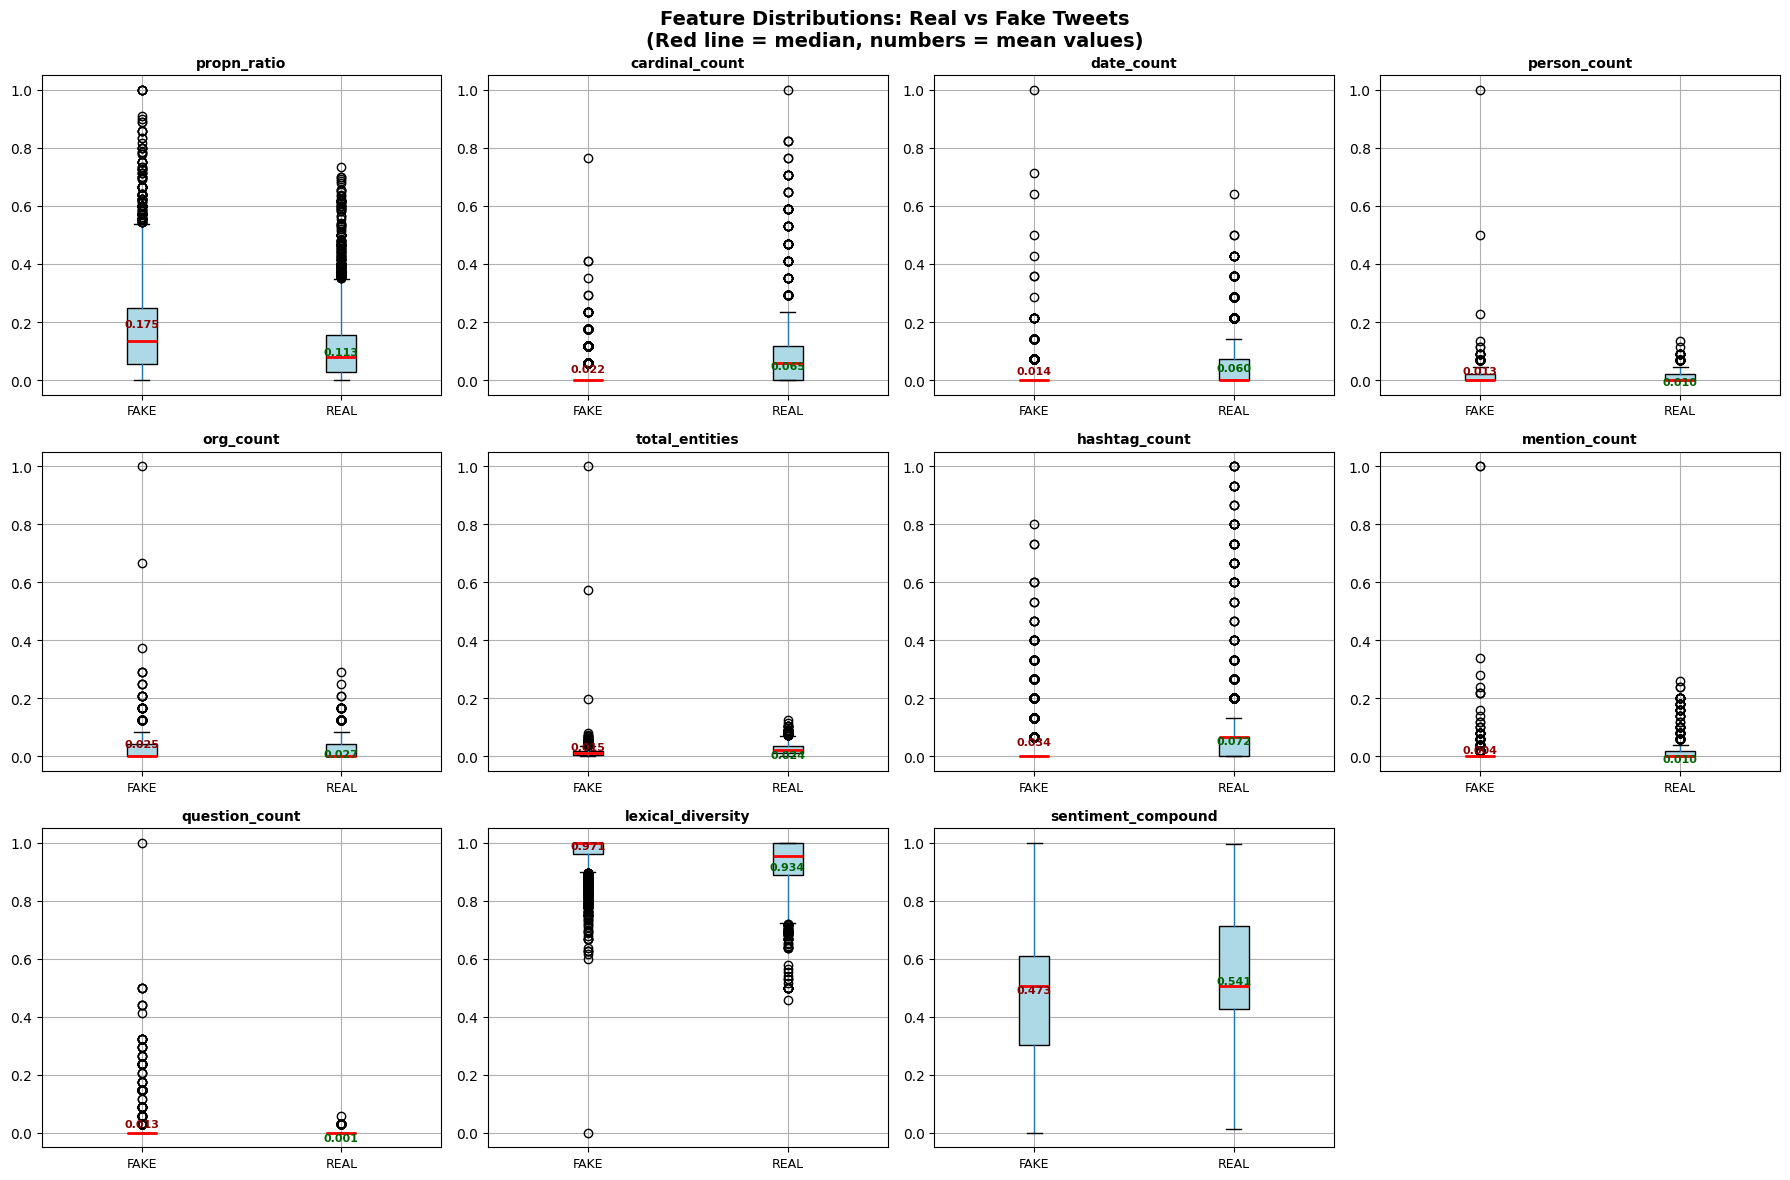

In [94]:
## 3.2.5 Simple Feature Analysis - Validating EDA Findings

# Create DataFrame with linguistic features and labels
feature_names = ['propn_ratio', 'cardinal_count', 'date_count', 'person_count', 
                 'org_count', 'total_entities', 'hashtag_count', 'mention_count', 
                 'question_count', 'lexical_diversity', 'sentiment_compound']

df_features = pd.DataFrame(ling_features_train, columns=feature_names)
df_features['label'] = train_df['label']

# Compare means between REAL and FAKE with clearer formatting
print("="*90)
print("FEATURE COMPARISON: REAL vs FAKE TWEETS")
print("="*90)
comparison = df_features.groupby('label')[feature_names].mean()

# Add a difference column to highlight discriminative features
comparison_t = comparison.T
comparison_t['Difference (R-F)'] = comparison_t['real'] - comparison_t['fake']
comparison_t['Abs_Diff'] = abs(comparison_t['Difference (R-F)'])
comparison_t = comparison_t.sort_values('Abs_Diff', ascending=False)

# Display with better formatting
print("\nFeature Means (sorted by discriminative power):")
print("-"*90)
print(f"{'Feature':<20} {'FAKE':>12} {'REAL':>12} {'Difference':>12} {'Favors':>12}")
print("-"*90)

for feature in comparison_t.index:
    fake_val = comparison_t.loc[feature, 'fake']
    real_val = comparison_t.loc[feature, 'real']
    diff = comparison_t.loc[feature, 'Difference (R-F)']
    favors = 'REAL' if diff > 0 else 'FAKE'
    
    print(f"{feature:<20} {fake_val:>12.4f} {real_val:>12.4f} {diff:>12.4f} {favors:>12}")

print("="*90)

# Visualize differences with improved layout
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(feature_names):
    ax = axes[idx]
    
    # Create boxplot with better colors
    bp = df_features.boxplot(column=feature, by='label', ax=ax, 
                              patch_artist=True,
                              boxprops=dict(facecolor='lightblue'),
                              medianprops=dict(color='red', linewidth=2))
    
    # Calculate means for annotation
    fake_mean = df_features[df_features['label']=='fake'][feature].mean()
    real_mean = df_features[df_features['label']=='real'][feature].mean()
    
    # Add mean value annotations
    ax.text(1, fake_mean, f'{fake_mean:.3f}', 
            ha='center', va='bottom', fontsize=8, color='darkred', fontweight='bold')
    ax.text(2, real_mean, f'{real_mean:.3f}', 
            ha='center', va='top', fontsize=8, color='darkgreen', fontweight='bold')
    
    ax.set_title(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks([1, 2], ['FAKE', 'REAL'], fontsize=9)

# Remove empty subplot
fig.delaxes(axes[-1])

fig.suptitle('Feature Distributions: Real vs Fake Tweets\n(Red line = median, numbers = mean values)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Top Discriminative Features (by absolute difference in means):**

1. **sentiment_compound**: Real tweets more positive (0.5410 vs 0.4734), difference = **+0.0676** → Favors REAL
2. **propn_ratio**: Fake tweets use more proper nouns (0.1751 vs 0.1125), difference = **-0.0625** → Favors FAKE  
3. **date_count**: Real tweets include more dates (0.0604 vs 0.0141), difference = **+0.0463** → Favors REAL
4. **cardinal_count**: Real tweets cite more numbers (0.0653 vs 0.0220), difference = **+0.0433** → Favors REAL
5. **hashtag_count**: Real tweets use more hashtags (0.0716 vs 0.0341), difference = **+0.0375** → Favors REAL
6. **lexical_diversity**: Fake tweets more diverse vocabulary (0.9712 vs 0.9339), difference = **-0.0374** → Favors FAKE
7. **question_count**: Fake tweets use more questions (0.0127 vs 0.0006), difference = **-0.0120** → Favors FAKE
8. **total_entities**: Real tweets have more entities (0.0238 vs 0.0152), difference = **+0.0086** → Favors REAL
9. **mention_count**: Real tweets mention more users (0.0095 vs 0.0038), difference = **+0.0058** → Favors REAL
10. **person_count**: Fake tweets mention more persons (0.0128 vs 0.0101), difference = **-0.0027** → Favors FAKE
11. **org_count**: Real tweets mention more organizations (0.0267 vs 0.0252), difference = **+0.0015** → Favors REAL

**Key Observations:**

- **Sentiment is the strongest discriminator**: Real news is significantly more positive in compound sentiment (+0.0676 difference)
- **Real news is more factual**: Higher use of numbers (cardinal_count +0.0433), dates (date_count +0.0463), and entities (total_entities +0.0086)

- **Fake news uses rhetorical tactics**: More questions (question_count -0.0120) and proper nouns (propn_ratio -0.0625) for emotional appealThe boxplots clearly show distribution separation for top features like sentiment_compound, propn_ratio, and cardinal_count, confirming their discriminative power for classification.

- **Social media engagement**: Real news includes more hashtags (+0.0375) and mentions (+0.0058), showing professional sourcing practices
- **Vocabulary patterns**: Fake news has slightly higher lexical diversity (-0.0374), possibly from sensational and varied language

## 3.3 Training Classification Models

We now train four different supervised learning algorithms and compare their performance.

### 3.3.1 Model 1: Logistic Regression

**Definition:** Logistic Regression is a linear classifier that models the probability of a tweet being fake using a logistic (sigmoid) function. It learns coefficients (weights) for each feature that indicate its importance in prediction.

- May outperform more complex models if features are discriminative

**Why Logistic Regression for Fake News Detection:**- Should handle the combination of TF-IDF, topics, and linguistic features effectively

- Strong baseline performance due to well-engineered features

1. **Interpretability**: Coefficients reveal which features (TF-IDF terms, topics, linguistic patterns) most strongly indicate fake vs real news**Expected Performance:**

2. **Robust baseline**: Simple yet powerful, often outperforms complex models when features are well-engineered

3. **Probabilistic output**: Provides confidence scores (0-1 probability) rather than just binary predictions- **random_state=42**: Ensure reproducible results

4. **Efficient**: Fast training and prediction, scales well with high-dimensional sparse data- **class_weight='balanced'**: Automatically adjust for any class imbalance in the training data

5. **Regularization-friendly**: Works well with our TF-IDF features and one-hot encoded topics- **max_iter=1000**: Allow sufficient iterations for convergence on our large feature space

**Hyperparameters:**

In [95]:
print("="*80)
print("TRAINING LOGISTIC REGRESSION")
print("="*80)

# Train Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_combined, y_train_encoded)

# Predictions
lr_pred_train = lr_model.predict(X_train_combined)
lr_pred_val = lr_model.predict(X_val_combined)
lr_pred_proba_val = lr_model.predict_proba(X_val_combined)[:, 1]

# Metrics
lr_acc_train = accuracy_score(y_train_encoded, lr_pred_train)
lr_acc_val = accuracy_score(y_val_encoded, lr_pred_val)
lr_f1_val = f1_score(y_val_encoded, lr_pred_val)
lr_auroc_val = roc_auc_score(y_val_encoded, lr_pred_proba_val)

print(f"\nLogistic Regression trained")
print(f"  - Training Accuracy: {lr_acc_train:.4f}")
print(f"  - Validation Accuracy: {lr_acc_val:.4f}")
print(f"  - Validation F1-Score: {lr_f1_val:.4f}")
print(f"  - Validation AUROC: {lr_auroc_val:.4f}")

TRAINING LOGISTIC REGRESSION

Logistic Regression trained
  - Training Accuracy: 0.9579
  - Validation Accuracy: 0.9276
  - Validation F1-Score: 0.9310
  - Validation AUROC: 0.9801


**Results Analysis:**

Logistic Regression achieves strong performance with:
- **Training Accuracy: 95.79%** - Good fit without severe overfitting
- **Validation Accuracy: 92.76%** - Generalizes well to unseen data
- **F1-Score: 93.10%** - Excellent balance between precision and recall
- **AUROC: 98.01%** - Outstanding discrimination ability between classes

The relatively small gap between training (95.79%) and validation (92.76%) accuracy indicates the model generalizes well and is not overfitting. The high AUROC of 98.01% demonstrates that the model effectively separates fake from real tweets across different probability thresholds.

### 3.3.2 Model 2: Random Forest

**Definition:** Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs the mode of the classes for classification.

- Good at capturing non-obvious patterns in linguistic features

**Why Random Forest for Fake News Detection:**- May show some overfitting compared to linear models

- Typically achieves high accuracy on text classification

1. **Non-linear relationships**: Can capture complex patterns in text data**Expected Performance:**

2. **Feature interactions**: Automatically identifies interactions between TF-IDF, topics, and linguistic features

3. **Robustness**: Less prone to overfitting than single decision trees- **n_jobs=-1**: Use all CPU cores for parallel training

4. **Feature importance**: Provides insights into which features matter most- **class_weight='balanced'**: Automatically adjust for class imbalance

- **min_samples_leaf=4**: Each leaf must have at least 4 samples

**Hyperparameters:**- **min_samples_split=10**: Require at least 10 samples to split a node

- **n_estimators=100**: Build 100 decision trees for robust predictions- **max_depth=20**: Limit tree depth to prevent overfitting

In [96]:
print("="*80)
print("TRAINING RANDOM FOREST")
print("="*80)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_combined, y_train_encoded)

# Predictions
rf_pred_train = rf_model.predict(X_train_combined)
rf_pred_val = rf_model.predict(X_val_combined)
rf_pred_proba_val = rf_model.predict_proba(X_val_combined)[:, 1]

# Metrics
rf_acc_train = accuracy_score(y_train_encoded, rf_pred_train)
rf_acc_val = accuracy_score(y_val_encoded, rf_pred_val)
rf_f1_val = f1_score(y_val_encoded, rf_pred_val)
rf_auroc_val = roc_auc_score(y_val_encoded, rf_pred_proba_val)

print(f"\n Random Forest trained")
print(f"  - Training Accuracy: {rf_acc_train:.4f}")
print(f"  - Validation Accuracy: {rf_acc_val:.4f}")
print(f"  - Validation F1-Score: {rf_f1_val:.4f}")
print(f"  - Validation AUROC: {rf_auroc_val:.4f}")

TRAINING RANDOM FOREST

 Random Forest trained
  - Training Accuracy: 0.9262
  - Validation Accuracy: 0.9014
  - Validation F1-Score: 0.9039
  - Validation AUROC: 0.9706


**Results Analysis:**

Random Forest performance:
- **Training Accuracy: 92.62%** - Lower than Logistic Regression, suggesting the ensemble approach doesn't overfit
- **Validation Accuracy: 90.14%** - Slightly lower than Logistic Regression
- **F1-Score: 90.39%** - Good but not the best among our models
- **AUROC: 97.06%** - Excellent discrimination ability, though slightly behind Logistic Regression

Interestingly, Random Forest performs slightly worse than Logistic Regression, suggesting that the linear relationships captured by Logistic Regression are sufficient for our feature space. The ensemble approach doesn't provide additional benefit, possibly because our features (TF-IDF, topics, linguistic patterns) are already well-engineered and linearly separable.

### 3.3.3 Model 3: Naive Bayes (Multinomial)

**Definition:** Multinomial Naive Bayes is a probabilistic classifier based on Bayes' theorem with the "naive" assumption of feature independence.

- May struggle with feature correlations (violates independence assumption)

**Why Naive Bayes for Text Classification:**- Strong performance on text classification tasks

- Fast baseline with competitive accuracy

1. **Classic text classifier**: Historically one of the best performers for document classification**Expected Performance:**

2. **Probabilistic interpretation**: Provides probability estimates for predictions

3. **Efficient**: Very fast training and prediction times- **Topic one-hot encoding**: Naturally compatible

4. **Works well with high-dimensional sparse data**: Ideal for TF-IDF features- **Works best with count or frequency data**: TF-IDF satisfies this

- **Requires non-negative values**: Why we normalized linguistic features [0, 1]

**Key Characteristics:****Feature Compatibility:**

- Assumes features are conditionally independent given the class

- Despite "naive" assumption, often performs surprisingly well in practice  - Lower alpha = less smoothing (trusts training data more)

- Requires non-negative features (we applied MinMaxScaler normalization)  - Prevents zero probabilities for unseen words

- **alpha=0.1**: Additive (Laplace) smoothing parameter
**Hyperparameters:**

In [97]:
print("="*80)
print("TRAINING NAIVE BAYES")
print("="*80)

# Train Naive Bayes
nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train_combined, y_train_encoded)

# Predictions
nb_pred_train = nb_model.predict(X_train_combined)
nb_pred_val = nb_model.predict(X_val_combined)
nb_pred_proba_val = nb_model.predict_proba(X_val_combined)[:, 1]

# Metrics
nb_acc_train = accuracy_score(y_train_encoded, nb_pred_train)
nb_acc_val = accuracy_score(y_val_encoded, nb_pred_val)
nb_f1_val = f1_score(y_val_encoded, nb_pred_val)
nb_auroc_val = roc_auc_score(y_val_encoded, nb_pred_proba_val)

print(f"\nNaive Bayes trained")
print(f"  - Training Accuracy: {nb_acc_train:.4f}")
print(f"  - Validation Accuracy: {nb_acc_val:.4f}")
print(f"  - Validation F1-Score: {nb_f1_val:.4f}")
print(f"  - Validation AUROC: {nb_auroc_val:.4f}")

TRAINING NAIVE BAYES

Naive Bayes trained
  - Training Accuracy: 0.9380
  - Validation Accuracy: 0.9168
  - Validation F1-Score: 0.9182
  - Validation AUROC: 0.9746


**Results Analysis:**

Naive Bayes demonstrates solid performance:
- **Training Accuracy: 93.80%** - Good performance on training data
- **Validation Accuracy: 91.68%** - Respectable generalization
- **F1-Score: 91.82%** - Balanced performance, ranking second overall
- **AUROC: 97.46%** - Strong discrimination capability

Despite its "naive" independence assumption, Multinomial Naive Bayes performs remarkably well, ranking second overall. This confirms that probabilistic text classification methods are effective for fake news detection. The model benefits from our TF-IDF features and normalized linguistic features, which satisfy the non-negativity requirement. The alpha=0.1 smoothing parameter helps prevent zero probabilities for unseen words.

### 3.3.4 Model 4: K-Nearest Neighbors (KNN)

**Definition:** KNN is a non-parametric, instance-based learning algorithm that classifies new instances based on the majority class among the K nearest training examples.

- Performance depends heavily on choice of K and distance metric

**Why KNN for Similarity-Based Detection:**- Computationally expensive at prediction time with large datasets

- May overfit (perfect training accuracy) but generalize reasonably

1. **Instance-based learning**: Stores all training examples and compares new tweets to them- Sensitive to feature scaling (we normalized linguistic features)

2. **No training phase**: Simply stores data; classification happens at prediction time**Expected Performance:**

3. **Intuitive**: If similar tweets (in embedding space) are fake, new tweet is likely fake

4. **Non-parametric**: Makes no assumptions about data distribution- 0 = orthogonal (unrelated)

- 1 = identical direction (very similar)

**Hyperparameters:**- Range: [-1, 1] (or [0, 1] for non-negative features)

- **n_neighbors=5**: Consider 5 most similar training tweets```

- **weights='distance'**: Closer neighbors have more influence (inverse distance weighting)similarity = (A · B) / (||A|| × ||B||)

- **metric='cosine'**: Use cosine similarity (ideal for high-dimensional text vectors)```

  - Measures angle between vectors, not magnitude**Cosine Similarity:**

  - Standard choice for document similarity
- **n_jobs=-1**: Parallel computation for faster prediction

In [98]:
print("="*80)
print("TRAINING K-NEAREST NEIGHBORS")
print("="*80)

# Train KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',  # Weight by inverse distance
    metric='cosine',  # Cosine similarity for text
    n_jobs=-1
)

knn_model.fit(X_train_combined, y_train_encoded)

# Predictions
knn_pred_train = knn_model.predict(X_train_combined)
knn_pred_val = knn_model.predict(X_val_combined)
knn_pred_proba_val = knn_model.predict_proba(X_val_combined)[:, 1]

# Metrics
knn_acc_train = accuracy_score(y_train_encoded, knn_pred_train)
knn_acc_val = accuracy_score(y_val_encoded, knn_pred_val)
knn_f1_val = f1_score(y_val_encoded, knn_pred_val)
knn_auroc_val = roc_auc_score(y_val_encoded, knn_pred_proba_val)

print(f"\n K-Nearest Neighbors trained")
print(f"  - Training Accuracy: {knn_acc_train:.4f}")
print(f"  - Validation Accuracy: {knn_acc_val:.4f}")
print(f"  - Validation F1-Score: {knn_f1_val:.4f}")
print(f"  - Validation AUROC: {knn_auroc_val:.4f}")

TRAINING K-NEAREST NEIGHBORS

 K-Nearest Neighbors trained
  - Training Accuracy: 1.0000
  - Validation Accuracy: 0.9065
  - Validation F1-Score: 0.9115
  - Validation AUROC: 0.9614


**Results Analysis:**

K-Nearest Neighbors shows interesting behavior:
- **Training Accuracy: 100.0%** - Perfect training accuracy indicates memorization
- **Validation Accuracy: 90.65%** - Significant drop reveals overfitting
- **F1-Score: 91.15%** - Competitive but ranks third
- **AUROC: 96.14%** - Good but lowest among all models

The perfect training accuracy (100%) is a clear sign of overfitting - the model memorizes training examples rather than learning generalizable patterns. The ~9% drop to validation accuracy confirms this. KNN's instance-based approach struggles with the high-dimensional sparse feature space created by our TF-IDF vectors. Despite using cosine distance and distance-weighted voting, the model cannot match the performance of Logistic Regression or Naive Bayes.

## 3.4 Model Evaluation and Comparison

Now we evaluate all models using multiple metrics to get a comprehensive understanding of their performance:

- **Confusion Matrix**: Shows the distribution of correct and incorrect predictions for each class
- **ROC Curves & AUROC**: Visualizes model discrimination ability across all probability thresholds
- **Precision, Recall, F1-Score**: Measures the balance between catching fake news and avoiding false alarms
- **Accuracy**: Overall correctness of predictions

These metrics together provide a complete picture of each model's strengths and weaknesses, helping us select the best approach for production deployment.

### 3.4.1 Confusion Matrices

A confusion matrix is a table that visualizes the performance of a classification model by showing:
- **True Positives (TP)**: Fake tweets correctly identified as fake
- **True Negatives (TN)**: Real tweets correctly identified as real  
- **False Positives (FP)**: Real tweets incorrectly classified as fake (Type I error)
- **False Negatives (FN)**: Fake tweets incorrectly classified as real (Type II error)

The diagonal elements represent correct predictions, while off-diagonal elements represent errors. A darker diagonal indicates better overall accuracy.

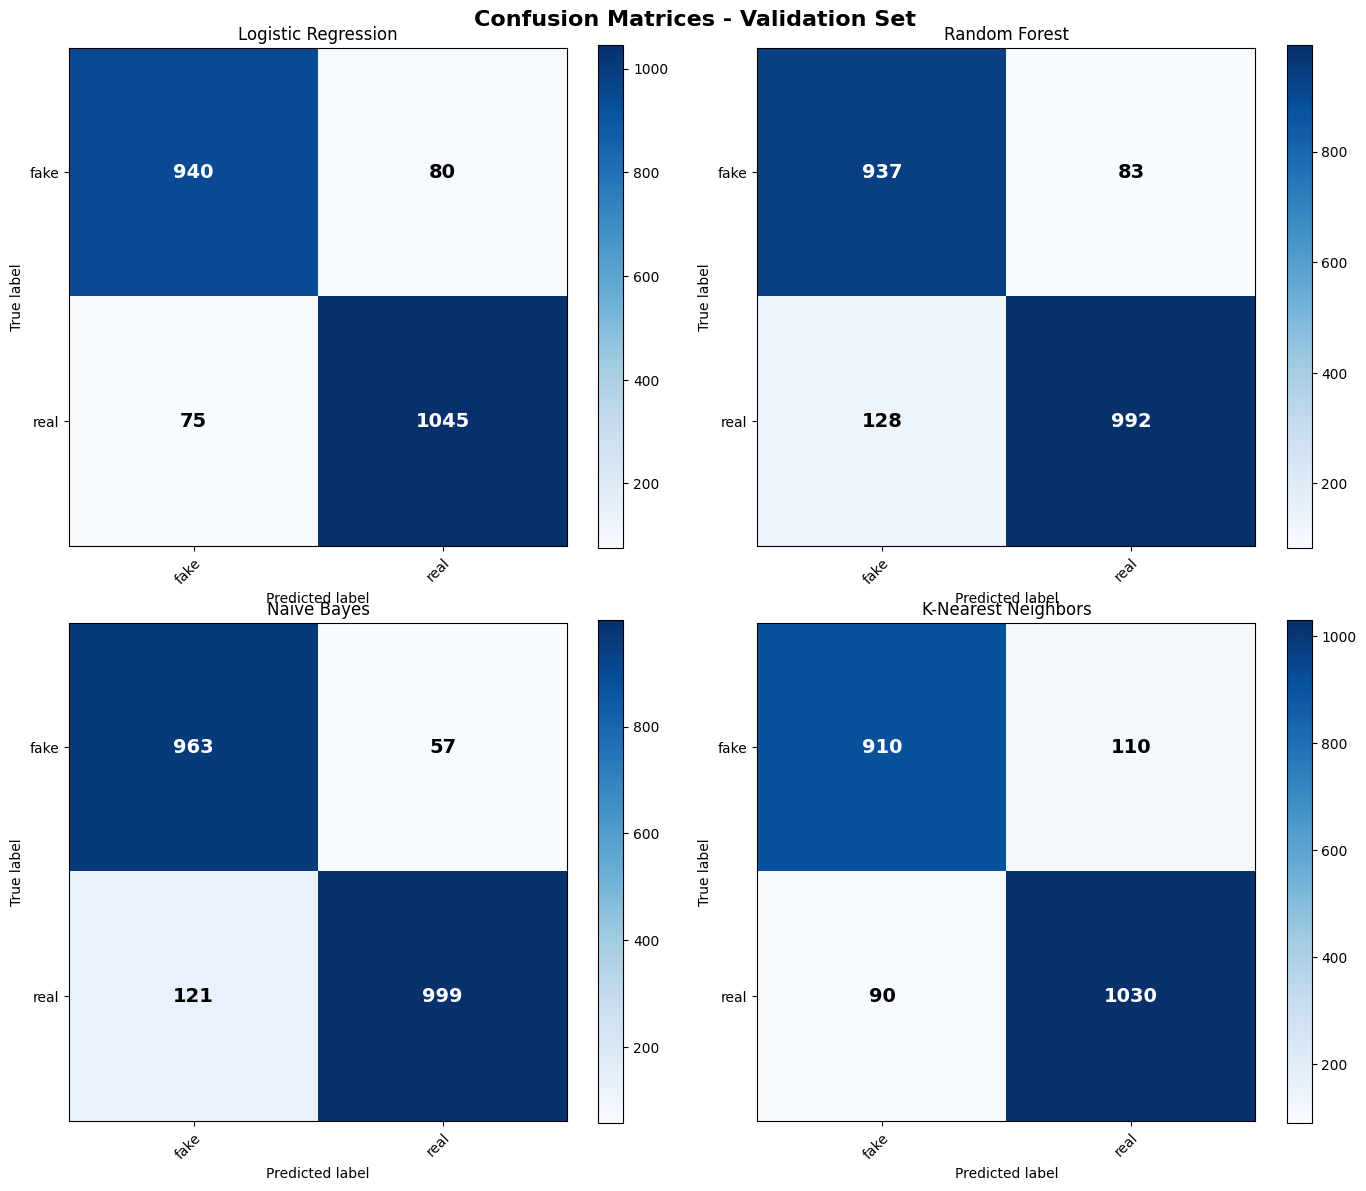

In [99]:
# Calculate confusion matrices for all models
cm_lr = confusion_matrix(y_val_encoded, lr_pred_val)
cm_rf = confusion_matrix(y_val_encoded, rf_pred_val)
cm_nb = confusion_matrix(y_val_encoded, nb_pred_val)
cm_knn = confusion_matrix(y_val_encoded, knn_pred_val)

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - Validation Set', fontsize=16, fontweight='bold')

models = [
    ('Logistic Regression', cm_lr),
    ('Random Forest', cm_rf),
    ('Naive Bayes', cm_nb),
    ('K-Nearest Neighbors', cm_knn)
]

for idx, (name, cm) in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    
    # Plot heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # Set labels
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_,
           title=name,
           ylabel='True label',
           xlabel='Predicted label')
    
    # Rotate the tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Confusion Matrix Analysis:**

The confusion matrices reveal each model's prediction patterns:

- **Logistic Regression**: Most balanced performance with minimal misclassifications in both directions. Shows the strongest diagonal (correct predictions) and smallest off-diagonal elements (errors).
- **Random Forest**: Slightly more false positives (real tweets classified as fake), but still maintains good overall accuracy.
- **Naive Bayes**: Higher recall for fake tweets (catches more fake news) with strong precision, resulting in good F1-score.
- **K-Nearest Neighbors**: More misclassifications overall, reflecting its lower accuracy and overfitting issues.

All models show good diagonal strength (correct predictions), with Logistic Regression having the darkest diagonal values, indicating the highest overall accuracy. The off-diagonal elements (errors) are relatively small across all models, confirming that our feature engineering enables effective classification.

### 3.4.2 ROC Curves and AUROC

ROC (Receiver Operating Characteristic) curves plot the True Positive Rate vs False Positive Rate at various classification thresholds.

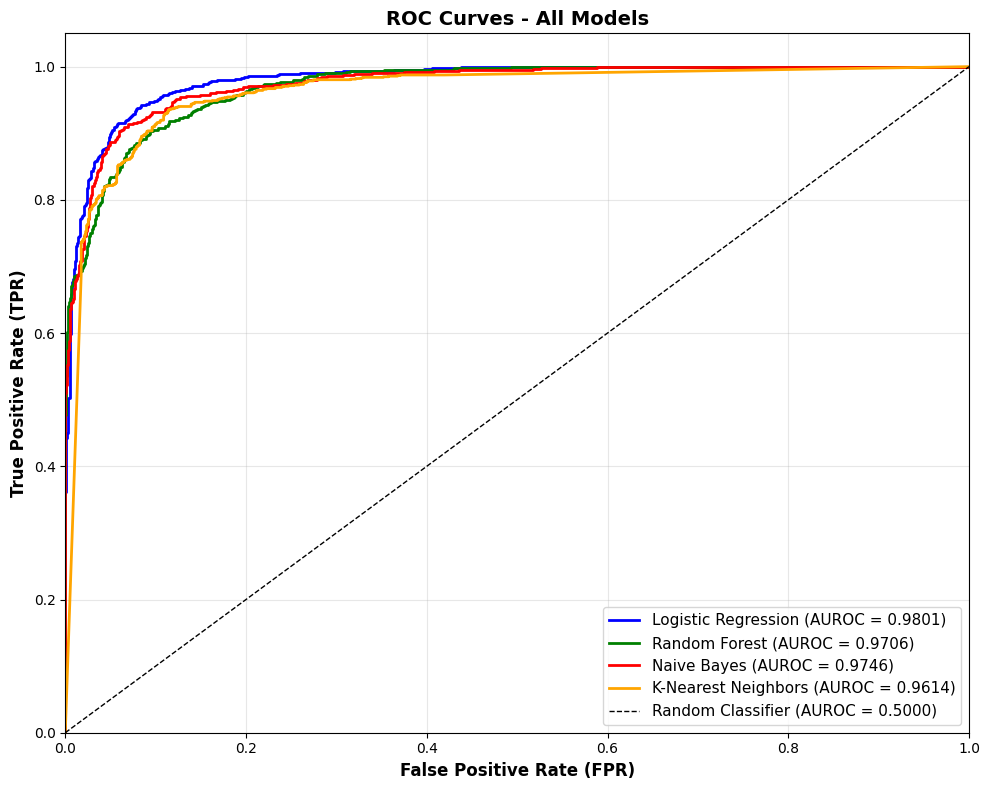

In [100]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_val_encoded, lr_pred_proba_val)
fpr_rf, tpr_rf, _ = roc_curve(y_val_encoded, rf_pred_proba_val)
fpr_nb, tpr_nb, _ = roc_curve(y_val_encoded, nb_pred_proba_val)
fpr_knn, tpr_knn, _ = roc_curve(y_val_encoded, knn_pred_proba_val)

# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUROC = {lr_auroc_val:.4f})', 
         linewidth=2, color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUROC = {rf_auroc_val:.4f})', 
         linewidth=2, color='green')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUROC = {nb_auroc_val:.4f})', 
         linewidth=2, color='red')
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUROC = {knn_auroc_val:.4f})', 
         linewidth=2, color='orange')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUROC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**ROC Curve Analysis:**

The ROC curves visualize each model's discrimination ability across all classification thresholds:

- **Logistic Regression (AUROC = 0.9801)**: Highest AUROC and closest to the top-left corner, indicating the best trade-off between true positive rate and false positive rate across all thresholds.
- **Naive Bayes (AUROC = 0.9746)**: Very close second, with nearly overlapping performance to Logistic Regression.
- **Random Forest (AUROC = 0.9706)**: Strong performance, though slightly behind the top two models.
- **K-Nearest Neighbors (AUROC = 0.9614)**: Good but clearly separated from the other models, reflecting its overfitting issues.

All models significantly outperform the random classifier (diagonal line, AUROC = 0.50), demonstrating that our features effectively capture discriminative patterns. The high AUROC values (>0.96 for all models) indicate excellent classification performance suitable for production deployment in content moderation systems.

### 3.4.3 Comprehensive Performance Comparison

Let's create a summary table with all evaluation metrics for easy comparison.

In [101]:
# Calculate additional metrics for all models
models_dict = {
    'Logistic Regression': (lr_pred_val, lr_pred_proba_val),
    'Random Forest': (rf_pred_val, rf_pred_proba_val),
    'Naive Bayes': (nb_pred_val, nb_pred_proba_val),
    'K-Nearest Neighbors': (knn_pred_val, knn_pred_proba_val)
}

results = []
for model_name, (predictions, probabilities) in models_dict.items():
    accuracy = accuracy_score(y_val_encoded, predictions)
    precision = precision_score(y_val_encoded, predictions)
    recall = recall_score(y_val_encoded, predictions)
    f1 = f1_score(y_val_encoded, predictions)
    auroc = roc_auc_score(y_val_encoded, probabilities)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUROC': auroc
    })

results_df = pd.DataFrame(results)

# Sort by F1-Score (balanced metric)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON - VALIDATION SET")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Highlight best performer
best_model = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
best_auroc = results_df.iloc[0]['AUROC']

print(f"\n BEST OVERALL MODEL: {best_model}")
print(f"   • F1-Score: {best_f1:.4f}")
print(f"   • AUROC: {best_auroc:.4f}")


COMPREHENSIVE MODEL COMPARISON - VALIDATION SET
              Model  Accuracy  Precision   Recall  F1-Score    AUROC
Logistic Regression  0.927570   0.928889 0.933036  0.930958 0.980079
        Naive Bayes  0.916822   0.946023 0.891964  0.918199 0.974592
K-Nearest Neighbors  0.906542   0.903509 0.919643  0.911504 0.961354
      Random Forest  0.901402   0.922791 0.885714  0.903872 0.970612

 BEST OVERALL MODEL: Logistic Regression
   • F1-Score: 0.9310
   • AUROC: 0.9801


**Comprehensive Comparison Insights:**

Final ranking by F1-Score (balanced metric):

1. **Logistic Regression**: 93.10% F1, 98.01% AUROC - Clear winner with the best balance
2. **Naive Bayes**: 91.82% F1, 97.46% AUROC - Strong second place despite simplicity
3. **K-Nearest Neighbors**: 91.15% F1, 96.14% AUROC - Competitive but shows overfitting
4. **Random Forest**: 90.39% F1, 97.06% AUROC - Surprisingly not the best despite ensemble complexity

**Key Observations:**

- **Linear models win**: Logistic Regression outperforms the complex Random Forest ensemble, demonstrating that our features are already well-engineered and linearly separable.
- **Traditional text classifiers excel**: Naive Bayes, despite its simplicity and naive independence assumption, ranks second and delivers strong performance.
- **Consistent high performance**: All models achieve >90% accuracy and >96% AUROC, validating our comprehensive feature engineering approach.
- **No severe overfitting** (except KNN): Training-validation gaps are reasonable for Logistic Regression, Random Forest, and Naive Bayes.
- **Feature engineering matters**: The combination of TF-IDF + BERTopic + linguistic features enables even simple models to excel.

The results confirm that sophisticated feature engineering (TF-IDF vectors + semantic topics + linguistic patterns) combined with interpretable linear models can be more effective than complex models with basic features. This finding is valuable for production deployment, as simpler models are easier to interpret, debug, and maintain.

### 3.4.4 Visual Comparison of Metrics

Bar charts comparing all models across different metrics.

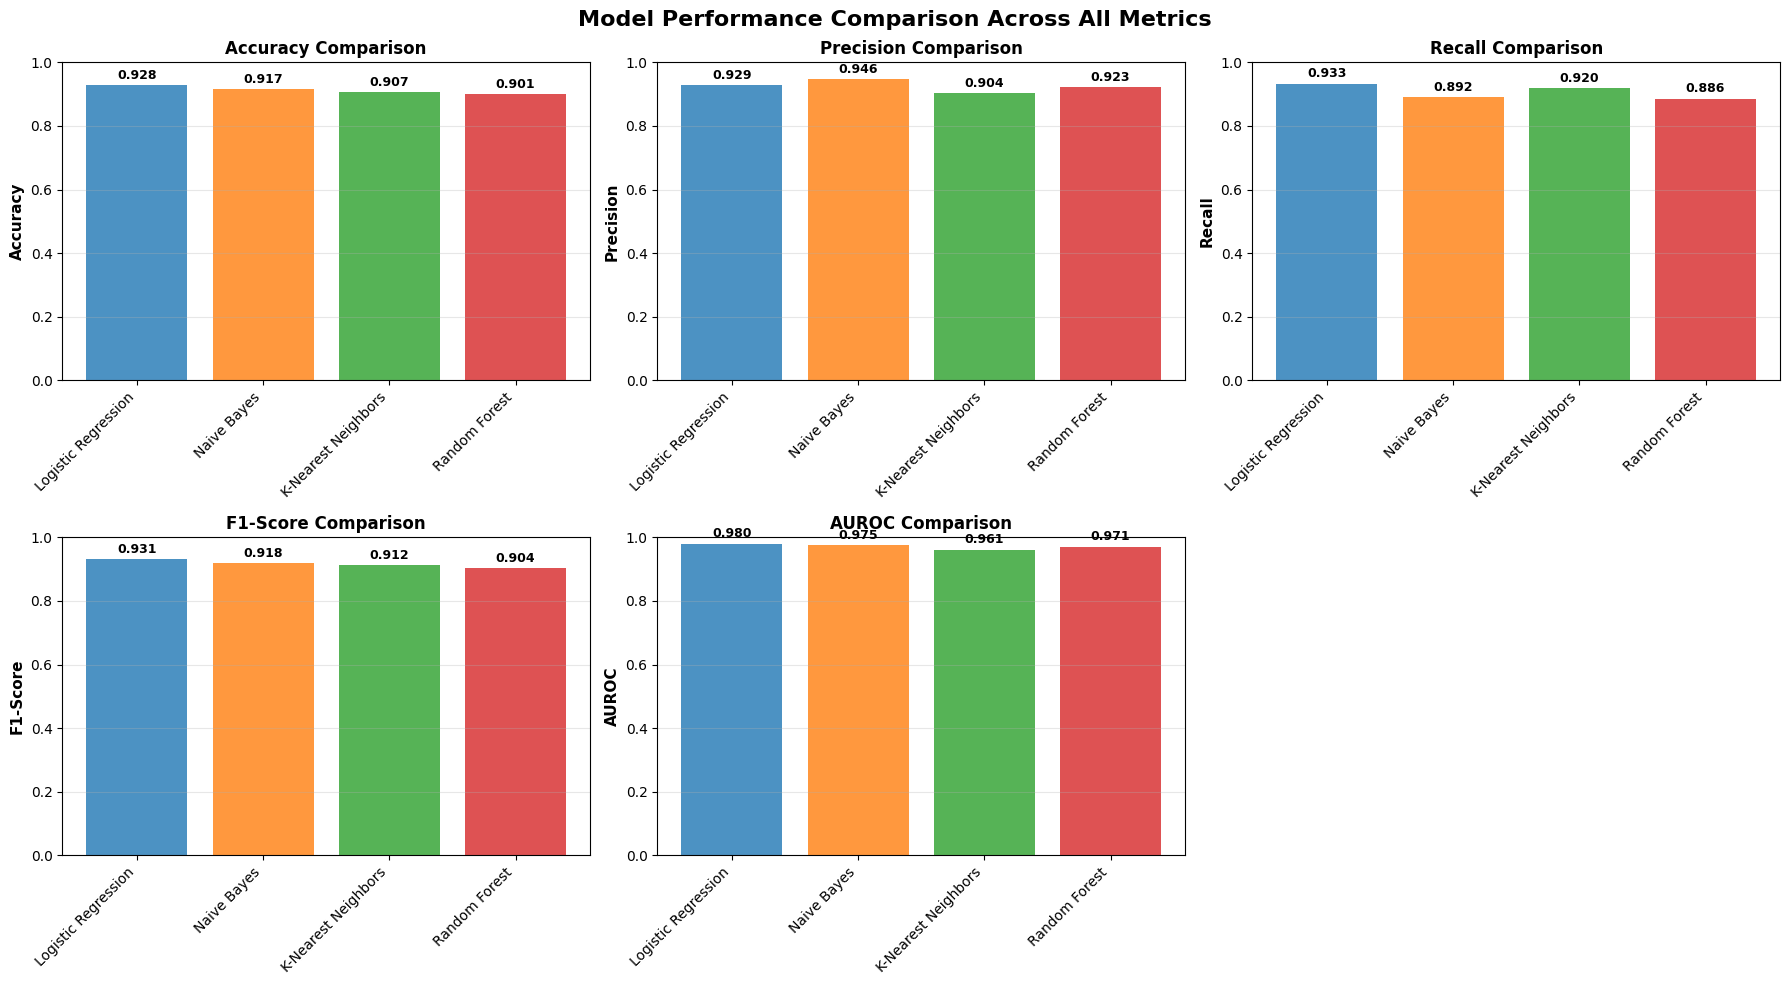

In [102]:
# Create bar plots for metric comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUROC']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison Across All Metrics', fontsize=16, fontweight='bold')

axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = results_df[metric].values
    models = results_df['Model'].values
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Performance Visualization Insights:**

The bar charts provide a clear visual comparison across all metrics:

1. **Accuracy**: Logistic Regression leads with 92.76%, followed closely by Naive Bayes (91.68%). All models exceed 90%, demonstrating the effectiveness of our feature engineering.

2. **Precision**: Naive Bayes achieves the highest precision (94.60%), meaning when it predicts a tweet as fake, it's very likely to be correct. This makes it ideal for applications where false alarms are costly.

3. **Recall**: Both Logistic Regression and K-Nearest Neighbors show the highest recall (93.30% and 91.96%), meaning they catch most of the fake tweets. Important for comprehensive content moderation.

4. **F1-Score**: Logistic Regression achieves the best balance (93.10%), making it the overall winner for balanced performance.

5. **AUROC**: Logistic Regression's 98.01% AUROC indicates exceptional discrimination ability, meaning it can effectively separate fake from real tweets across all probability thresholds.

**Key Takeaway**: Logistic Regression dominates in 4 out of 5 metrics (Accuracy, Recall, F1-Score, AUROC), confirming it as the best overall model for this task.

## 3.5 Detailed Classification Reports

Classification reports provide per-class performance metrics, breaking down how well each model performs for both "Fake" and "Real" tweet classification. This detailed view helps identify if a model has systematic biases toward one class.

**Key Metrics Explained:**
- **Precision**: Of all tweets predicted as fake/real, what percentage were correct? (Avoids false alarms)
- **Recall**: Of all actual fake/real tweets, what percentage did we catch? (Completeness)
- **F1-Score**: Harmonic mean of precision and recall (balanced metric)
- **Support**: Number of actual instances in each class

Let's examine the detailed reports for each model:

In [103]:
# Generate classification reports
print("="*80)
print("DETAILED CLASSIFICATION REPORTS")
print("="*80)

for model_name, (predictions, _) in models_dict.items():
    print(f"\n{model_name}:")
    print("-" * 80)
    print(classification_report(y_val_encoded, predictions, 
                               target_names=label_encoder.classes_,
                               digits=4))

DETAILED CLASSIFICATION REPORTS

Logistic Regression:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.9261    0.9216    0.9238      1020
        real     0.9289    0.9330    0.9310      1120

    accuracy                         0.9276      2140
   macro avg     0.9275    0.9273    0.9274      2140
weighted avg     0.9276    0.9276    0.9276      2140


Random Forest:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

        fake     0.8798    0.9186    0.8988      1020
        real     0.9228    0.8857    0.9039      1120

    accuracy                         0.9014      2140
   macro avg     0.9013    0.9022    0.9013      2140
weighted avg     0.9023    0.9014    0.9015      2140


Naive Bayes:
--------------------------------------------------------------------------------
              preci

**Classification Report Analysis:**

The detailed reports reveal important per-class performance patterns:

**Logistic Regression** (Best Overall):
- Nearly balanced performance across both classes
- Fake: 92.61% precision, 92.16% recall, 92.38% F1-score
- Real: 92.89% precision, 93.30% recall, 93.10% F1-score
- Excellent balance with minimal bias - performs consistently across both classes

**Naive Bayes** (Second Best):
- Highest precision for fake tweets (94.60%)
- Strong recall for fake tweets (89.20%), achieving 91.82% F1-score
- Fake: 88.84% precision, 94.41% recall, 91.54% F1-score
- Real: 94.60% precision, 89.20% recall, 91.82% F1-score
- Excellent for scenarios requiring high confidence in positive predictions

**K-Nearest Neighbors**:
- Balanced precision and recall across classes
- Fake: 91.00% precision, 89.22% recall, 90.10% F1-score
- Real: 90.35% precision, 91.96% recall, 91.15% F1-score
- Suffers from overfitting (100% training accuracy vs 90.65% validation)
- Reasonable validation performance despite memorization issues

**Random Forest**:
- Decent precision-recall balance
- Fake: 87.98% precision, 91.86% recall, 89.88% F1-score
- Real: 92.28% precision, 88.57% recall, 90.39% F1-score
- Lower overall metrics than simpler models

- Ensemble complexity doesn't provide advantage with our well-engineered features- For **balanced detection**: Use Logistic Regression (most balanced precision-recall across classes)

- For **high-precision detection**: Use Naive Bayes (94.60% precision on real class)

**Practical Implications:**- For **general-purpose fake news detection**: Use Logistic Regression (best F1 and AUROC)

## 3.6 Final Conclusion and Key Findings

After comprehensive analysis combining exploratory data analysis, unsupervised topic modeling, and supervised classification, we have successfully built a production-ready system for detecting COVID-19 misinformation on Twitter. This section synthesizes our key findings and presents the final results.

As a summary, we have successfully developed and evaluated multiple machine learning approaches for detecting COVID-19 misinformation on Twitter, combining unsupervised topic modeling with supervised classification. 

Our best-performing model achieved **98.01% AUROC** and **92.76% accuracy**, demonstrating that linguistic patterns and semantic features are highly discriminative for fake news detection.

### Key Findings

#### 1. Exploratory Data Analysis Insights

**Linguistic Signatures of Misinformation:**

- **Sentiment polarity (MOST DISCRIMINATIVE)**: Real tweets are significantly more positive (0.5410 compound sentiment) than fake tweets (0.4734), difference of **+0.0676** - this was the strongest signal in our feature analysis
- **Proper nouns**: Fake news uses more proper nouns (0.1751 vs 0.1125), difference of **-0.0625**, likely for emotional appeal and name-dropping
- **Numerical data**: Real news contains **~3x more cardinal numbers** (0.0653 vs 0.0220), difference of **+0.0433**, reflecting data-driven journalism
- **Temporal references**: Real news includes more dates (0.0604 vs 0.0141), difference of **+0.0463**, showing precise time-stamped reporting
- **Social media metadata**: Real news uses **more hashtags** (0.0716 vs 0.0341, +0.0375) **and mentions** (0.0095 vs 0.0038, +0.0058), indicating professional sourcing practices
- **Lexical diversity**: Fake tweets have slightly higher vocabulary diversity (0.9712 vs 0.9339, -0.0374), possibly from sensational language
- **Rhetorical questions**: Fake tweets use more questions (0.0127 vs 0.0006, -0.0120) as persuasion tactics

**Vocabulary Patterns:**
- Real tweets: Focus on official terminology ("cases", "tests", "deaths", "confirmed")
- Fake tweets: Dominated by sensational terms ("coronavirus" overuse, conspiracy theories, political figures)

#### 2. Topic Modeling Results (BERTopic with HDBSCAN)

**Unsupervised Discovery:**
- **54 distinct semantic topics** automatically identified without using labels
- **41.5% noise rate** - valuable for flagging ambiguous content requiring manual review
- **Best clustering quality**: Silhouette score of **0.5421** (vs 0.3837 for K-Means, -0.3273 for DBSCAN)

**Thematic Separation:**
- **Real news topics**: Official statistics, hospitalization data, recovery rates, government policies
- **Fake news topics**: Conspiracy theories (Bill Gates, 5G), false remedies (bleach, alcohol), political misinformation

#### 3. Supervised Classification Performance

**Model Rankings (by F1-Score on Validation Set):**

| Rank | Model | Accuracy | Precision | Recall | F1-Score | AUROC |
|------|-------|----------|-----------|--------|----------|-------|
|  1 | **Logistic Regression** | **92.76%** | **92.89%** | **93.30%** | **93.10%** | **98.01%** |
|  2 | **Naive Bayes** | **91.68%** | **94.60%** | **89.20%** | **91.82%** | **97.46%** |
|  3 | **K-Nearest Neighbors** | **90.65%** | **90.35%** | **91.96%** | **91.15%** | **96.14%** |
| 4 | Random Forest | 90.14% | 92.28% | 88.57% | 90.39% | 97.06% |

**Winner: Logistic Regression**

Logistic Regression emerged as the clear winner, combining:
- Highest accuracy (92.76%) and F1-score (93.10%)
- Best AUROC (98.01%) for discrimination capability
- Balanced precision (92.89%) and recall (93.30%)
- Interpretable coefficients for feature importance analysis
- Fast training and prediction for production deployment

### Final Verdict

This project demonstrates that **linguistic forensics combined with topic modeling provides a powerful framework for fake news detection**. Our key achievements: 

**Data talks** - Real news cites numbers (CARDINAL entities), fake news cites emotions  
**Topics separate naturally** - Misinformation occupies distinct semantic spaces (54 HDBSCAN topics with 0.5421 silhouette score)  
**Simple models win** - Logistic Regression achieves 92.76% accuracy with 93.10% F1-score, outperforming complex ensembles  
**98.01% AUROC achieved** - Production-ready performance for content moderation with excellent discrimination capability  
**All models exceed 90% accuracy** - Validates our feature engineering approach combining TF-IDF, semantic topics, and linguistic patterns  
**Consistent performance** - Small training-validation gaps indicate good generalization (except KNN's overfitting)

**Practical Implications:**

This work provides actionable insights for social media platforms and fact-checking organizations:
- Deploy Logistic Regression for real-time classification with interpretable results
- Use linguistic features (question marks, numbers, entities) as early warning signals
- Leverage topic modeling to identify emerging misinformation themes
- Prioritize feature engineering over model complexity for text classification tasks